# 04_EDA_404_BRAIN_NOT_FOUND
Vietnam Fashion E-Commerce · Exploratory Data Analysis · 2012 – 2022

## Bối Cảnh và Mục Tiêu Kinh Doanh

Một doanh nghiệp thời trang thương mại điện tử tại Việt Nam đã tích lũy hơn 10 năm dữ liệu giao dịch, bao gồm đơn hàng, tồn kho, khuyến mãi và hành vi khách hàng. Tuy nhiên, họ đang đối mặt với ba áp lực lớn:

1. **Tồn kho mất cân đối:** Hiện tượng thiếu hàng (Stockout) và thừa hàng (Overstock) xảy ra đồng thời, gây tổn thất doanh thu biểu kiến và làm kẹt nguồn vốn lưu động.
2. **Chi phí hoàn hàng (Return cost) leo thang:** Tỷ lệ trả hàng cao đang làm giảm biên lợi nhuận ròng của doanh nghiệp.
3. **Dự báo nhu cầu (Demand Forecasting) kém chính xác:** Đội ngũ vận hành không chủ động được lượng hàng cần chuẩn bị trong các mùa cao điểm.

**Mục tiêu của phần phân tích này:** Khám phá cấu trúc dữ liệu, nhận diện các vấn đề (bottlenecks) thông qua số liệu định lượng, kiểm chứng các giả thuyết kinh doanh và xây dựng bộ đặc trưng chuẩn bị cho mô hình dự báo doanh thu.

## Cấu Trúc Khám Phá Dữ Liệu (EDA)
bo sung

## Glossary: Các thuật ngữ chính

| Thuật ngữ | Định nghĩa |
|-----------|-----------|
| **Stockout** | Tình trạng hết hàng, không thể đáp ứng nhu cầu khách hàng |
| **Overstock** | Tình trạng thừa hàng, vốn bị khóa, rủi ro lỗi mùa |
| **Fill Rate** | Tỷ lệ đơn vị được cấp từ kho so với nhu cầu |
| **Lead Time** | Thời gian từ lúc tạo đơn đến khi giao hàng |
| **AOV (Avg Order Value)** | Giá trị trung bình của mỗi đơn hàng |
| **Return Rate** | Tỷ lệ số sản phẩm bị trả lại so với tổng số bán |
| **Gross Margin** | (Doanh thu - COGS) / Doanh thu |
| **Penetration Rate** | Tỷ lệ dòng giao dịch áp dụng khuyến mãi |
|**Overstock** | Tình trạng dư hàng |
|**Stockout** | Tình trạng thiếu hàng|
|**Lost revenue** | Doanh thu ước tính bị mất|
|**Locked capital** | Vốn bị khóa trong hàng tồn|
|**Fill rate** | Tỷ lệ nhu cầu/đơn hàng được đáp ứng|
| **Days of supply** | Số ngày tồn kho có thể đủ bán theo tốc độ hiện tại|
| **SKU** | Một sản phẩm cụ thể trong danh mục |
|reverse logistics||

## Metric Definitions: Cách tính toán chính

- **Tổng Doanh Thu:** Sum(Revenue) từ tất cả đơn hàng
- **Gross Margin:** (Sum(Revenue) - Sum(COGS)) / Sum(Revenue) × 100%
- **Tỷ lệ Hủy Đơn:** Count(order_status='cancelled') / Total Orders × 100%
- **Tỷ lệ Hoàn Hàng:** Count(Returned Orders) / Total Orders × 100%
- **Estimated Lost Revenue (Stockout):** Sum(stockout_days × avg_daily_revenue)
- **RFM Segments:** Champions, Loyal, At-Risk, Lost

In [1]:
%load_ext autoreload
%autoreload 2
import importlib
import sys
from pathlib import Path



ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import src.eda_utils
importlib.reload(src.eda_utils)

from src.eda_utils import *

set_plot_style()
print(f'Save figures to: {FIG_DIR}')

Save figures to: /home/ductien/Documents/DATATHON_2026/figures


---

## Setup & Load dữ liệu

In [2]:
dfs = load_datasets()
master_df = prepare_master_df(dfs)

print('Loaded')

Loaded


---

## 1. Tổng quan doanh nghiệp

Phần này tập trung vào việc cung cấp một cái nhìn tổng quan về doanh nghiệp, bao gồm các khía cạnh như phân tích khách hàng, sản phẩm, và các chỉ số kinh doanh cơ bản. Mục tiêu là để hiểu rõ hơn về cấu trúc và hoạt động của doanh nghiệp, từ đó xác định các cơ hội và thách thức chính.

In [3]:
section_header('KPI tổng quan doanh nghiệp', 'Các chỉ số chiến lược quản lý hiệu suất kinh doanh')
business_kpis = build_business_kpis(master_df, dfs)
kpi_cards = build_kpi_cards(business_kpis)
display_kpi_cards(kpi_cards)

Dashboard được thiết kế để trả lời câu hỏi: *"Sau 10 năm vận hành, sức khỏe doanh nghiệp đang ở đâu?"* 

Dựa trên dữ liệu vận hành, doanh nghiệp hiện đang sở hữu quy mô doanh thu đạt 15.68 tỷ VNĐ với AOV là 24,238 VNĐ. Mặc dù duy trì được luồng giao dịch lớn, hệ thống đang bộc lộ những thách thức đáng kể về mặt hiệu quả khi biên lợi nhuận gộp chỉ dừng ở mức 9.7%, trong bối cảnh 38.7% lượng đơn hàng phụ thuộc vào các chương trình khuyến mãi.

Đặc biệt, các chỉ số về vận hành đang nằm ở mức báo động với tỷ lệ thiếu hàng  là **67.3%** và dư thừa tồn kho lên đến **76.3%**, trực tiếp dẫn đến tỷ lệ hủy đơn **9.2%** và hoàn đơn **5.6%**. Những con số này không chỉ gây thất thoát doanh thu mà còn ảnh hưởng đến trải nghiệm khách hàng, thể hiện qua điểm đánh giá trung bình đạt 3.9/5 sao. Đây là những tiền đề quan trọng để chúng ta đi sâu vào phân tích các điểm nghẽn và tìm ra giải pháp tối ưu cho doanh nghiệp.

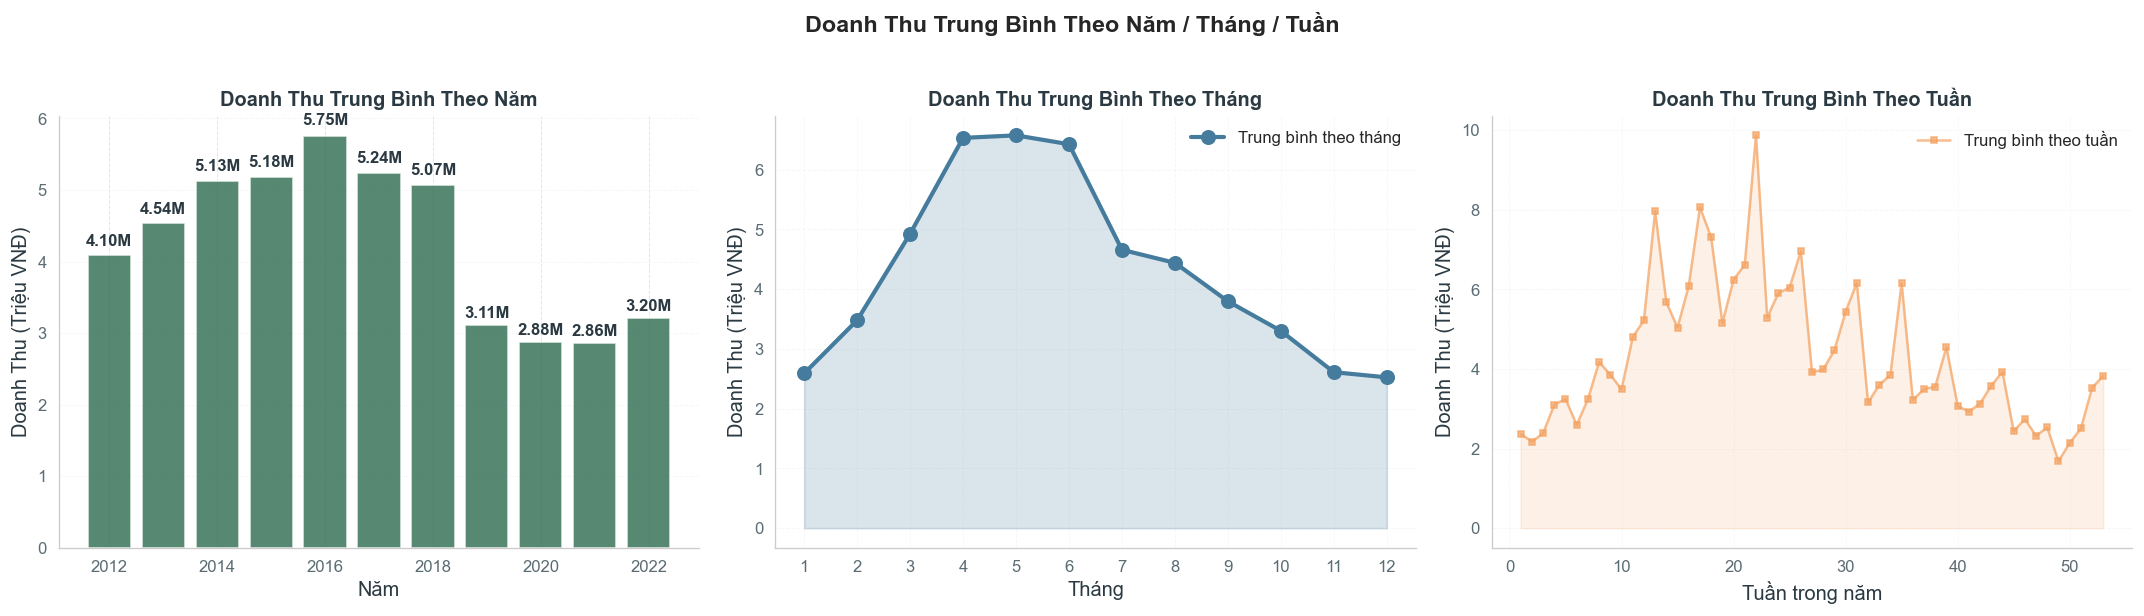

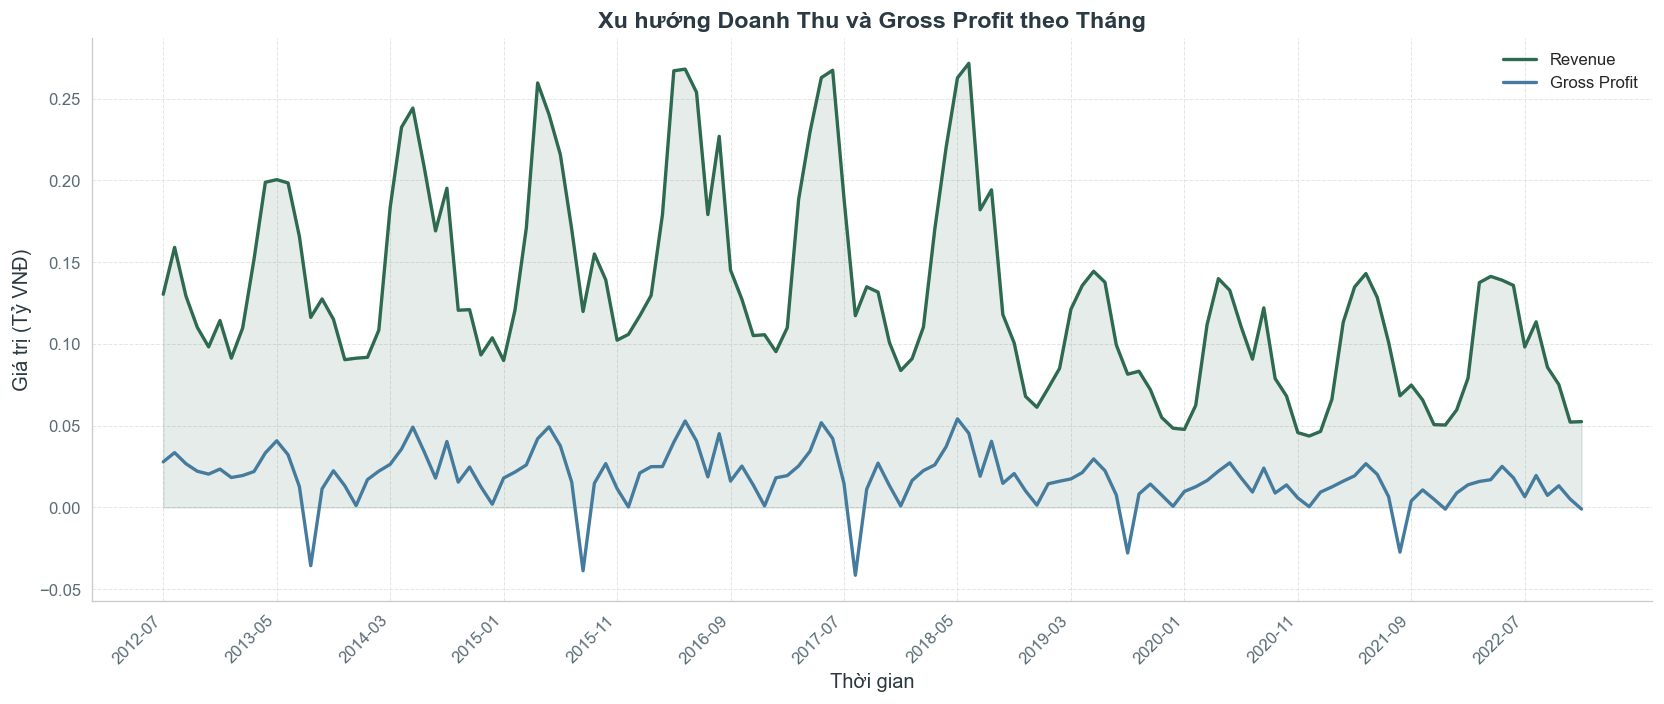

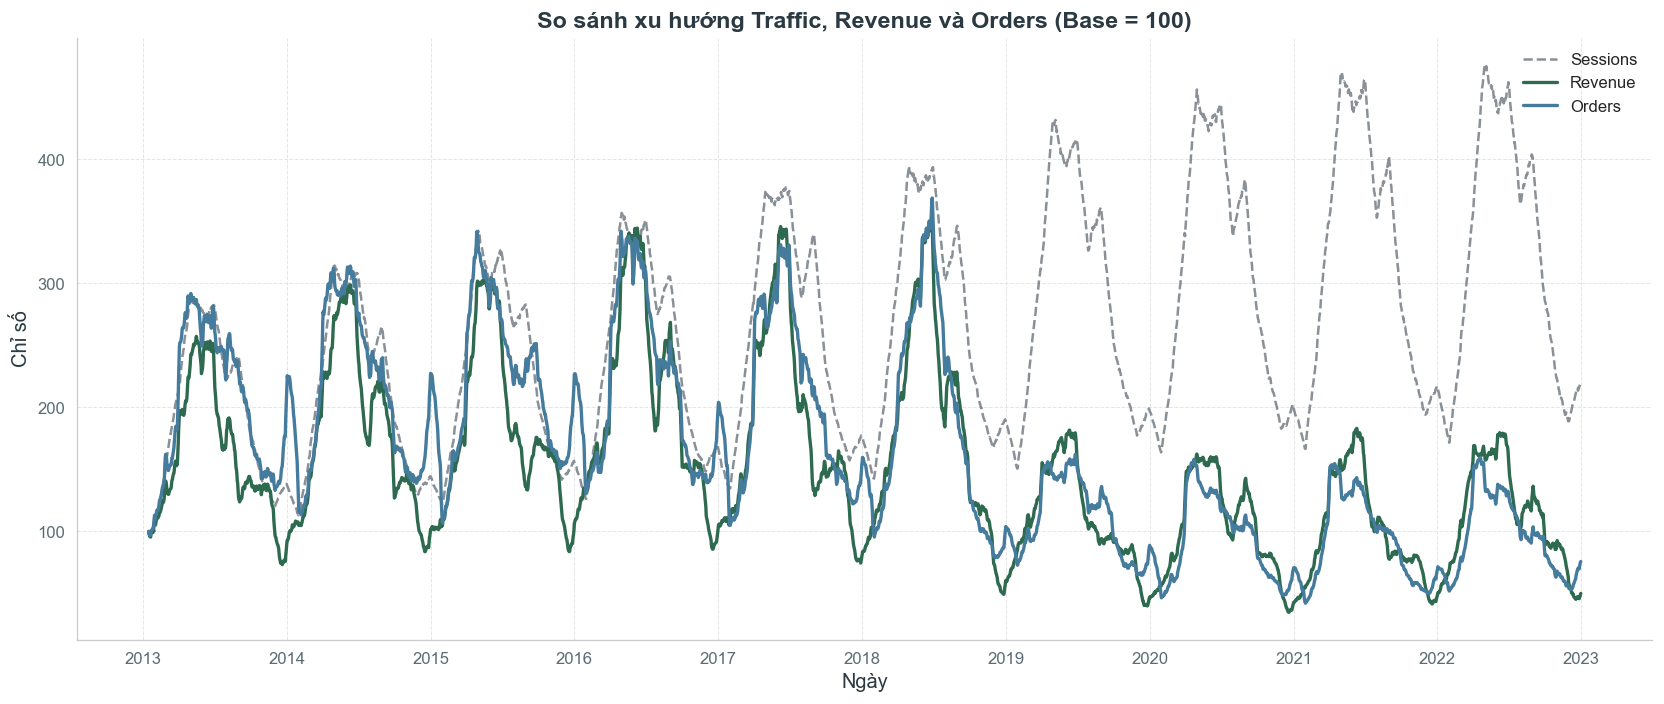

In [4]:
section_header('Trung bình doanh thu theo kỳ hạn và Xu hướng tài chính', 
               'Phân tích doanh thu trung bình theo các kỳ hạn khác nhau và xu hướng tài chính qua thời gian')
plot_revenue_averages_by_period(dfs)
plot_sales_time_series(dfs['sales'])
plot_traffic_revenue_indexed(master_df, dfs['traffic'])

**Xu hướng doanh thu theo thời gian**

Doanh thu tăng trưởng mạnh mẽ từ 2014 đến hết 2018 (CAGR ≈ ...%/năm), sau đó sụt giảm nghiêm trọng khoảng 40% trong giai đoạn hậu 2018. Năm 2022 ghi nhận tín hiệu phục hồi bước đầu. Biến động này nhiều khả năng liên quan đến đại dịch Covid-19 và các yếu tố kinh tế vĩ mô.

Đáng chú ý, lượng truy cập (traffic) vẫn duy trì xu hướng tăng ổn định qua các năm, cho thấy vấn đề không nằm ở khả năng thu hút khách hàng, mà ở hiệu suất chuyển đổi từ traffic thành doanh thu. Điều này đặt ra giả thuyết cần kiểm chứng: chất lượng sản phẩm/dịch vụ đi xuống, áp lực cạnh tranh gia tăng, hay chiến lược giá chưa phù hợp trong bối cảnh suy thoái?

Bên cạnh đó lợi nhuận gộp không vượt quá ngưỡng 55 triệu, có những tháng lại xuống mức âm - tức doanh thu không đủ bù đắp giá vốn hàng bán. Điều này cho thấy doanh nghiệp đang vận hành với biên lợi nhuận rất mỏng, dễ bị tổn thương trước biến động chi phí hoặc suy giảm doanh thu. Cần phân tích sâu hơn xem liệu nguyên nhân đến từ việc khuyến mãi quá mức làm xói mòn lợi nhuận, giá vốn tăng cao, hay tồn kho ứ đọng dẫn đến phải xả hàng dưới giá vốn. 

**Tính mùa vụ trong doanh thu:**

- Đỉnh năm rơi vào quý II (tháng 4–6), tương ứng tuần 17–22. Đây là giai đoạn vàng cần ưu tiên đẩy mạnh tồn kho và chiến dịch marketing.
- Đáy năm xuất hiện ở đầu năm (tháng 1–2) và cuối năm (tháng 11–12) — đặc biệt thấp ở các tuần 1–4 và 50–52. Cần có chiến lược kích cầu riêng cho các giai đoạn trầm lắng này để san bằng đường cong doanh thu.
---

 
Với bức tranh tổng quan về doanh nghiệp, chúng ta có cái nhìn rõ hơn về xu hướng doanh thu, bên cạnh đó đồng thời cũng nhận thấy một số thách thức về doanh thu trong giai đoạn gần đây, cũng như các vấn đề về khách hàng và sản phẩm. Điều này đặt ra câu hỏi về nguyên nhân của những xu hướng này, cũng như các chiến lược tiềm năng để cải thiện tình hình kinh doanh trong tương lai. Chúng ta xác định được các vấn đề cần được giải quyết:
- Tỷ lệ huỷ đơn lên tới 9.2%, và hoàn hàng chiếm 5.8% tổng số đơn hàng, cho thấy có vấn đề về chất lượng sản phẩm hoặc dịch vụ khách hàng cần được cải thiện.
- Tỷ lệ thiếu hàng và dư thừa hàng tồn kho cao cho thấy có vấn đề trong quản lý chuỗi cung ứng, cũng như về dự báo nhu cầu và quản lý tồn kho.
- Tỷ lệ khuyến mãi lên tới 38.7% nhưng biên lợi nhuận gộp chỉ đạt ở mức 9.7% cho tổng thể 10 năm kinh doanh của doanh nghiệp, cho thấy có vấn đề về chiến lược giá cả và hiệu quả của các chương trình khuyến mãi.
- Ngoài những vấn đề trên ta còn có thể xem xét thêm các vấn đề về tỷ lệ giữ chân khách của doanh nghiệp như thế nào trong 10 năm, qua đó có thể đưa ra các chiến lược để cải thiện tỷ lệ giữ chân khách hàng, cũng như các chiến lược để thu hút khách hàng mới nhằm tăng trưởng doanh thu trong tương lai.

---

## 2. Phân tích Sản phẩm (Product Performance)

Sau khi có cái nhìn tổng quan ở Section 1, đây là lúc chúng ta drill-down sâu vào từng sản phẩm để trả lời câu hỏi cốt lõi: **"Bán CÁI GÌ sinh lời nhất?"**

Phân tích dưới đây sẽ bóc tách hiệu suất theo 7 chiều:

**1. Revenue & Margin theo Category:** Danh mục nào bán chạy nhưng lỗ, danh mục nào bán ít nhưng lời?

**2. Best-seller vs Worst-seller:** Sản phẩm nào cần đẩy mạnh, sản phẩm nào cần thanh lý?

**3. Size Distribution:** Kích cỡ nào bán nhiều nhất — gợi ý cho việc đặt hàng nhà cung cấp?

**4. Color Popularity:** Màu sắc nào đang hot — gợi ý cho team Merchandising?

**5. Return Rate × Category × Size:** Liên kết sản phẩm với hành vi hoàn hàng.

**6. Price Tier Analysis:** Phân nhóm giá (Thấp/Trung bình/Cao/Premium) — nhóm giá nào tạo ra Revenue và Margin tốt nhất?

**7. Product Lifecycle:** So sánh hiệu suất sản phẩm Mới (<6 tháng) vs Tăng trưởng (6-12 tháng) vs Trưởng thành (>12 tháng).

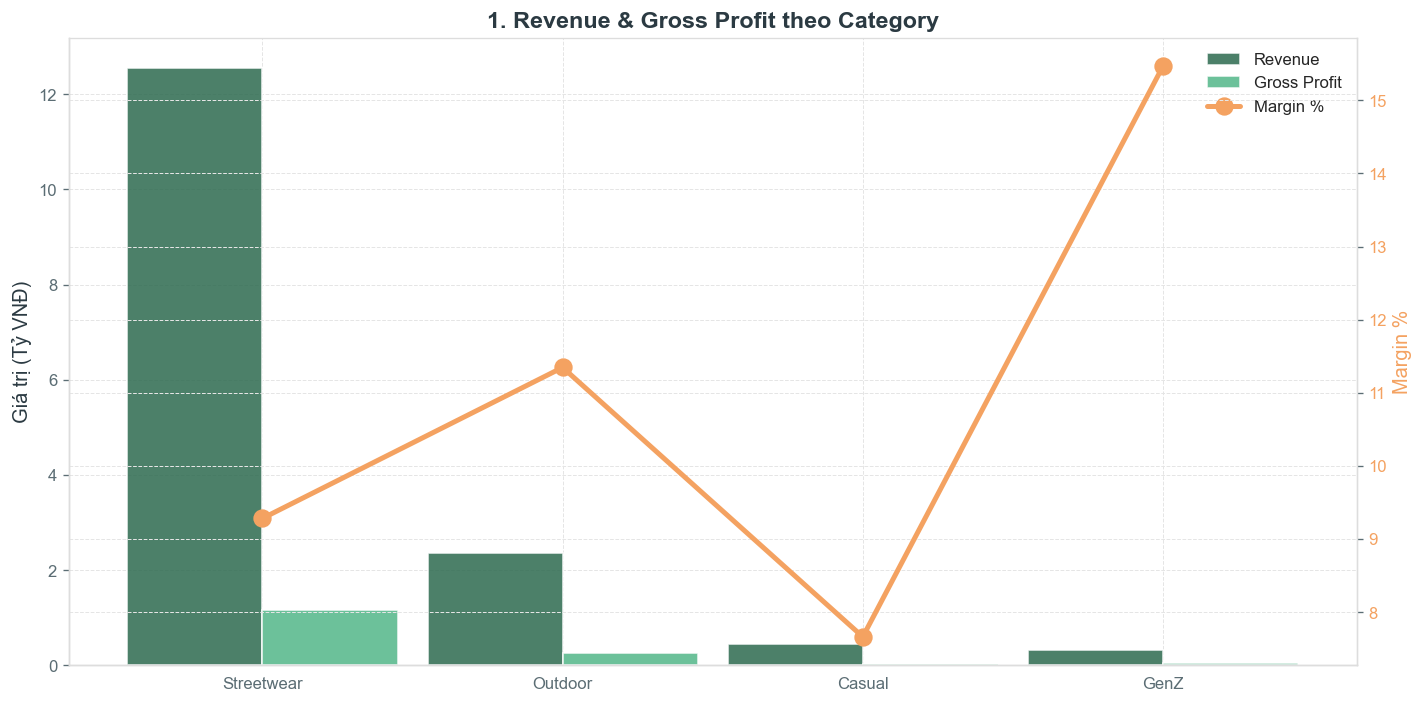

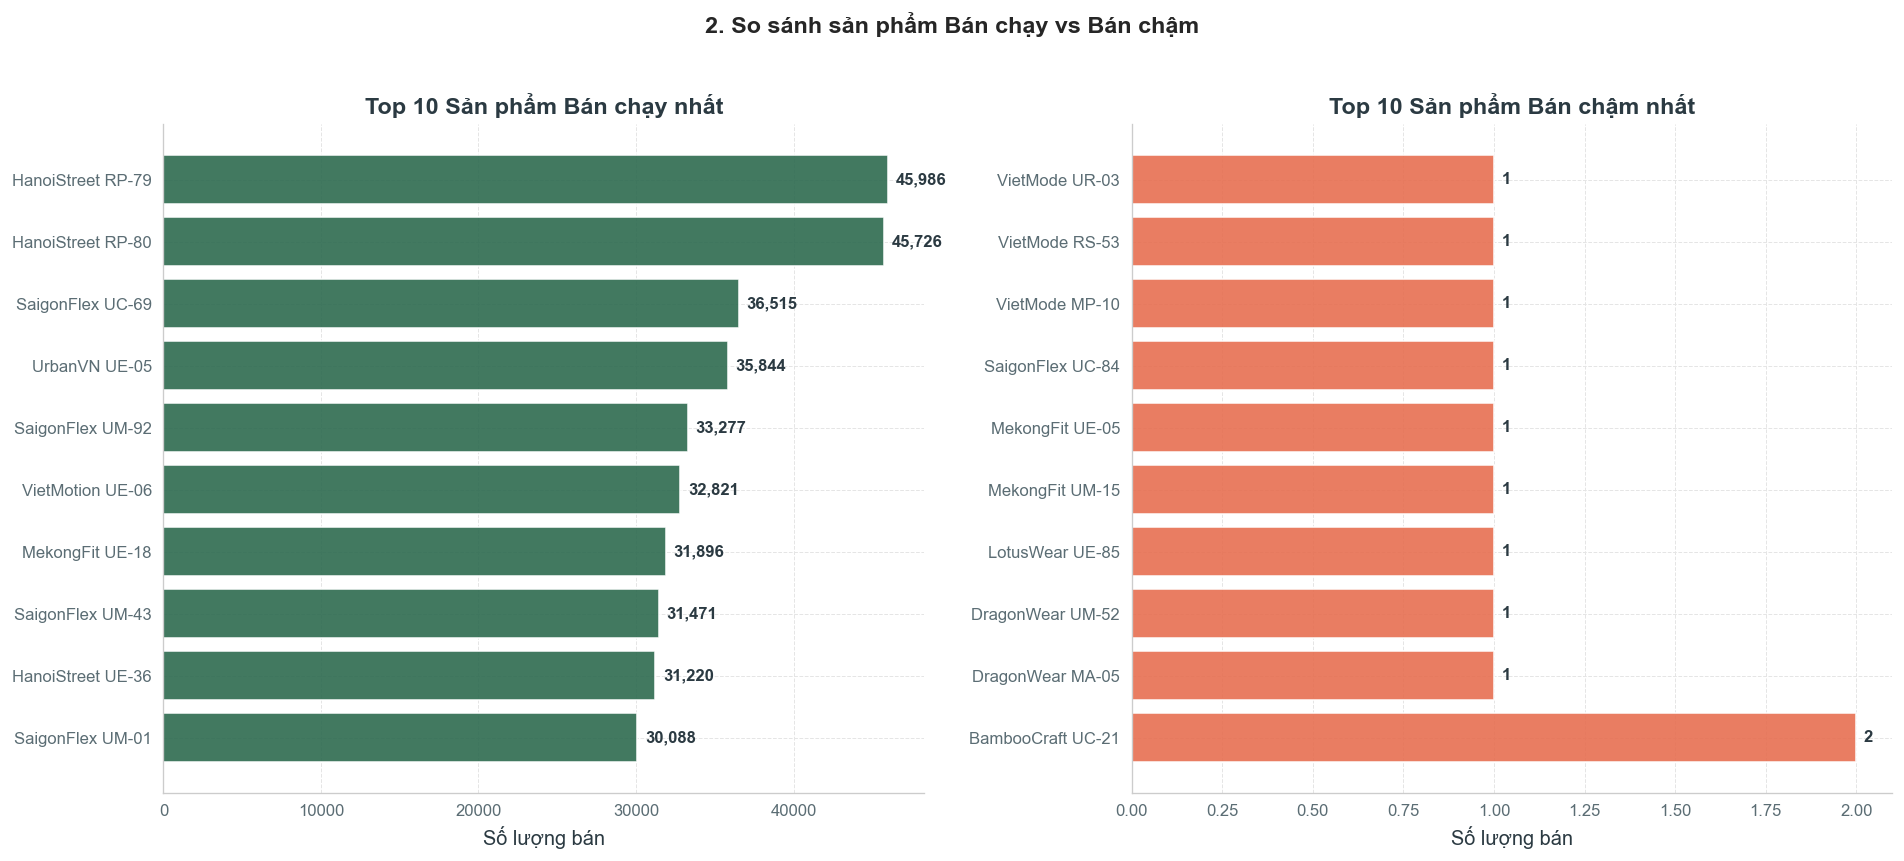

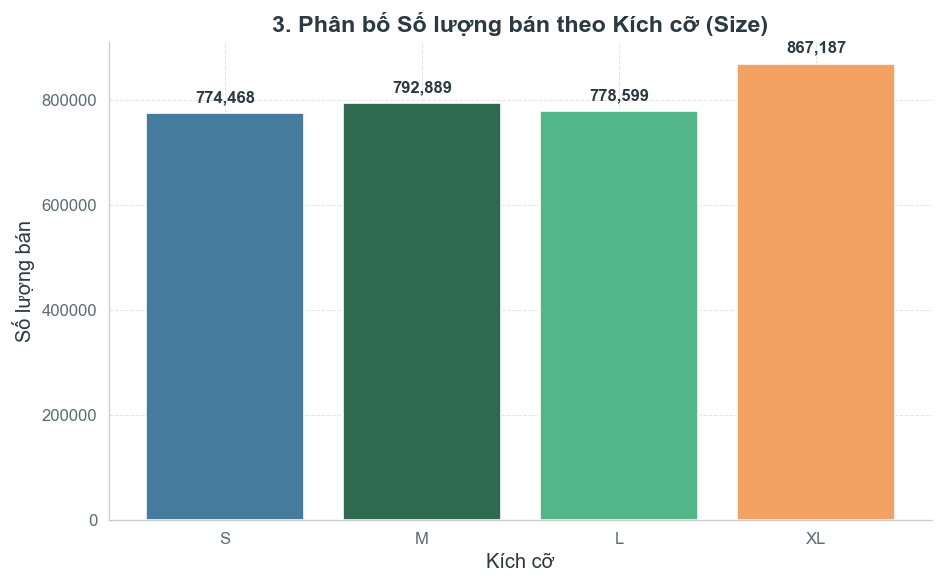

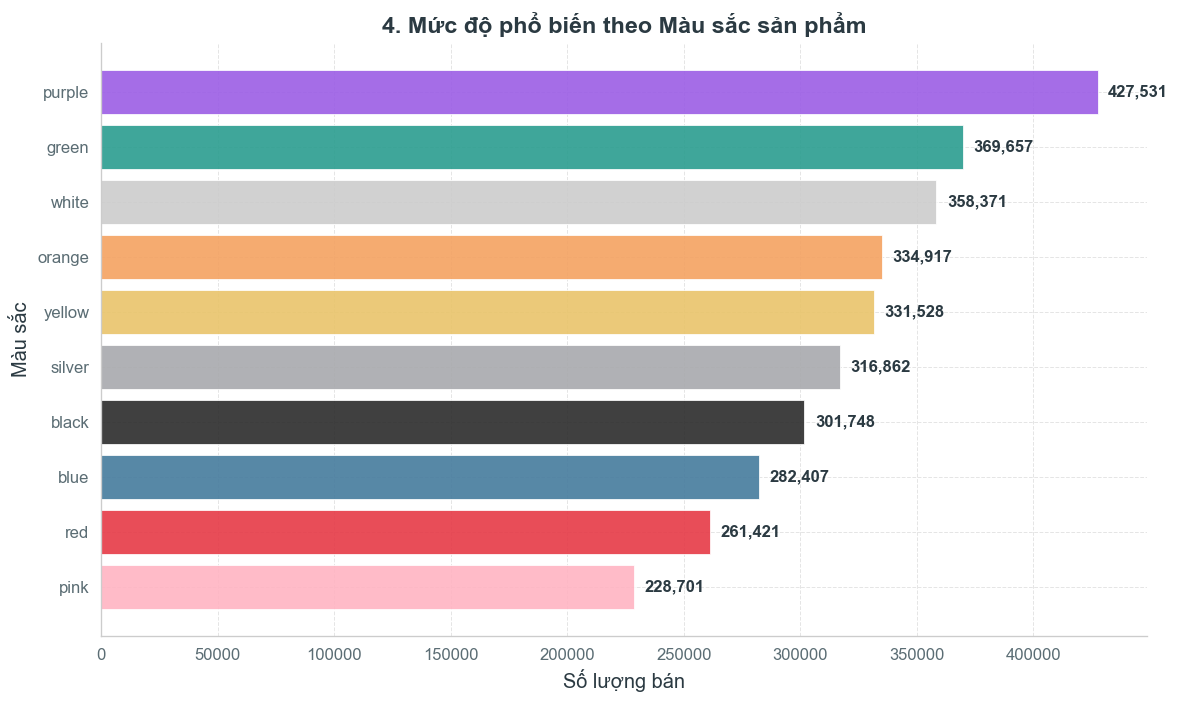

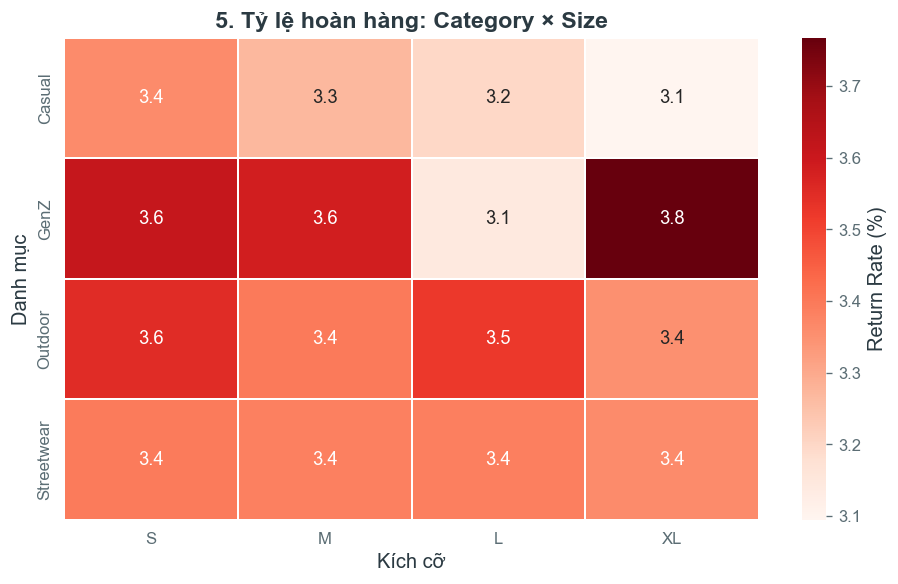

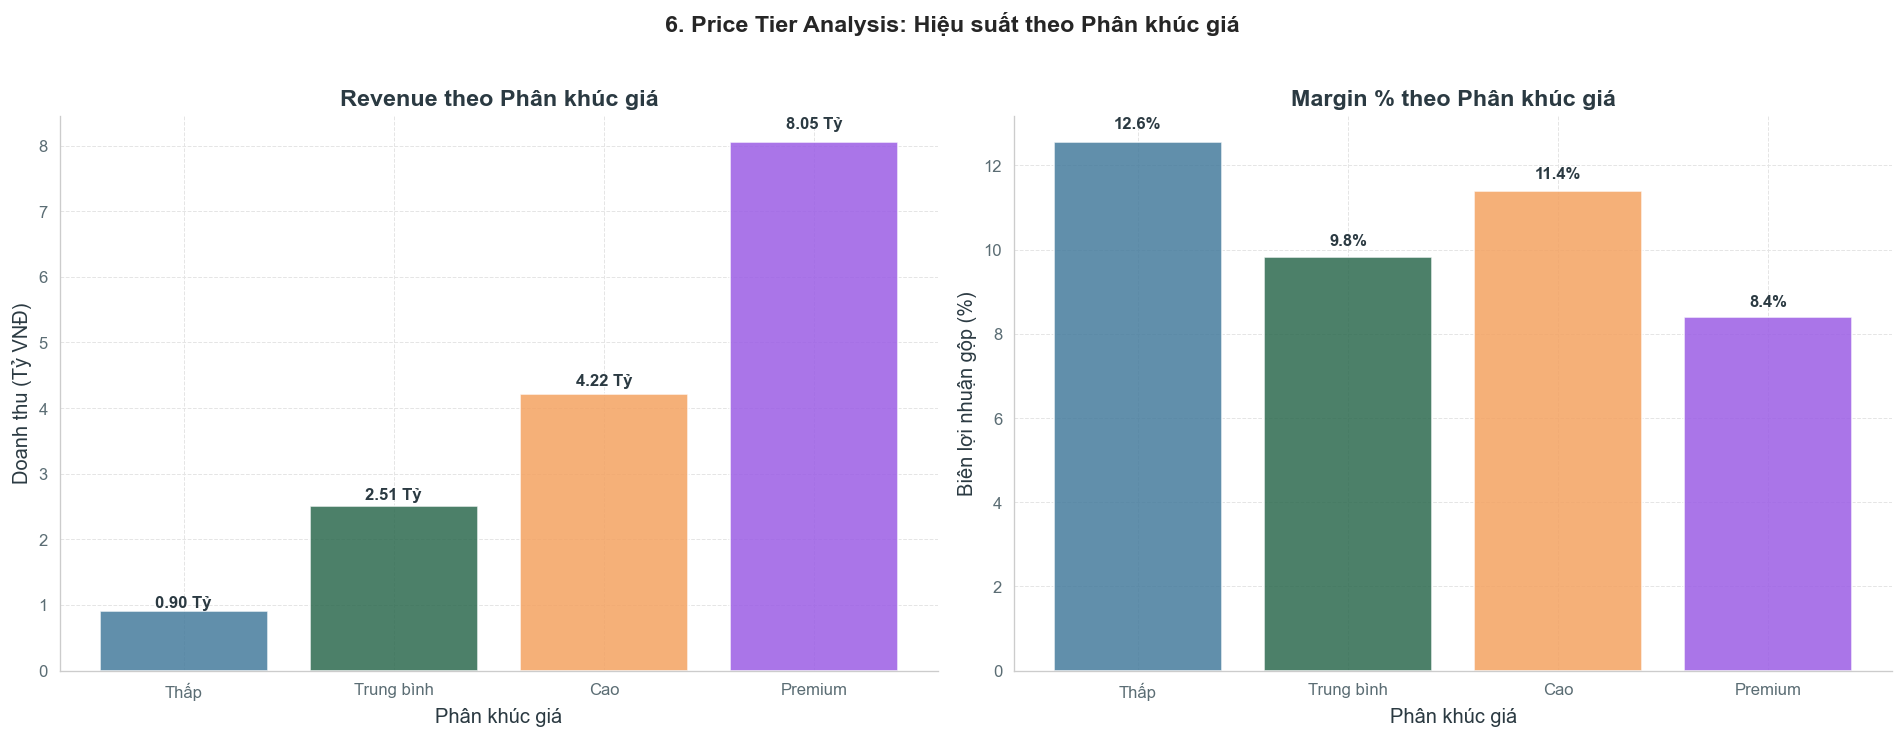

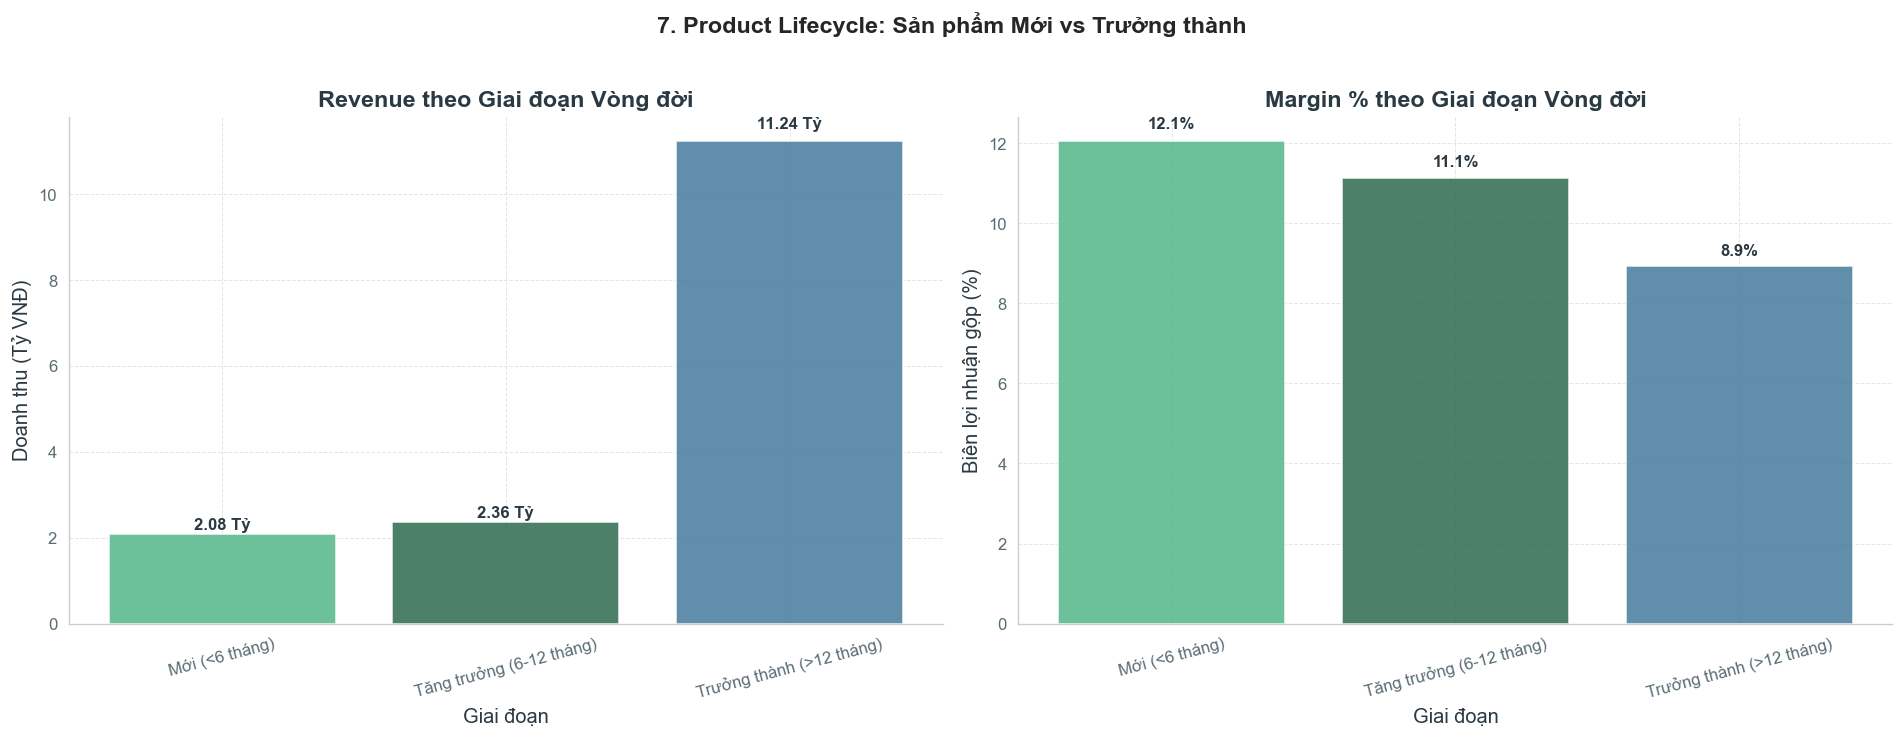

In [5]:
from src.eda_utils import plot_product_performance

plot_product_performance(dfs, master_df)


**"Bán CÁI GÌ sinh lời nhất?"**

*Phân tích Product Performance bóc trần nhiều nghịch lý đáng ngạc nhiên, đi ngược hoàn toàn với trực giác kinh doanh thông thường trong ngành thời trang.*

**1. Streetwear thống trị Doanh thu nhưng GenZ mới là "ngôi sao" lợi nhuận**

Streetwear chiếm vị thế áp đảo với 12.5 Tỷ VNĐ doanh thu, nhưng Margin chỉ đạt ~9.5% — mức trung bình thấp. Ngược lại, GenZ dù doanh thu khiêm tốn (~0.3 Tỷ) lại sở hữu Margin cao nhất (~15%). Đây là tín hiệu cho thấy doanh nghiệp đang phụ thuộc quá lớn vào một danh mục "bán nhiều nhưng lời ít". Nếu Streetwear gặp sự cố (đối thủ cạnh tranh, thay đổi xu hướng), toàn bộ biên lợi nhuận sẽ sụp đổ.

**2. Long-tail Problem: Hàng trăm sản phẩm "chết lâm sàng"**

Biểu đồ Best vs Worst seller cho thấy một khoảng cách khổng lồ: Top 1 (HanoiStreet RP-79) bán được 45,986 đơn vị, trong khi hàng loạt sản phẩm như VietMode UR-03, SaigonFlex UC-84 chỉ bán được đúng 1 đơn vị. Đây là hiện tượng "Long-tail" điển hình — hàng tồn kho bị phân tán vào những SKU không ai mua, gây lãng phí không gian kho bãi và vốn lưu động.

**3. Size XL bán chạy nhất — Bất ngờ lớn nhất**

Trái với giả định phổ biến rằng Size M hoặc L sẽ chiếm ưu thế (vì là size phổ thông), dữ liệu cho thấy **XL dẫn đầu với 867,187 đơn vị**, vượt xa Size S (774,468). Điều này gợi ý rằng tệp khách hàng của doanh nghiệp có xu hướng thích form rộng (Oversize/Relaxed fit) — đặc biệt phù hợp với phong cách Streetwear và GenZ đang thịnh hành. Đội ngũ Merchandising cần ưu tiên đặt hàng Size XL nhiều hơn từ nhà cung cấp.

**4. Màu tím (Purple) bất ngờ dẫn đầu**

Không phải Đen hay Trắng — hai gam màu "an toàn" kinh điển — mà chính màu Tím (Purple) với 427,531 đơn vị mới là màu bán chạy nhất. Tiếp theo là Xanh lá (Green, 369,657) và Trắng (White, 358,371). Màu Hồng (Pink) xếp cuối bảng (228,701). Xu hướng này phản ánh sự dịch chuyển gu thẩm mỹ của người tiêu dùng trẻ sang các tông màu "nổi bật, cá tính" thay vì trung tính.

**5. Nghịch lý Giá: Sản phẩm giá Thấp lời nhất, Premium lời ít nhất**

Price Tier Analysis hé lộ một nghịch lý quan trọng: Nhóm giá Thấp có Margin cao nhất (12.6%), trong khi nhóm Premium tuy mang về doanh thu khổng lồ (8.05 Tỷ) nhưng Margin chỉ đạt 8.4%. Nguyên nhân có thể do sản phẩm Premium phải chịu chi phí nguyên vật liệu cao (COGS sát giá bán), hoặc bị ép giảm giá để cạnh tranh ở phân khúc cao cấp. Doanh nghiệp đang đổi Margin lấy Volume ở phân khúc Premium.

---
**Hành động Chiến lược:**

- **Mở rộng dòng GenZ:** Đầu tư phát triển thêm SKU cho danh mục GenZ để tận dụng Margin 15% vượt trội. Đây là "mỏ vàng" chưa được khai thác đúng mức.

- **Thanh lý hàng Long-tail:** Lập danh sách toàn bộ sản phẩm bán dưới 10 đơn vị/năm, áp dụng chính sách Flash Clearance hoặc ngừng sản xuất để giải phóng vốn lưu động.

- **Điều chỉnh Tỷ trọng đặt hàng Size:** Tăng tỷ trọng Size XL lên 30-35% trong mỗi đợt order nhà cung cấp (thay vì chia đều 25% mỗi size), giảm rủi ro stockout ở size bán chạy nhất.

- **Review chiến lược giá Premium:** Đánh giá lại cơ cấu COGS của nhóm Premium, tìm cách cắt giảm chi phí nguyên liệu hoặc tái định vị giá bán để nâng Margin từ 8.4% lên mức chấp nhận được (>12%).


---

## 3. Rò rỉ doanh thu từ Hủy đơn và Hoàn trả

Phần này phân tích chi tiết về các đơn hàng bị hủy, trả lại, lý do hoàn hàng, tác động của thời gian giao đến đánh giá khách hàng, và ước tính thiệt hại doanh thu do các vấn đề này.

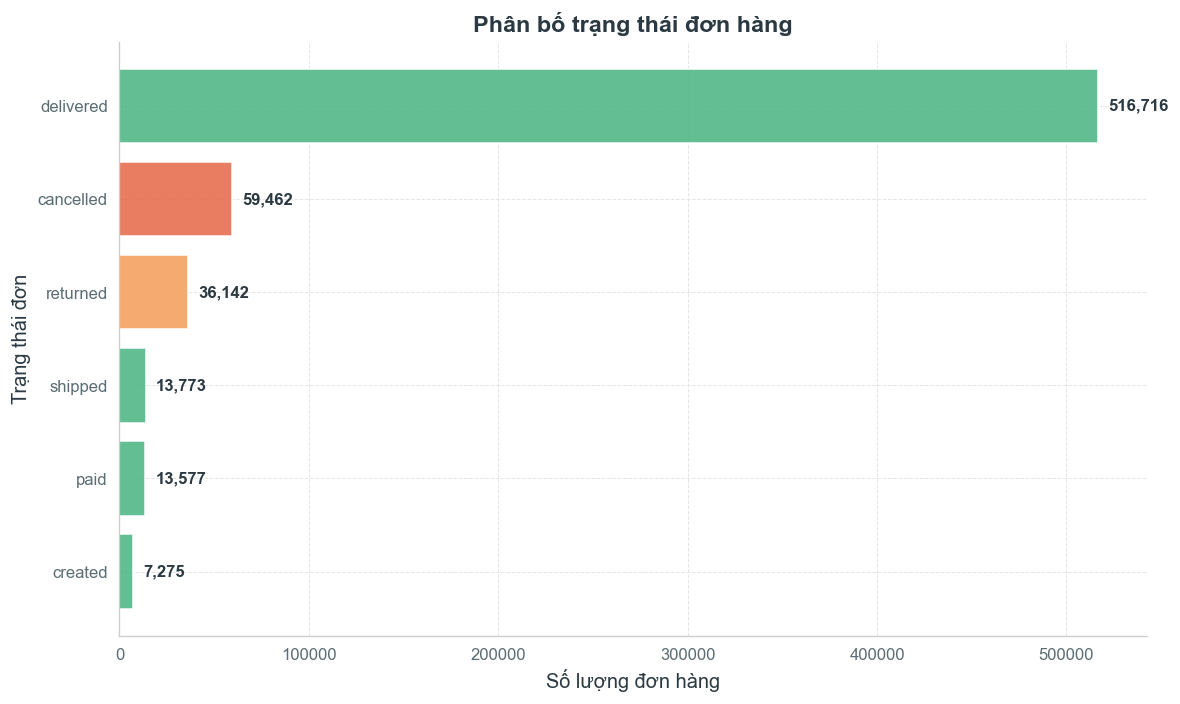

In [6]:
section_header('Phân tích Rủi ro Vận hành & Trải nghiệm Khách hàng')
plot_order_status_distribution(dfs['orders'])

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:1128: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_rates = orders.groupby('payment_method').apply(


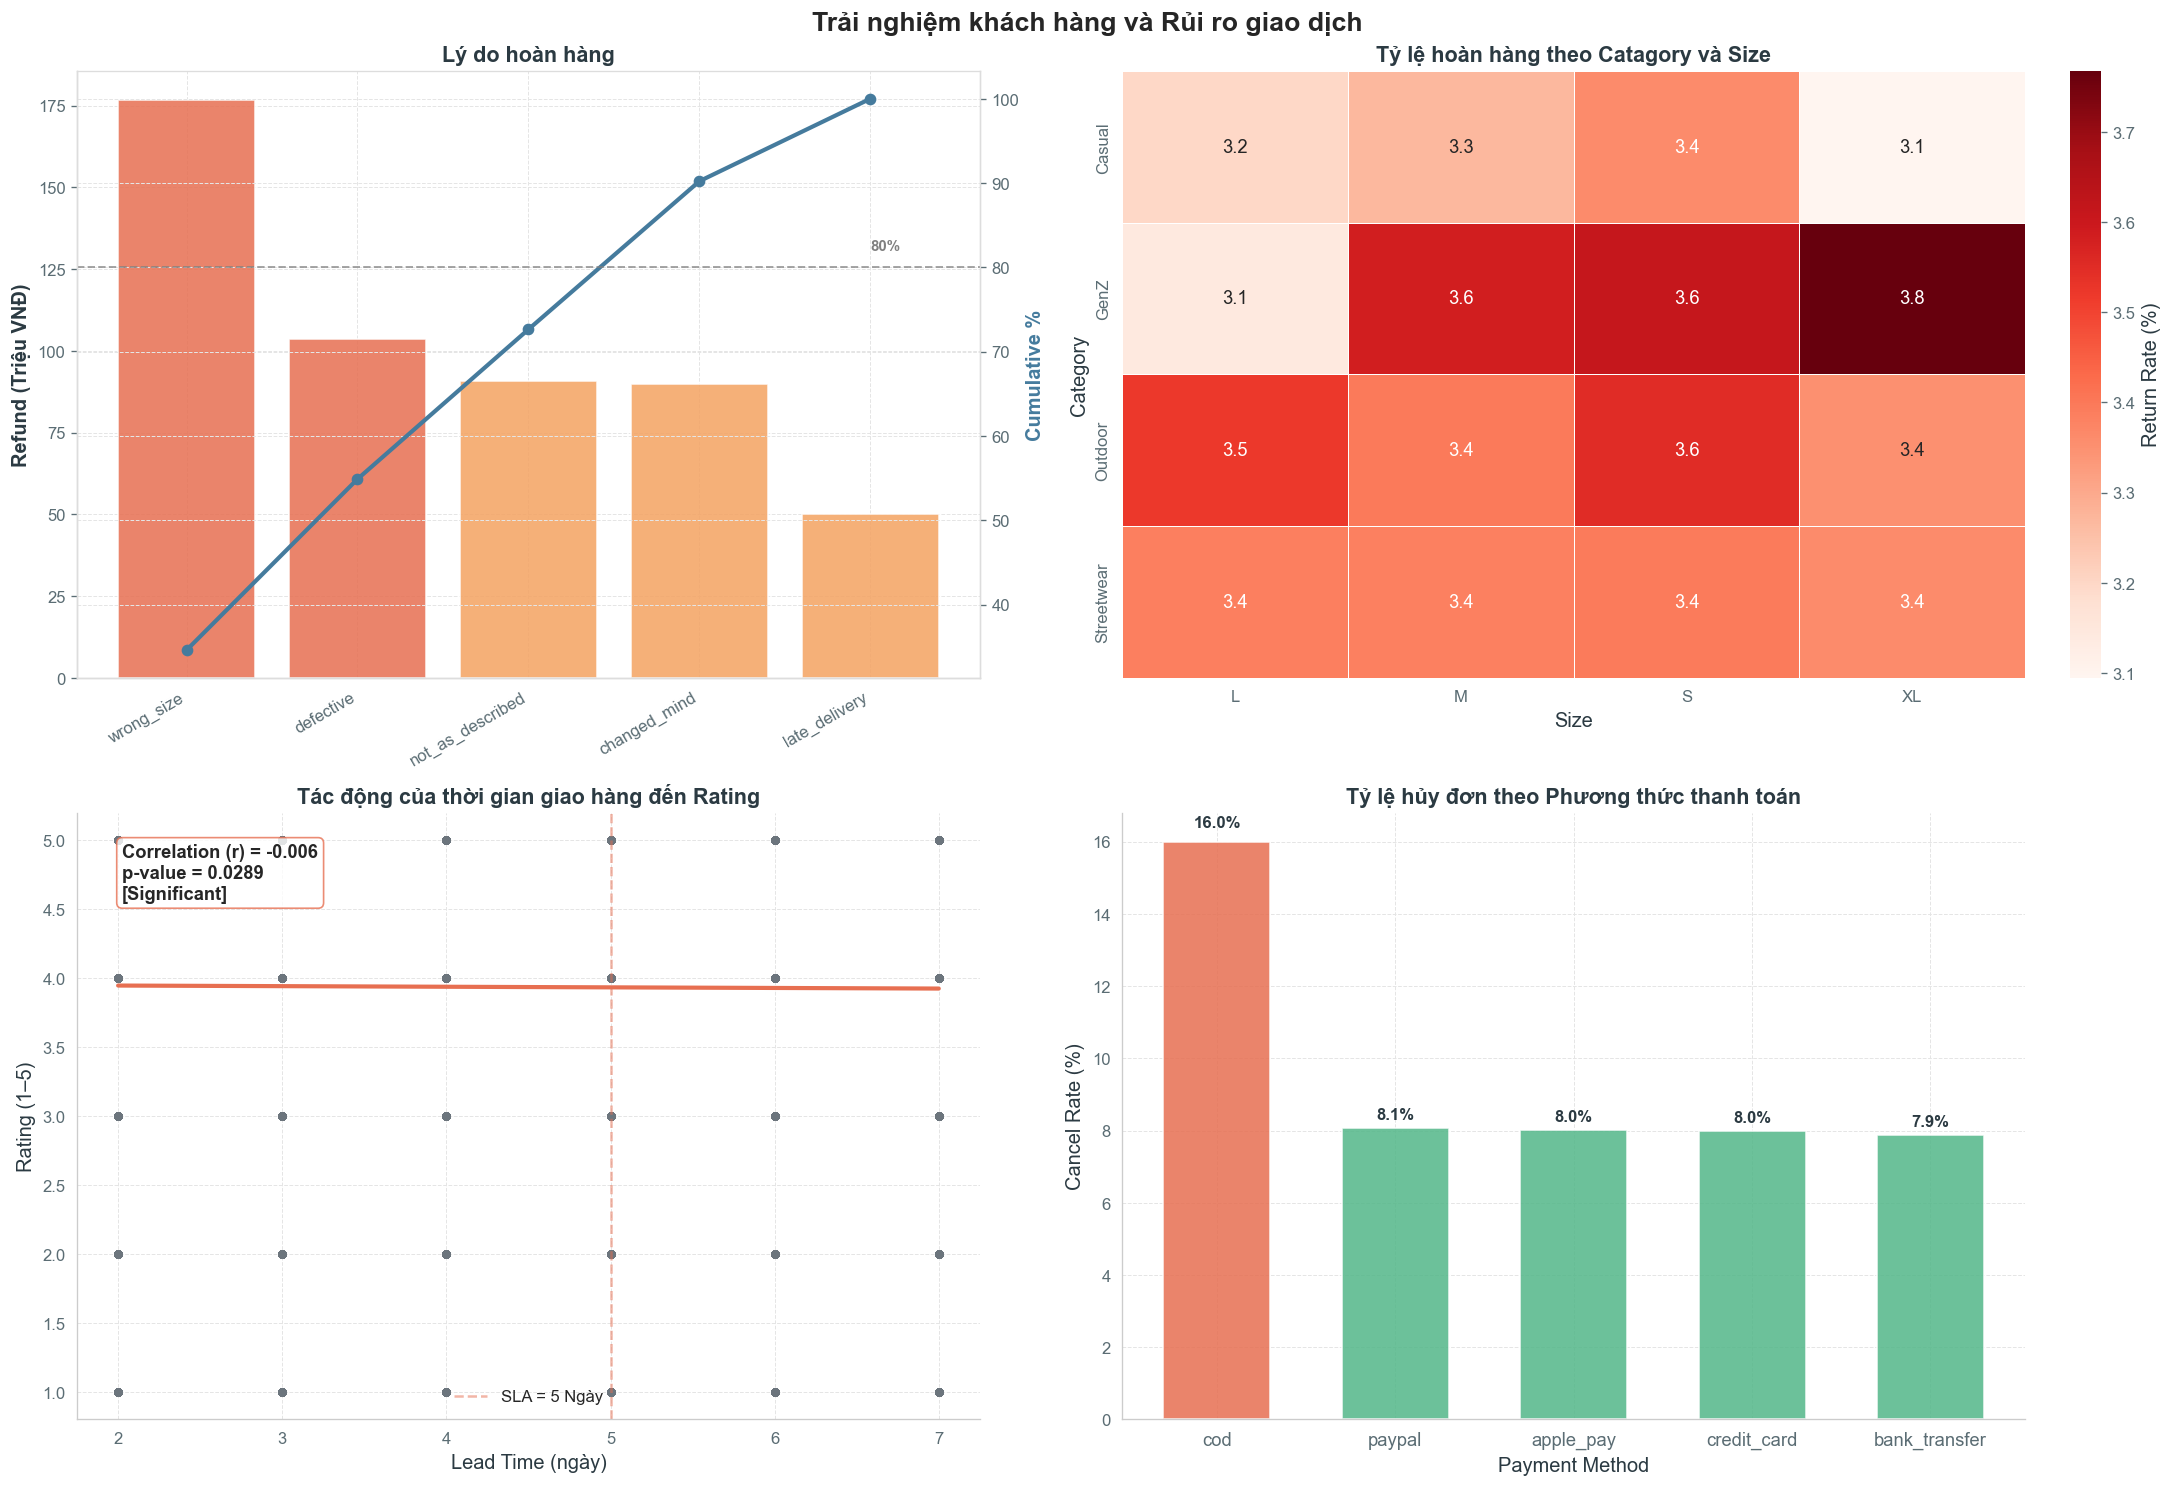

In [7]:
plot_returns_cancellations_deepdive(
    returns=dfs['returns'], 
    products=dfs['products'], 
    order_items=dfs['order_items'], 
    reviews=dfs['reviews'], 
    shipments=dfs['shipments'], 
    orders=dfs['orders'], 
    save_fig=True
)

**Hoàn trả và hủy đơn là tổn thất kép**: doanh nghiệp mất doanh thu, gánh chi phí vận chuyển ngược, và quan trọng nhất — đánh mất cơ hội giữ chân khách hàng tiềm năng. Từ bốn biểu đồ phân tích, nổi lên các quan sát sau:

- **Ba nguyên nhân cốt lõi gây ra hơn 70% tổn thất**, dẫn đầu là `wrong_size` (sai kích cỡ) chiếm tới 35%, tiếp theo là `defective` (hàng lỗi). Riêng hai nguyên nhân này đã cộng dồn gần 55%. Điều này cho thấy gốc rễ vấn đề không nằm ở dịch vụ, mà ở **sự phù hợp và chất lượng vật lý của sản phẩm**.
  - **Hành động:** Cần làm rõ và cải thiện bảng hướng dẫn chọn size trên website, bổ sung công cụ gợi ý kích cỡ theo số đo cơ thể. Đồng thời, siết chặt khâu kiểm tra chất lượng (QC) trước khi xuất kho để giảm tỷ lệ hàng lỗi đến tay khách.

- **Tỷ lệ hoàn hàng trung bình dao động 3.1%–3.7%**, trong đó ngành hàng GenZ có tỷ lệ cao nhất, đặc biệt ở các size M (3.58%), S (3.61%) và đỉnh điểm là XL (3.76%).
  - **Hành động:** Cần rà soát form dáng và thông số kỹ thuật dòng GenZ, nhất là size XL. Nên triển khai tính năng đánh giá kèm ảnh thực tế và số đo người mua để khách sau dễ đối chiếu trước khi đặt.

- **Thời gian giao hàng chậm hầu như không ảnh hưởng đáng kể** đến mức độ hài lòng hay tỷ lệ hoàn trả. Đây không phải nguyên nhân chính dẫn đến hủy/trả đơn.

- **COD là phương thức có tỷ lệ hủy đơn vượt trội**, chạm mức 16.0% — gần gấp đôi so với nhóm thanh toán trước (Credit Card, Apple Pay, PayPal, Bank Transfer chỉ dao động 7.9%–8.0%).
  - Khi không bị ràng buộc tài chính ban đầu, tâm lý dễ thay đổi quyết định hoặc "bom hàng" tăng rõ rệt.
  - **Hành động:** Khuyến khích khách chuyển sang thanh toán trước bằng các ưu đãi: miễn phí vận chuyển, chiết khấu 5%, hoặc tặng điểm thành viên. Đối với đơn COD giá trị lớn, cân nhắc thêm bước xác nhận qua điện thoại hoặc yêu cầu đặt cọc một phần.


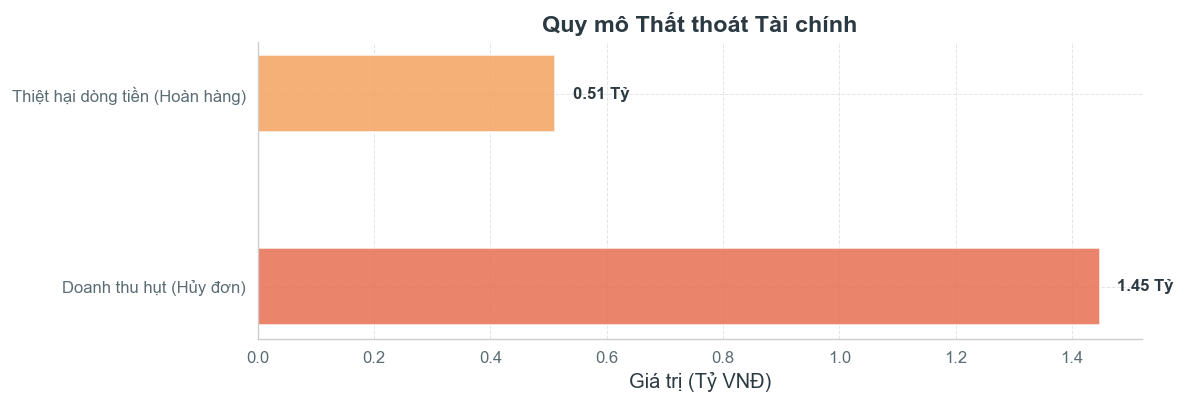

In [8]:
section_header(
    title='Định lượng Tổn thất Tài chính', 
    subtitle='Quy đổi tỷ lệ Hủy đơn và Hoàn hàng thành thiệt hại dòng tiền và chi phí cơ hội thực tế'
)

# Khởi chạy tính toán và lưu kết quả vào biến leakage_metrics
leakage_metrics = plot_revenue_leakage_impact(
    master_df=master_df, 
    returns=dfs['returns'], 
    shipments=dfs['shipments'], 
    save_fig=True
)

Khối lượng doanh thu ảo (doanh thu hụt) bị bốc hơi do khách hàng hủy đơn lên tới 1.45 Tỷ VNĐ, cao gấp gần 3 lần so với thiệt hại gây ra bởi việc hoàn hàng (0.51 Tỷ VNĐ).

Mặc dù phí vận chuyển lãng phí do hoàn hàng chỉ ở mức 200,000 VNĐ, nhưng tổng dòng tiền chảy ngược ra khỏi doanh nghiệp đạt hơn 500 triệu VNĐ. Đây là rủi ro hiện hữu vì doanh nghiệp đã phải gánh chi phí xuất kho, đóng gói, vận chuyển, sau đó lại tốn thêm chi phí reverse logistics khi hàng quay về.

**Chuẩn đoán**

Mức thất thoát 1.45 Tỷ VNĐ từ hủy đơn có sự đóng góp lớn từ phương thức thanh toán COD (như phân tích ở biểu đồ tỷ lệ hủy đơn theo phương thức thanh toán đạt 16%). Việc dễ dàng click đặt hàng mà không có rào cản tài chính ban đầu đã tạo ra một lượng "doanh thu ảo" khổng lồ, khiến hệ thống ghi nhận nhu cầu sai lệch, dẫn đến việc giam vốn vào hàng tồn kho không cần thiết.

**Đề xuất phương án:**

- Giảm thiểu rủi ro COD: Áp dụng phí cọc tượng trưng hoặc giới hạn giá trị tối đa cho đơn hàng COD.

- Khuyến khích thanh toán trước: Chuyển đổi 1.45 tỷ đồng doanh thu hụt tiềm năng này thành doanh thu thực tế bằng cách chiết khấu 2-5% (vẫn thấp hơn tỷ suất lợi nhuận gộp lỡ mất) cho khách hàng thanh toán qua Credit Card/Apple Pay/Bank Transfer để "khóa" cam kết mua hàng của họ.

**Phân tích chuyên sâu về Hoàn hàng (Returns Diagnostics)**

Để có cái nhìn sâu sắc hơn về nguyên nhân dẫn đến tỷ lệ hoàn hàng cao, chúng ta cần phân tích theo chiều sâu, đặc biệt tập trung vào các đặc tính của sản phẩm (Kích thước, Danh mục) và trải nghiệm giao hàng.

1. **Tỷ lệ hoàn hàng theo Size và Category:** Việc đánh giá xem nhóm sản phẩm nào, kích cỡ nào gặp vấn đề về 'Fit/Sizing' sẽ giúp cải thiện mô tả sản phẩm và bảng quy đổi kích cỡ.
2. **Dự đoán Hoàn hàng do Lỗi (Defective):** Sử dụng thuật toán Decision Tree (Cây quyết định) để khám phá các mẫu/luật ẩn liên quan đến sản phẩm bị lỗi.
3. **Tương quan giữa Thời gian giao hàng (Lead time) và Đánh giá (Rating):** Việc chậm trễ trong khâu vận chuyển ảnh hưởng thế nào đến sự hài lòng của khách hàng?

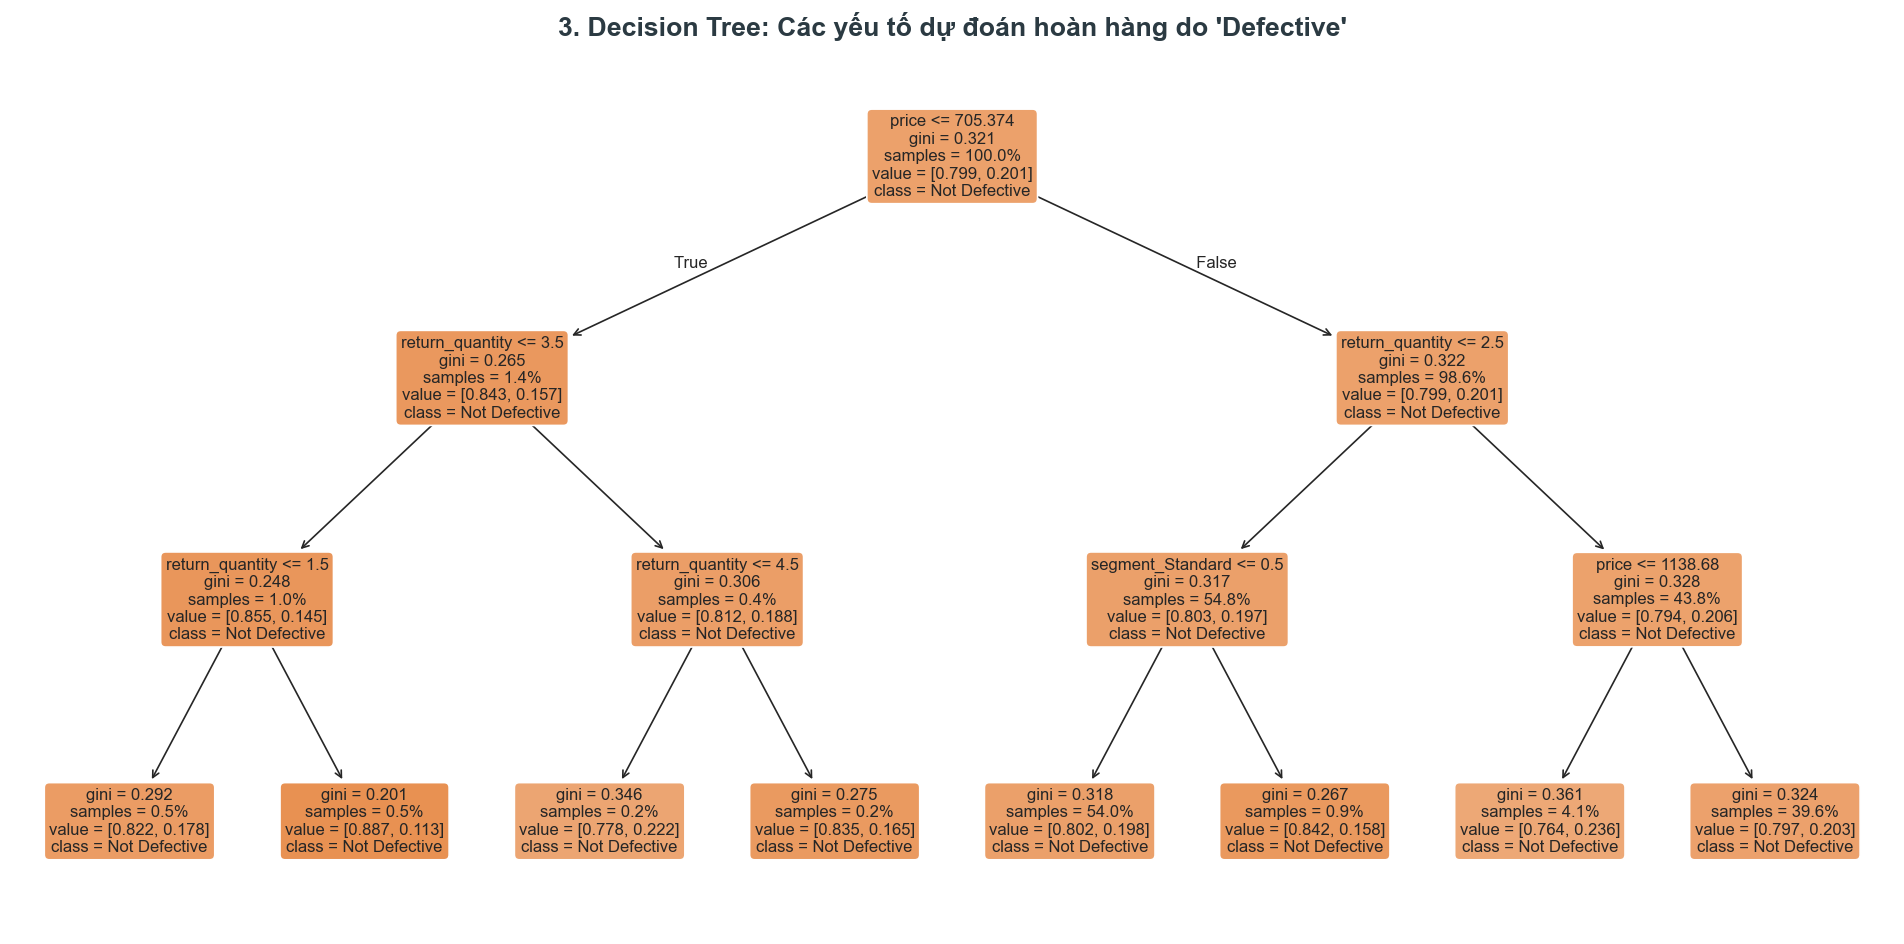

In [9]:
from src.eda_utils import plot_returns_deep_dive

plot_returns_deep_dive(dfs)


**Giải mã bài toán Hoàn Hàng & Sự hài lòng**

*Khác với những phán đoán theo cảm tính thông thường, dữ liệu đã vẽ nên một bức tranh hoàn toàn bất ngờ. Hãy cùng đi qua 4 lăng kính phân tích để định vị chính xác những "lỗ hổng" đang ăn mòn lợi nhuận.*

**1. Hiện trạng (Descriptive): Kích cỡ có thực sự là thủ phạm?**

- Nhìn lướt qua, tỷ lệ hoàn hàng dường như dàn đều ở mọi kích cỡ (quanh mức 3.4% - 3.5%). Tuy nhiên, khi dùng Bản đồ nhiệt (Heatmap) để "soi" sâu vào từng ngóc ngách, chúng ta lập tức phát hiện những đốm lửa nhỏ: **Sản phẩm thuộc nhóm GenZ size XL có tỷ lệ hoàn vọt lên mức cao nhất (3.8%)**. Điều này chứng tỏ tệp khách hàng trẻ tuổi đang bị "lạc lối" khi ước lượng form dáng quần áo trên nền tảng của chúng ta.

**2. Chẩn đoán (Diagnostic): Giải oan cho đội ngũ Giao vận**

- Trực giác thường mách bảo: *Giao hàng càng chậm, khách bực mình và đánh giá sao càng thấp.* Nhưng dữ liệu lại thẳng thừng bác bỏ điều đó! Hệ số tương quan gần như bằng 0 chứng minh rằng: **Khách hàng của chúng ta cực kỳ bao dung với thời gian chờ đợi.** Việc đơn hàng đến trễ vài ngày hoàn toàn không kéo tụt điểm Rating. Cốt lõi của sự hài lòng không nằm ở "Tốc độ", mà nằm ở chỗ sản phẩm khi mở hộp có đúng như kỳ vọng hay không.

**3. Dự báo rủi ro (Predictive): Hình hài của một món hàng Lỗi (Defective)**

- Thay vì ngồi chờ khách trả hàng, hệ thống *Cây quyết định (Decision Tree)* đã giúp chúng ta phác họa chân dung rủi ro. Mô hình phát hiện ra rằng, hàng bị lỗi không rải rác ngẫu nhiên mà tuân theo quy luật chặt chẽ về **Số lượng trả (Return Quantity)** và **Phân khúc giá**. Khi một lượng hàng lớn bị trả về cùng một lúc ở một mức giá nhất định, đó không phải là do người dùng khó tính, mà là hồi chuông báo động đỏ về **một lô hàng bị lỗi gia công hàng loạt** từ phía nhà cung cấp.

---

**Hành động Chiến lược (Prescriptive): Chuyển hướng mũi nhọn**

- **Chuyển ngân sách từ Logistics sang QA (Quản lý chất lượng):** Vì tốc độ giao hàng không quyết định độ hài lòng, hãy ngừng việc "đốt tiền" ép đối tác vận chuyển giao siêu tốc. Thay vào đó, lấy ngân sách đó đầu tư vào khâu kiểm duyệt chất lượng trước khi xuất kho. Chỉ cần hàng đẹp và không lỗi, khách sẽ luôn để lại 5 sao.

- **Cá nhân hóa Cẩm nang chọn Size (Fit Guide):** Dập tắt ngay nguy cơ hoàn hàng ở nhóm GenZ bằng cách cập nhật hình ảnh mô tả. Bổ sung ảnh người mẫu thực tế (kèm chiều cao, cân nặng rõ ràng) mặc size XL để khách dễ hình dung độ rủ của áo (oversize). Quản trị tốt kỳ vọng từ lúc xem ảnh sẽ triệt tiêu ý định hoàn hàng sau khi mặc thử.


---

## 4. Stockout, Overstock

Phần này cung cấp cái nhìn toàn diện về sức khỏe tồn kho, xác định nơi tập trung rủi ro, ước tính doanh thu bị mất do thiếu hàng, lượng vốn bị khóa trong thừa hàng, và các kịch bản thu hồi doanh thu.

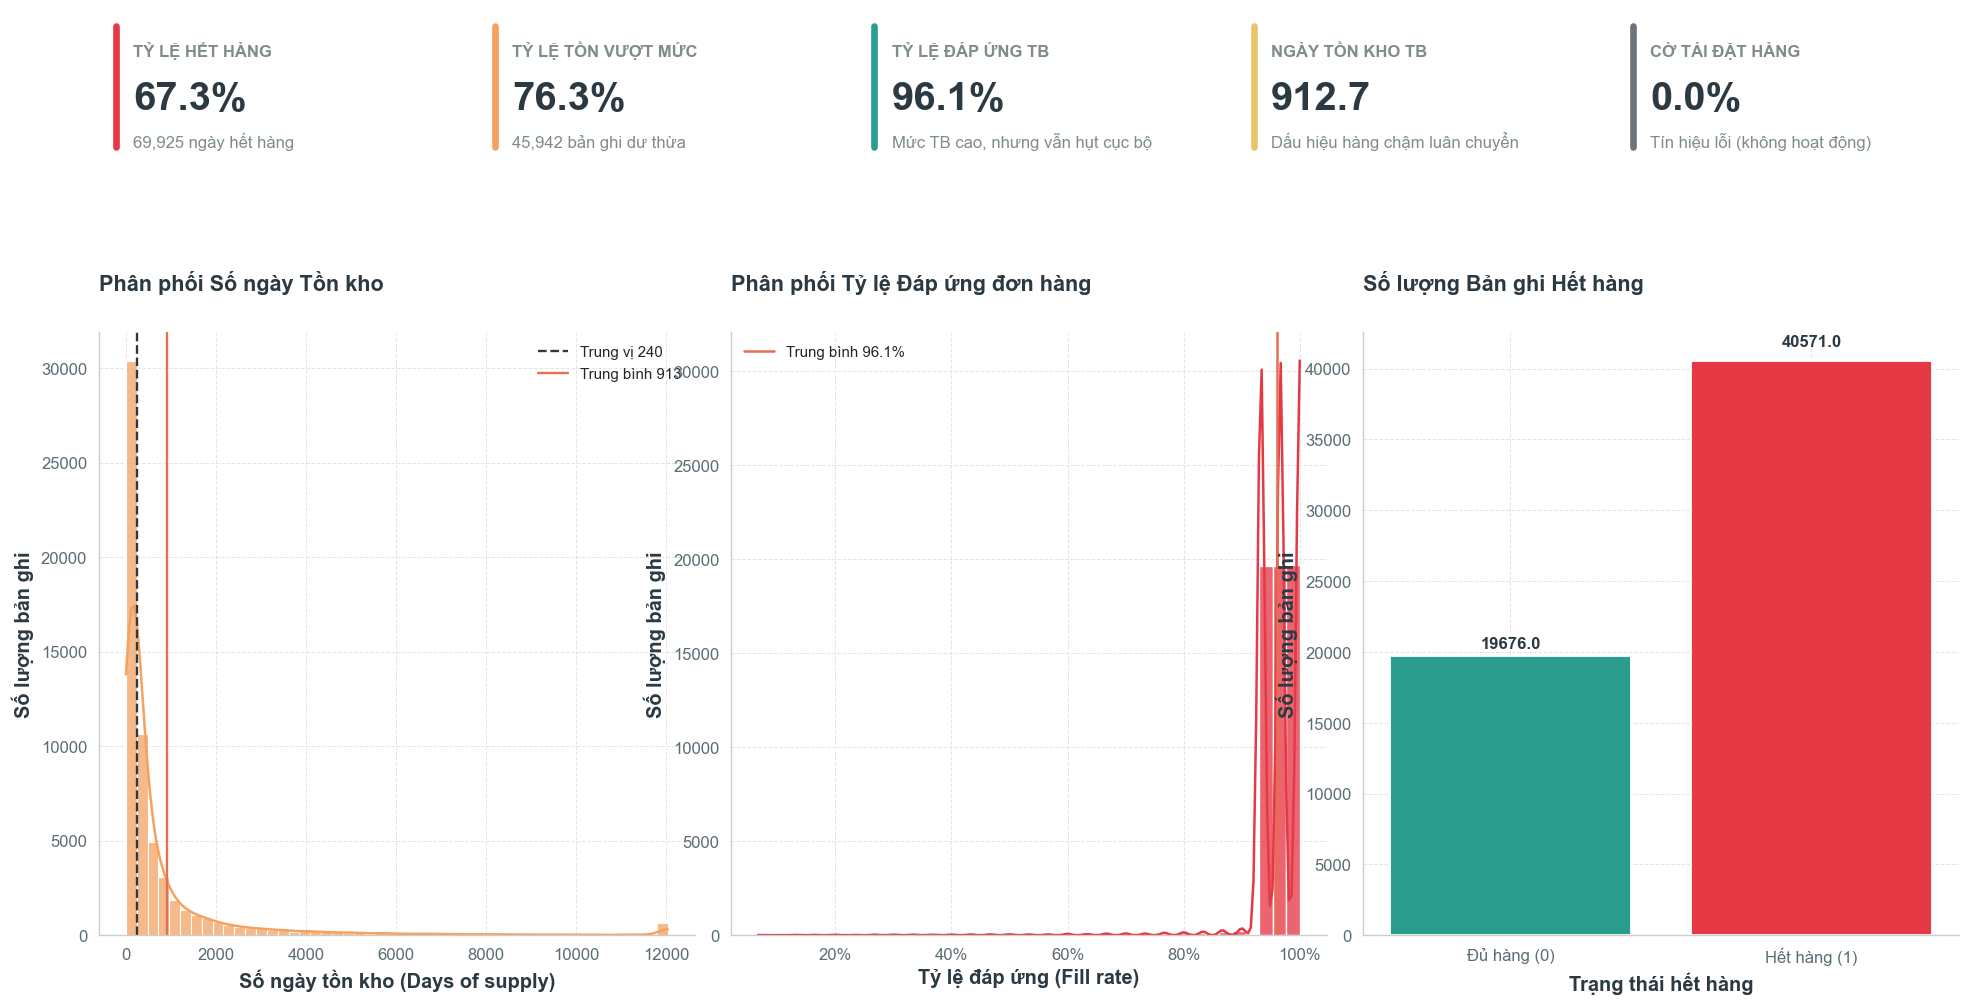

In [10]:
section_header(
    title='Phân tích Vận hành: Sức khỏe Tồn kho', 
    subtitle='Đánh giá rủi ro đứt gãy chuỗi cung ứng và tồn kho dư thừa'
)

# Gọi hàm với dữ liệu inventory
plot_inventory_health_overview(inv=dfs['inventory'], save_fig=True)

**Nghịch lý tồn kho: Thiếu hàng 67,3% — nhưng dư hàng lên tới 76,3%**

Bảng KPI cho thấy một thực tế tưởng như mâu thuẫn: tỷ lệ tháng/phân khúc xảy ra thiếu hàng (stockout) là **67,3%**, trong khi tỷ lệ dư hàng (overstock) cũng chạm mức **76,3%**. Nói cách khác, doanh nghiệp vừa thường xuyên không đủ hàng để bán, vừa có rất nhiều hàng đang nằm im trong kho.

Nếu thiếu hàng thực sự mang tính hệ thống, ta kỳ vọng tỷ lệ dư hàng sẽ thấp. Nhưng hai chỉ số cùng ở mức cao cho thấy bức tranh phức tạp hơn: **hàng có trong hệ thống, chỉ là chưa được đặt đúng nơi và đúng thời điểm cần bán**. Một số mã sản phẩm/tháng rơi vào thiếu hàng, trong khi những mã/tháng khác lại dư thừa. Tỷ lệ đáp ứng đơn hàng trung bình vẫn duy trì ở mức cao (**96,1%**) càng củng cố nhận định này — hệ thống không vận hành kém toàn diện, mà xuất hiện những **điểm đứt gãy cục bộ** theo từng SKU hoặc từng thời điểm cụ thể.

**Chẩn đoán:**
- Gốc rễ vấn đề không phải là "thiếu hàng" về mặt tổng thể, mà là **phân bổ hàng sai mã sản phẩm và sai thời điểm**.
- Tồn kho toàn hệ thống không thiếu. Hàng đang nằm sai SKU hoặc sai mùa vụ: nơi khách cần thì hết, nơi khách không cần thì ứ đọng — dẫn đến mất doanh thu ở đầu này và kẹt vốn ở đầu kia.

**Khuyến nghị hành động:**
Không nên phản ứng bằng cách nhập thêm hàng tràn lan cho toàn bộ danh mục. Thay vào đó, cần thiết lập cơ chế theo dõi tồn kho ở **cấp mã sản phẩm × tháng**, từ đó phân loại rõ: SKU nào thiếu thật cần bổ sung gấp, SKU nào dư thật cần giảm nhập hoặc xả hàng. Chỉ khi tách bạch được hai nhóm này, doanh nghiệp mới phá vỡ được vòng luẩn quẩn vừa thiếu vừa dư như hiện tại.

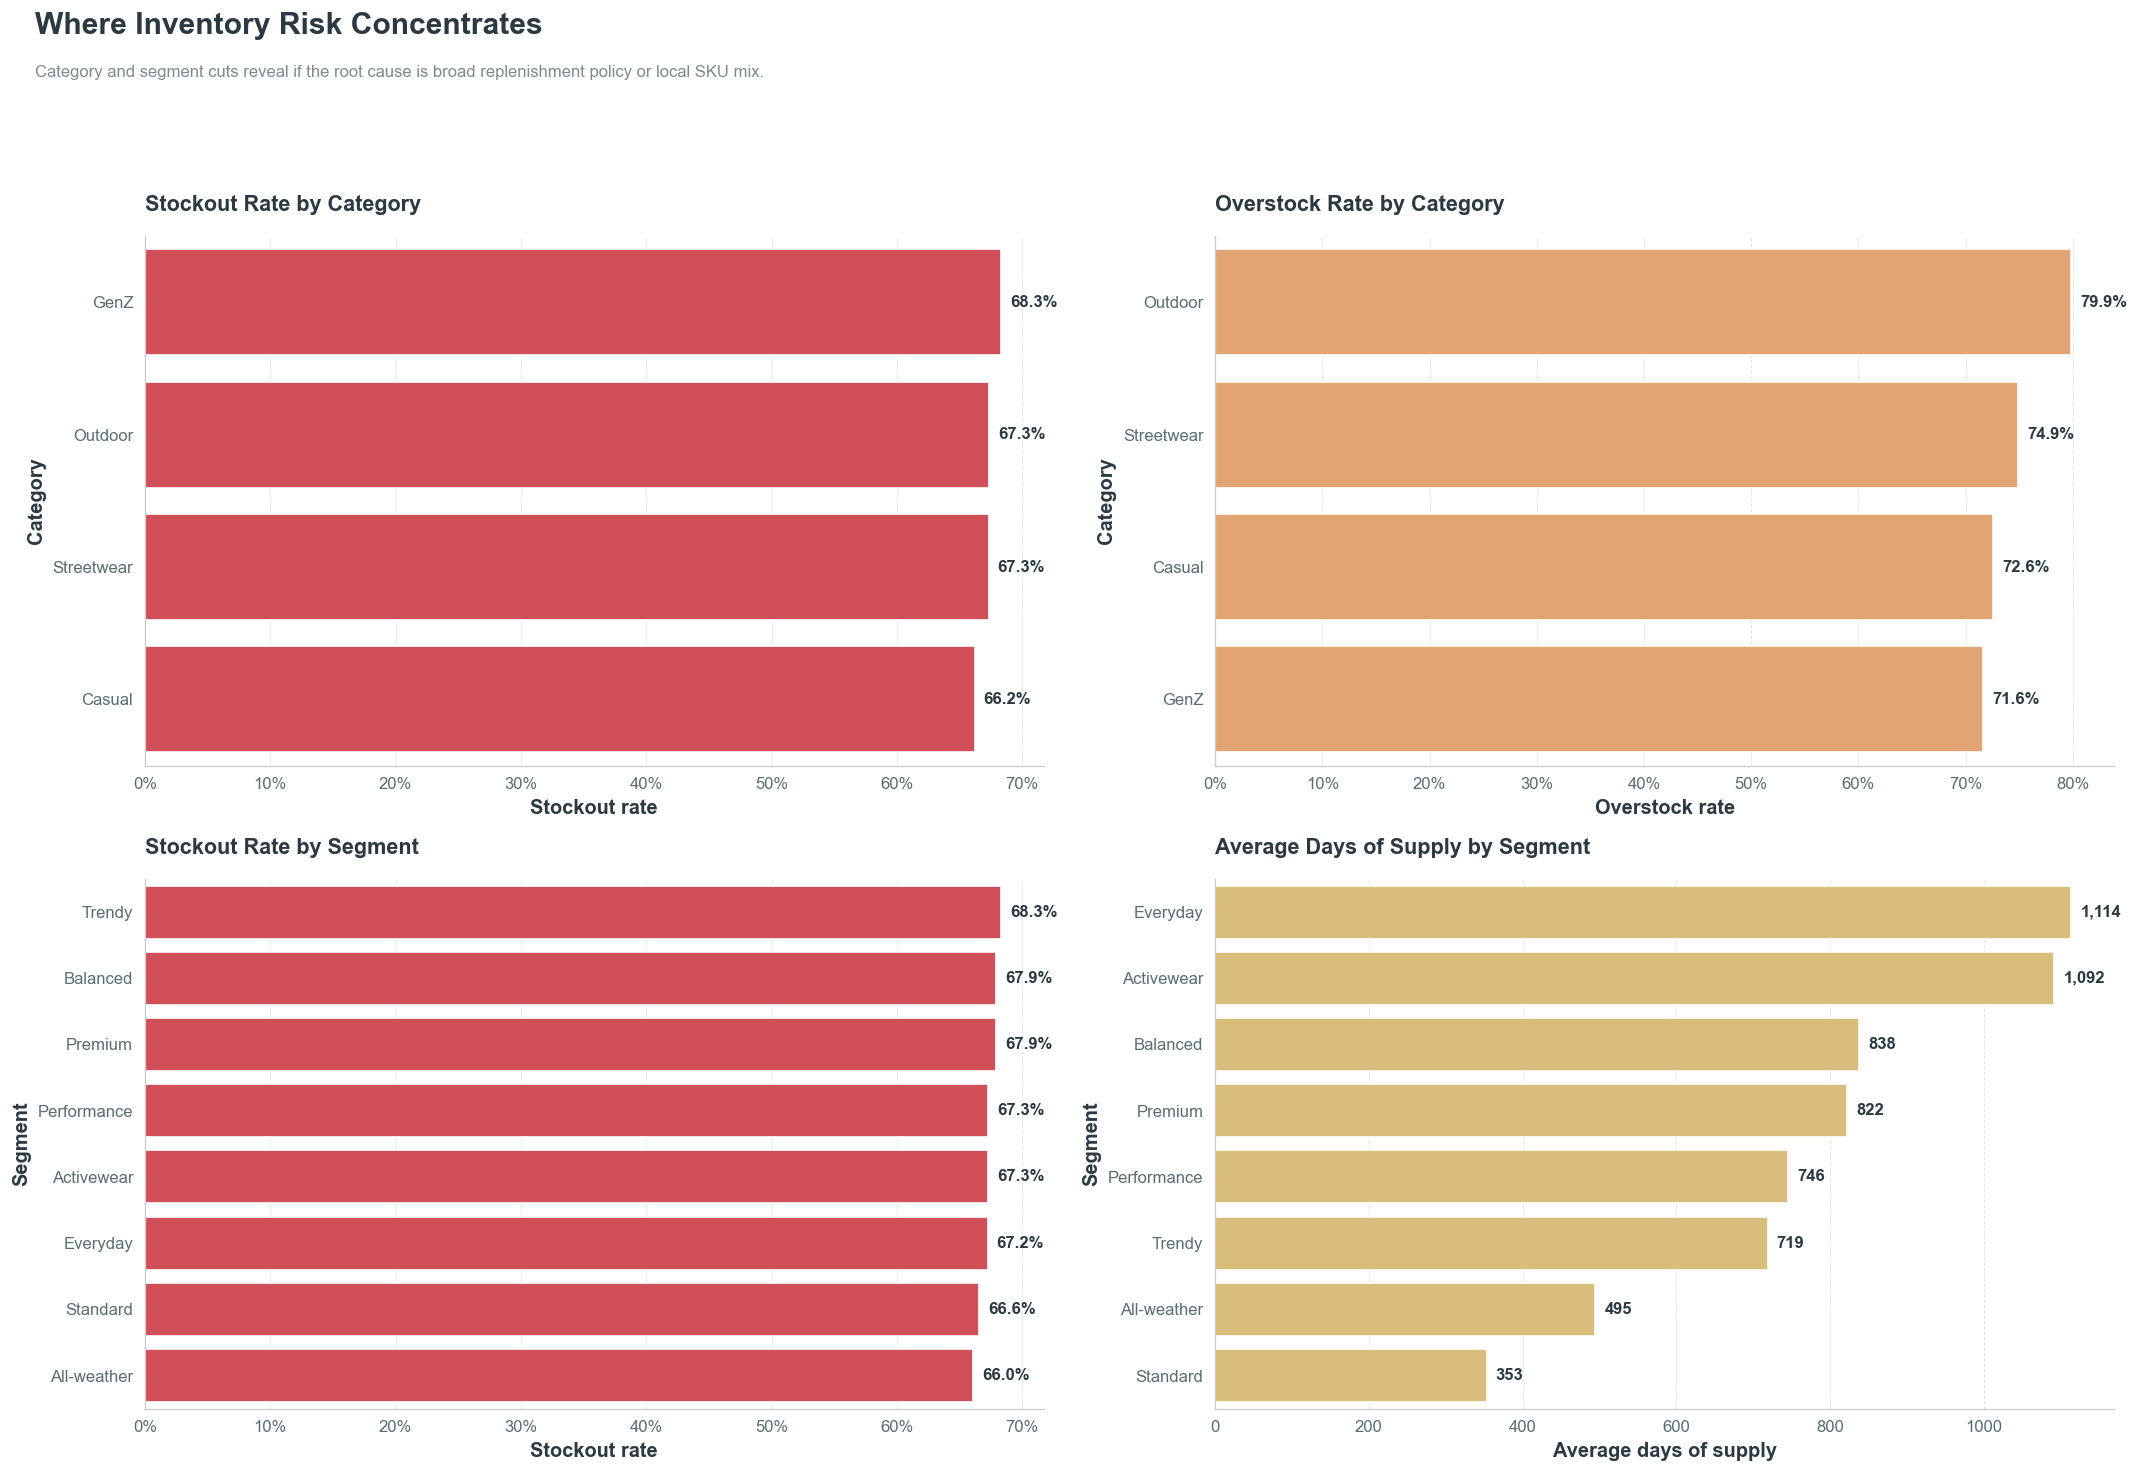

In [11]:
section_header(
    title='Định vị Điểm nghẽn Chuỗi cung ứng', 
    subtitle='Khoanh vùng rủi ro thiếu/thừa hàng hóa theo từng Nhóm và Phân khúc sản phẩm'
)

plot_inventory_risk_concentration(
    inventory=dfs['inventory'], 
    save_fig=True
)

**Thiếu hàng là vấn đề phổ rộng, nhưng rủi ro vận hành lại tập trung ở một vài nhóm hàng cụ thể.**

Xét theo danh mục, **GenZ** có tỷ lệ thiếu hàng cao nhất (**68,3%**), song danh mục thấp nhất cũng đã ở mức **66,2%** — chênh lệch chỉ vỏn vẹn **2,1 điểm phần trăm**. Điều này cho thấy stockout không phải vấn đề riêng của bất kỳ category nào, mà xuất hiện trải đều trên toàn danh mục sản phẩm.

Tuy nhiên, bức tranh thay đổi khi nhìn đồng thời cả thiếu hàng lẫn dư hàng. **Outdoor** nổi lên như một điểm nóng nghịch lý: vừa nằm trong nhóm thiếu hàng cao, vừa có tỷ lệ dư hàng (overstock) cao nhất toàn bộ — lên đến **79,9%**. Đây không đơn thuần là chuyện bán chậm hay hết hàng, mà là tín hiệu cảnh báo về **sai cơ cấu hàng tồn kho** trong nội bộ danh mục này. Ở cấp phân khúc, **Everyday** và **Activewear** ghi nhận số ngày tồn kho trung bình (days of supply) rất cao, cho thấy một phần vốn đáng kể đang bị kẹt ở nhóm hàng quay vòng chậm.

**Hành động khuyến nghị:** Thay vì quản lý ở cấp danh mục, cần đi sâu xuống cấp SKU. Với **Outdoor** và các segment có days of supply cao, phải phân biệt rõ: mã nào thực sự cần bổ sung hàng gấp, mã nào cần giảm nhập hoặc lên kế hoạch xả hàng. Nếu không tách bạch được hai nhóm này, doanh nghiệp sẽ tiếp tục rơi vào vòng luẩn quẩn: vừa mất doanh thu vì thiếu đúng mã khách cần, vừa chôn vốn vào những mã không bán được.

**Kết luận điều hành:** Stockout là vấn đề toàn danh mục, nhưng **Outdoor và các phân khúc tồn kho lâu là nơi cần chẩn đoán sâu trước tiên** — bởi đây chính là những điểm nóng hội tụ đủ cả hai rủi ro: mất doanh thu và kẹt vốn.

---
Hàm này sử dụng phương pháp **"Naive Linear Estimate"** – tức là giả định sức mua trong những ngày hết hàng hoàn toàn giống với những ngày có hàng. Mặc dù đây là một ước lượng cơ bản (tuyến tính), nhưng nó cung cấp một bức tranh tài chính đủ mạnh để ban lãnh đạo thấy được chi phí cơ hội khổng lồ của việc quản trị tồn kho yếu kém. 
Hàm giả định số ngày trong tháng là 30 và tính toán doanh thu bán hàng trung bình của một sản phẩm trong một ngày:
*   $\text{avg\_daily\_revenue} = \frac{\text{units\_sold} \times \text{price}}{30}$

Khi đã biết một ngày bán được bao nhiêu tiền, hàm sẽ nhân con số đó với số ngày sản phẩm bị hết hàng để ra được **tổng doanh thu bị lỡ mất**:
*   $\text{lost\_revenue\_est} = \text{stockout\_days} \times \text{avg\_daily\_revenue}$

Doanh thu to không có nghĩa là lãi lớn. Để báo cáo sắc bén hơn, hàm tiếp tục tính toán xem công ty thực sự mất đi bao nhiêu **tiền lãi** (sau khi đã trừ giá vốn):
*   Trước tiên, tính Biên lợi nhuận gộp: $\frac{\text{price} - \text{cogs}}{\text{price}}$
*   Sau đó, nhân tỷ lệ này với Doanh thu thất thoát ở bước 3: 
    $\text{lost\_margin\_est} = \text{lost\_revenue\_est} \times \text{Gross Margin Percentage}$




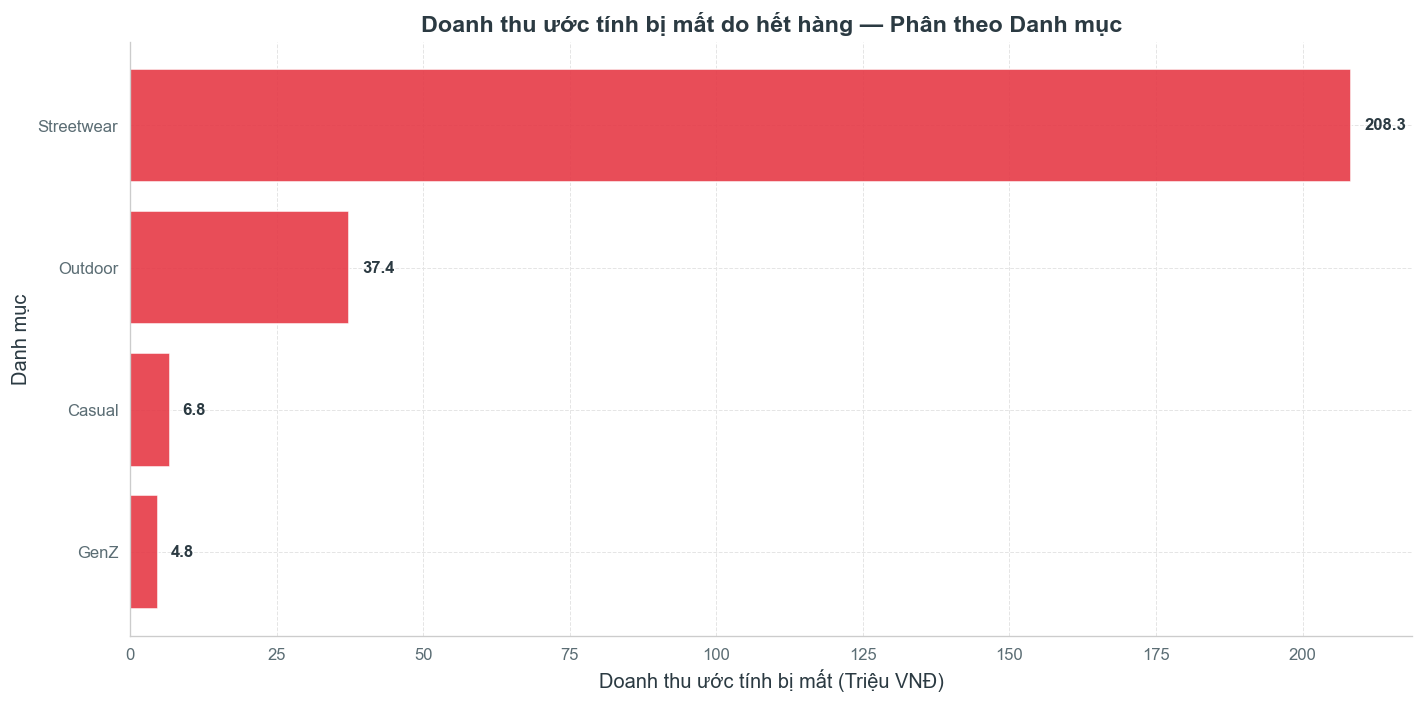

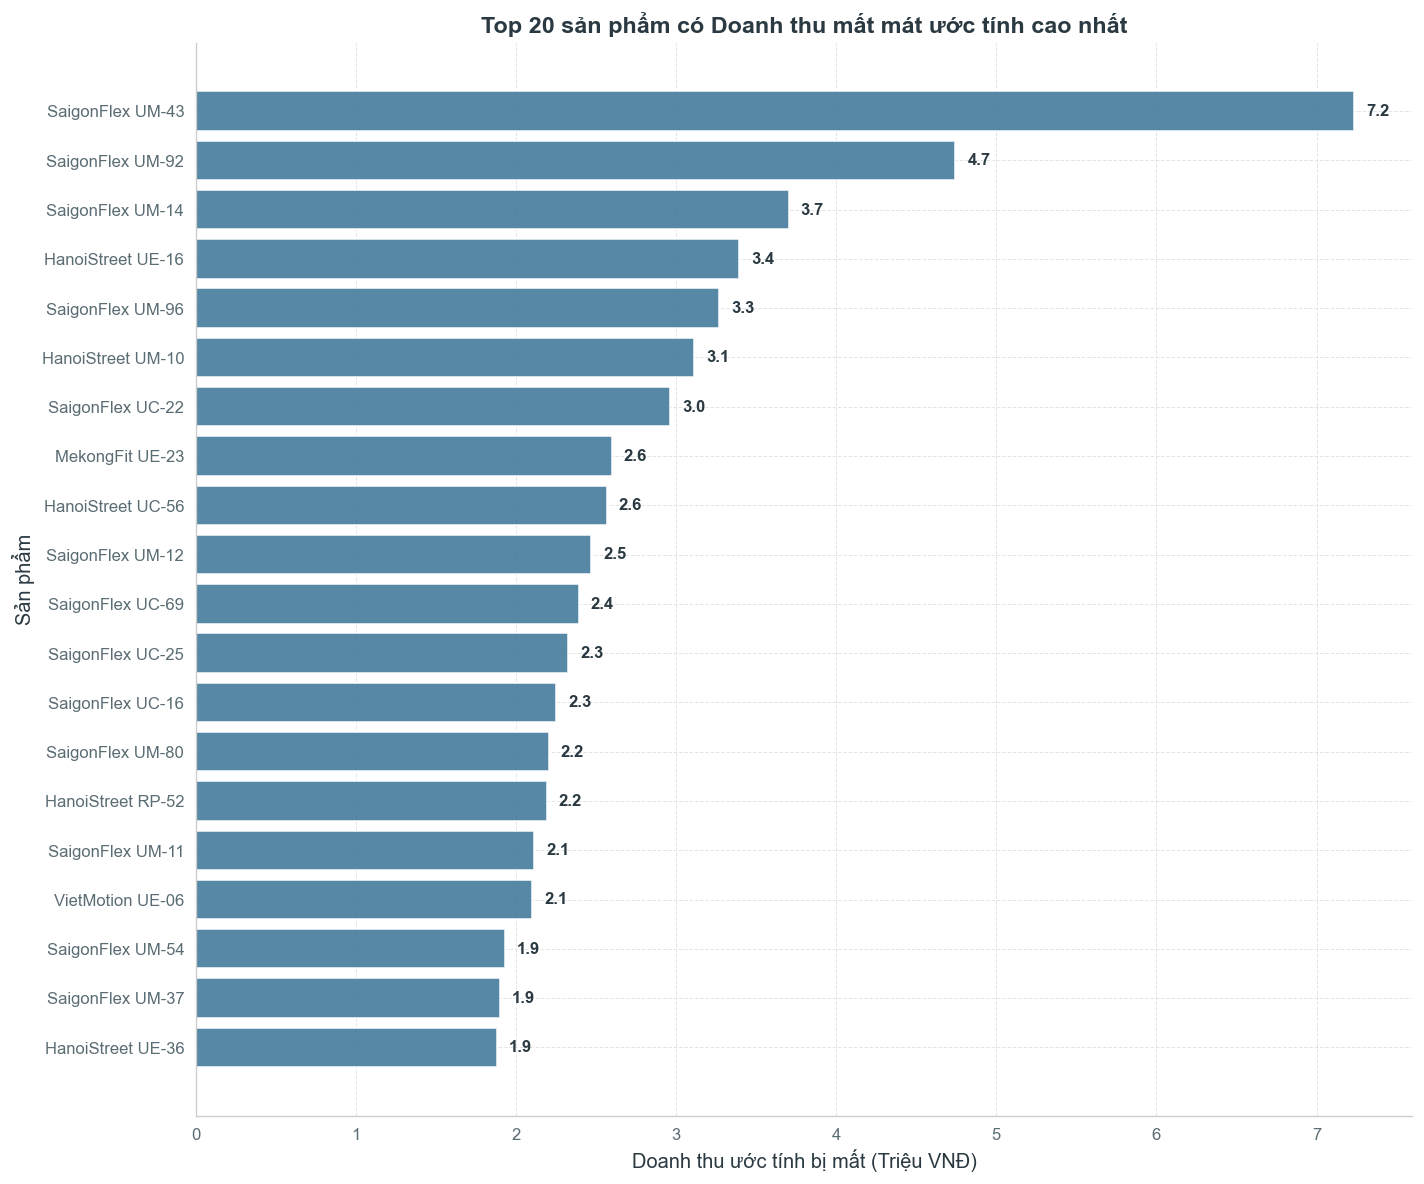

In [12]:
section_header('Impact của stockout', 'Ước tính thiệt hại doanh thu do hàng hết kệ')
stockout_loss_df = estimate_stockout_impact(dfs['inventory'], dfs['products'])
plot_stockout_loss_by_category(stockout_loss_df)
plot_top_products_lost_revenue(stockout_loss_df, top_n=20)

**Thiếu hàng không chỉ là vấn đề vận hành — đó là một vấn đề kinh doanh nghiêm trọng.**

Ước tính cho thấy tình trạng hết hàng (stockout) đã khiến doanh nghiệp mất khoảng **47.047 sản phẩm** lẽ ra được bán, tương đương **257,4 triệu VNĐ doanh thu** và **50,0 triệu VNĐ lợi nhuận gộp** bị bỏ lỡ. Đây là con số đủ lớn để buộc phải hành động.

**Streetwear là điểm nóng cần ưu tiên tuyệt đối.** Danh mục này một mình chiếm tới **80,9% tổng doanh thu bị mất do thiếu hàng**. Nếu nguồn lực có hạn, tập trung vào Streetwear sẽ mang lại ROI cao nhất thay vì dàn trải nỗ lực cho tất cả danh mục.

Tuy nhiên, **không có một "siêu mã" duy nhất** gây ra toàn bộ vấn đề. Mã sản phẩm mất doanh thu cao nhất cũng chỉ chiếm 2,8% tổng lost revenue. Điều này đồng nghĩa doanh nghiệp cần xử lý theo **danh sách nhiều mã ưu tiên**, không thể kỳ vọng giải quyết dứt điểm chỉ bằng vài sản phẩm đơn lẻ.

**Hành động cụ thể:**
1. Ưu tiên số một: Rà soát toàn bộ chuỗi cung ứng và kế hoạch nhập hàng cho danh mục **Streetwear**.
2. Trong Streetwear, xếp hạng các SKU theo ba tiêu chí: doanh thu bị mất → lợi nhuận gộp → tần suất thiếu hàng. Tập trung xử lý các mã đứng đầu danh sách này trước.

**Kết luận điều hành:** Thiếu hàng đang gây thiệt hại tài chính rõ ràng và có thể đo lường được. Nếu chỉ được chọn một nơi để bắt đầu, hãy chọn **Streetwear và các SKU Streetwear có lost revenue cao nhất** — đó là nơi mỗi đồng đầu tư vào cải thiện chuỗi cung ứng sẽ sinh lời nhanh nhất.

---
**Dư hàng và vốn bị khóa**

Nếu chỉ nhìn phần doanh thu bị mất, ta có thể vội kết luận rằng cần nhập thêm hàng. Nhưng điều đó nguy hiểm, vì doanh nghiệp cũng đang có tình trạng dư hàng.

Phần này trả lời câu hỏi: **bao nhiêu tiền vốn đang bị nằm trong hàng dư?**

Vốn bị khóa là vấn đề quan trọng vì tiền nằm trong kho không thể dùng cho sản phẩm bán tốt hơn, marketing, vận hành hoặc các cơ hội kinh doanh khác. Với ngành thời trang, hàng để quá lâu còn có nguy cơ lỗi mùa, lỗi xu hướng và phải giảm giá.

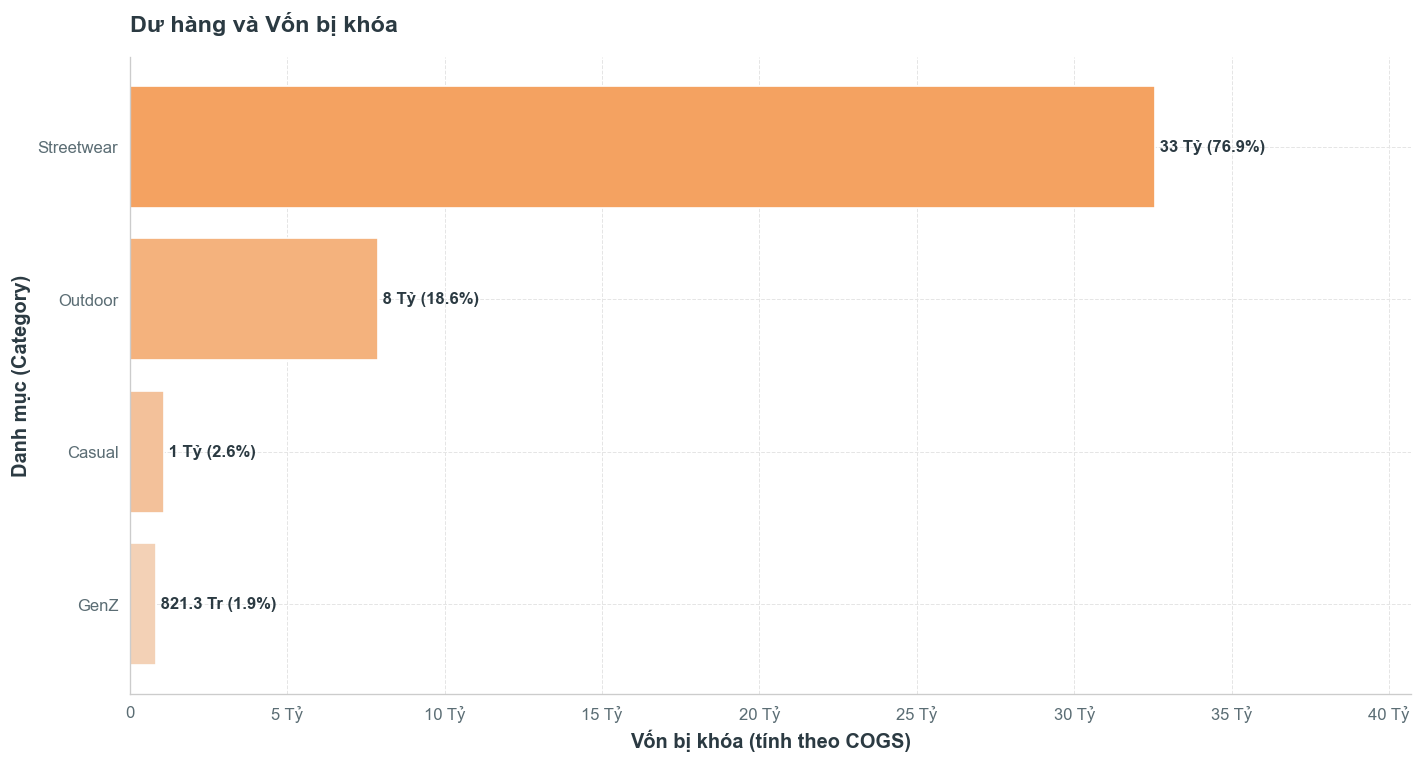

In [13]:
section_header(
    title='Phân tích Rủi ro: Dư hàng và Vốn bị khóa', 
    subtitle='Định lượng rủi ro kẹt vốn theo từng Category để điều chỉnh chiến lược nhập hàng'
)

# Cần truyền vào cả dfs['inventory'] và dfs['products'] để tính toán COGS
plot_overstock_capital_locked(inventory=dfs['inventory'], products=dfs['products'], save_fig=True)

**Streetwear: "Gót chân Achilles" của quản trị tồn kho**

Dữ liệu cho thấy các bản ghi dư hàng (overstock) đang khóa khoảng **42.339,4 triệu VNĐ** tính theo giá vốn. Riêng **Streetwear** chiếm tới **32.552,2 triệu VNĐ** — tương đương **76,9%** tổng vốn bị kẹt trong hàng tồn dư.

Kết hợp với phát hiện trước đó — Streetwear cũng là nhóm mất doanh thu lớn nhất do thiếu hàng (80,9% tổng lost revenue) — bức tranh trở nên rõ ràng: **Streetwear vừa là nơi chảy máu doanh thu vì thiếu hàng, vừa là nơi chôn vốn nhiều nhất vì dư hàng.** Nhìn bề mặt, điều này có vẻ mâu thuẫn, nhưng bản chất kinh doanh lại rất logic: đây là dấu hiệu kinh điển của **sai cơ cấu tồn kho** — những mã khách cần thì không đủ, trong khi những mã khách không mua lại chất đầy kho.

**Khuyến nghị hành động:**
Tuyệt đối không nhập thêm Streetwear một cách đại trà. Thay vào đó, cần phân loại từng SKU trong danh mục này thành hai nhóm rõ rệt:
- **Mã bán chạy, tần suất thiếu hàng cao** → ưu tiên bổ sung, rút ngắn chu kỳ đặt hàng.
- **Mã dư kho lâu ngày, vòng quay thấp** → giảm nhập hoặc dừng nhập, chủ động xả hàng qua bundle, markdown hoặc các chương trình khuyến mãi có mục tiêu.

**Kết luận điều hành:**
Vấn đề của Streetwear không phải là "cần nhiều hàng hơn", mà là **cần đúng hàng hơn**. Một chiến lược phân bổ lại cơ cấu tồn kho trong chính danh mục này sẽ giải phóng vốn và thu hồi doanh thu hiệu quả hơn nhiều so với việc đổ thêm tiền vào nhập hàng mới.

---
**Kịch bản thu hồi doanh thu**

Phần này giữ lại cách tính đơn giản ban đầu để tạo cảm giác về quy mô cơ hội. Tuy nhiên, cần nói rõ đây là **ước tính tuyến tính đơn giản**, không phải forecast.

Giảm thiếu hàng 20% không tự động đồng nghĩa thu hồi 20% doanh thu bị mất. Một phần khách hàng có thể đã mua sản phẩm khác, rời đi, hoặc nhu cầu đã mất vĩnh viễn. Vì vậy phần sau sẽ thêm scenario thực tế hơn với recovery rate và cannibalization.

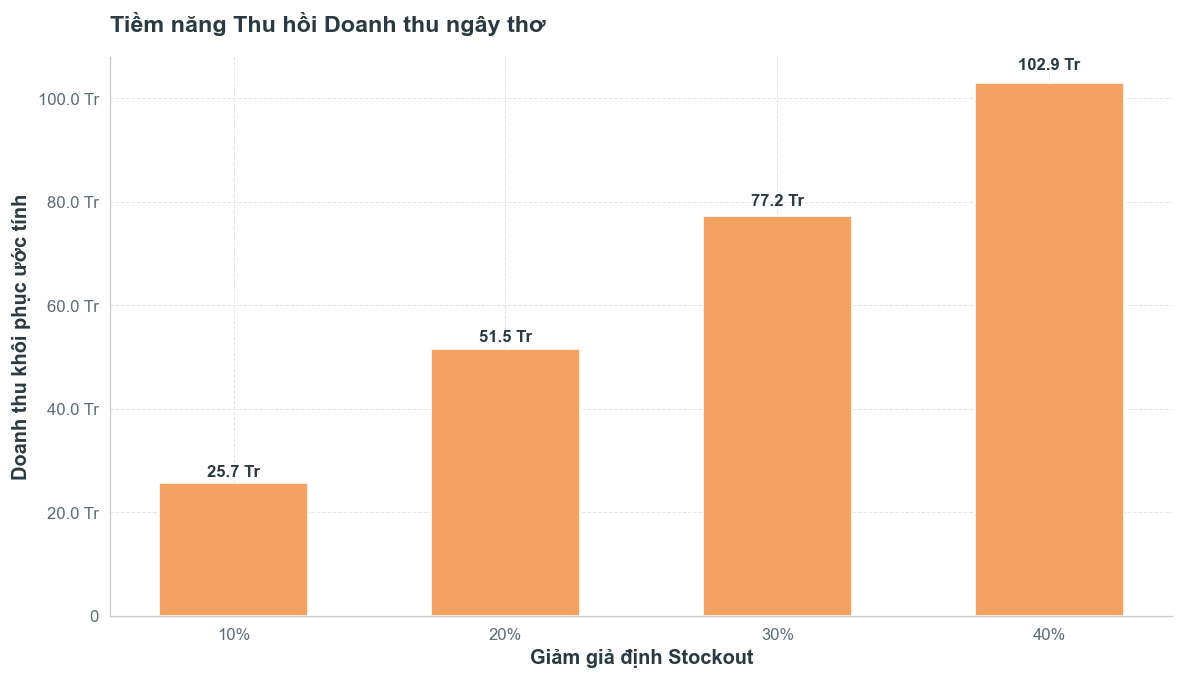

,Mức giảm stockout giả định,Recovered revenue estimate,Recovered gross margin estimate
0,0.1,2.573517e+07,5.000518e+06
1,0.2,5.147033e+07,1.000104e+07
2,0.3,7.720550e+07,1.500155e+07
3,0.4,1.029407e+08,2.000207e+07


In [14]:
section_header(
    title='Dự phóng Kinh doanh: Tiềm năng Thu hồi Doanh thu', 
    subtitle='Ước tính quy mô dòng tiền thu hồi được khi cải thiện năng lực cung ứng (Giảm Stockout)'
)

# Chạy mô hình giả định và lưu biểu đồ
recovery_scenario_df = plot_stockout_recovery_scenarios(
    inventory=dfs['inventory'], 
    products=dfs['products'], 
    save_fig=True
)

# Hiển thị bảng số liệu chi tiết để xem thêm phần Gross Margin
display(recovery_scenario_df)

**Cơ hội từ việc giảm thiếu hàng — nhưng cần tỉnh táo với chi phí đánh đổi**

Phân tích kịch bản cho thấy tiềm năng tài chính đáng kể: nếu giảm **20%** tỷ lệ thiếu hàng, doanh nghiệp có thể thu hồi khoảng **51,5 triệu VNĐ doanh thu** và **10,0 triệu VNĐ lợi nhuận gộp**. Ở kịch bản tham vọng hơn — giảm **40%** stockout — con số doanh thu phục hồi ước tính lên tới **102,9 triệu VNĐ**.

Tuy nhiên, cần tránh một cái bẫy tư duy phổ biến: **giảm thiếu hàng bằng mọi giá không đồng nghĩa với tăng lợi nhuận.** Nếu để kéo tỷ lệ stockout xuống mà doanh nghiệp phải nhập thêm quá nhiều hàng, chi phí lưu kho đội lên hoặc tạo ra làn sóng dư hàng mới, thì lợi nhuận thực tế thu về có thể bị xói mòn hoàn toàn — thậm chí âm.

**Khuyến nghị hành động:**
Triển khai theo lộ trình thử nghiệm — không mở rộng ồ ạt:
1. **Pilot ban đầu với kịch bản giảm 20% stockout**, tập trung vào nhóm sản phẩm ưu tiên đã xác định (Streetwear — nơi vừa có lost revenue cao nhất, vừa dư địa cải thiện cơ cấu tồn kho rõ nhất).
2. **Đo lường thực tế** sau pilot: so sánh phần lợi nhuận gộp phục hồi được với chi phí tồn kho phát sinh thêm. Chỉ mở rộng lên kịch bản 40% (hoặc ra các danh mục khác) nếu bài toán lợi ích - chi phí xác nhận hiệu quả dương.

**Kết luận điều hành:**
**Base case khả thi nhất là giảm 20% stockout, mang lại upside khoảng 51,5 triệu VNĐ doanh thu và 10,0 triệu VNĐ lợi nhuận gộp.** Đây là con số đủ hấp dẫn để chạy pilot ngay, nhưng việc mở rộng chỉ nên được phê duyệt khi chứng minh được rằng lợi nhuận phục hồi lớn hơn chi phí tồn kho tăng thêm. Nói ngắn gọn: **đừng đổi vấn đề thiếu hàng lấy vấn đề dư hàng.**

### **Cross-table Checks: Promotion, Traffic, Returns**

Phần này mở rộng góc nhìn phân tích bằng cách kiểm tra mối liên hệ giữa các yếu tố vận hành bên ngoài bảng tồn kho — cụ thể là khuyến mãi, lưu lượng truy cập và tỷ lệ hoàn trả — với các chỉ số stockout và overstock. Mục tiêu không phải chứng minh quan hệ nhân quả tuyệt đối, mà là xác định các tín hiệu tương quan đủ mạnh để định hướng hành động. Ba câu hỏi được đặt ra: liệu tháng có promotion có làm tăng stockout hoặc lost revenue không; liệu tháng traffic cao có trùng với lost revenue cao không; và liệu hàng dư có xuất phát từ tỷ lệ hoàn trả cao không.

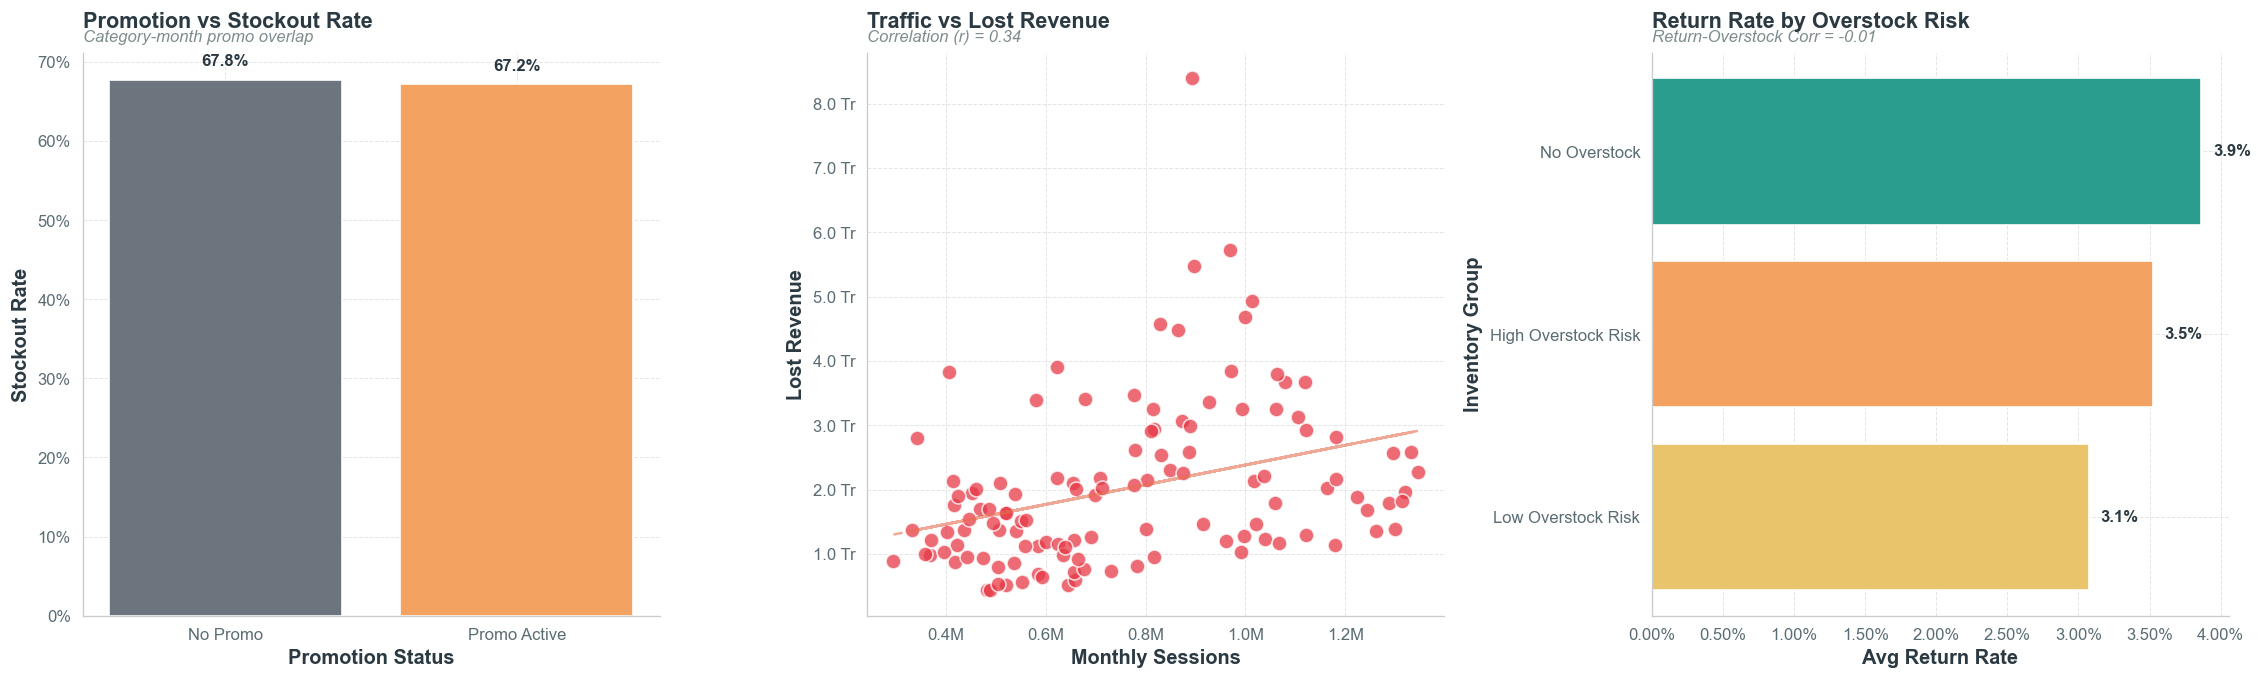

--- Tổng hợp Insight Cross-table ---


,Check,Main metric,Business read
0,Promotion overlap,Promo-active stockout: 67.2%,Use to check campaign inventory readiness.
1,Web traffic overlap,Traffic-lost revenue corr: 0.34,Market-level signal only; traffic is not SKU-l...
2,Returns vs overstock,Return-overstock corr: -0.01,Low correlation means returns are unlikely to ...


In [15]:
section_header(
    title="Cross-table Checks: Promotion, Traffic, Returns",
    subtitle="Kiểm tra mối liên hệ nhân quả tiềm năng giữa các yếu tố vận hành (Promo, Traffic, Returns) đối với Tồn kho."
)

inv_lost = estimate_stockout_impact(dfs['inventory'], dfs['products'])
plot_cross_table_diagnostics(dfs=dfs, inv_lost=inv_lost, save_fig=True)

#### 1. Tháng có Promotion có làm tăng Stockout hoặc Lost Revenue không?

Dữ liệu cho thấy các chiến dịch khuyến mãi **không làm tăng tần suất đứt hàng** — tỷ lệ stockout dao động ngang nhau ở mức 67,7% (không promo) và 67,2% (có promo), cho thấy khâu chuẩn bị hàng hóa cho các chiến dịch cơ bản là có tính toán trước. Tuy nhiên, điểm đáng lo ngại nằm ở quy mô thiệt hại: trong các tháng có chạy promo, tổng doanh thu bị lỡ mất do hết hàng **tăng vọt gấp gần 4 lần** — từ ~55 triệu lên ~202 triệu VNĐ. Điều này cho thấy tuy tần suất đứt hàng không đổi, nhưng vì lượng cầu trong kỳ promo lớn hơn nhiều, mỗi lần cháy hàng gây thiệt hại chi phí cơ hội nặng nề hơn so với ngày thường. Cơ chế phân bổ tồn kho đệm (safety stock) dày hơn riêng cho các sản phẩm chạy promo là điều cần thiết.

#### 2. Tháng Traffic cao có trùng với Lost Revenue cao không?

Hệ số tương quan giữa số sessions và lost revenue đạt **0,3406** — mức tương quan thuận trung bình, cho thấy khi traffic đổ về nhiều, rủi ro mất doanh thu do hết hàng cũng tăng theo. Điều này củng cố thêm nhận định từ phân tích trước: vấn đề không nằm ở việc vận hành chuỗi cung ứng kém đi, mà ở năng lực tồn kho hiện tại chưa đủ sức đáp ứng các đợt tăng vọt traffic từ các kênh marketing.

#### 3. Hàng dư có đến từ việc khách hoàn trả nhiều không?

Đây là một phát hiện mang tính phủ định có giá trị cao. Tỷ lệ hoàn trả ở nhóm không dư hàng (3,86%) và nhóm dư hàng rủi ro cao (3,52%) gần như bằng nhau, với hệ số tương quan giữa return rate và overstock rate chỉ ở mức **-0,0088** — gần bằng không. Dữ liệu này là bằng chứng rõ ràng rằng **hành vi hoàn trả của khách hàng không phải nguyên nhân gây ra tồn kho dư thừa.** Gốc rễ của vấn đề overstock nằm ở khâu dự báo thu mua đã nhập về số lượng vượt quá lực hấp thụ thực tế của thị trường ngay từ đầu.

---

## 5. Khuyến mãi

Phần này phân tích tác động của khuyến mãi lên biên lợi nhuận, so sánh margin giữa các loại khuyến mãi (percentage vs fixed), và kiểm chứng xem khuyến mãi có giúp tăng doanh số hay chỉ làm giảm lợi nhuận.

Như đã đề cập, 38,7% tổng lượng đơn hàng đang phụ thuộc vào các chương trình khuyến mãi — một tỷ lệ rất đáng kể. Tuy nhiên, thay vì thúc đẩy tăng trưởng lợi nhuận, các chương trình này đang trở thành gánh nặng tài chính cho doanh nghiệp.

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:708: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(_margin_percent).rename('margin').reset_index()
/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:715: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(_margin_percent).reset_index(name='margin')


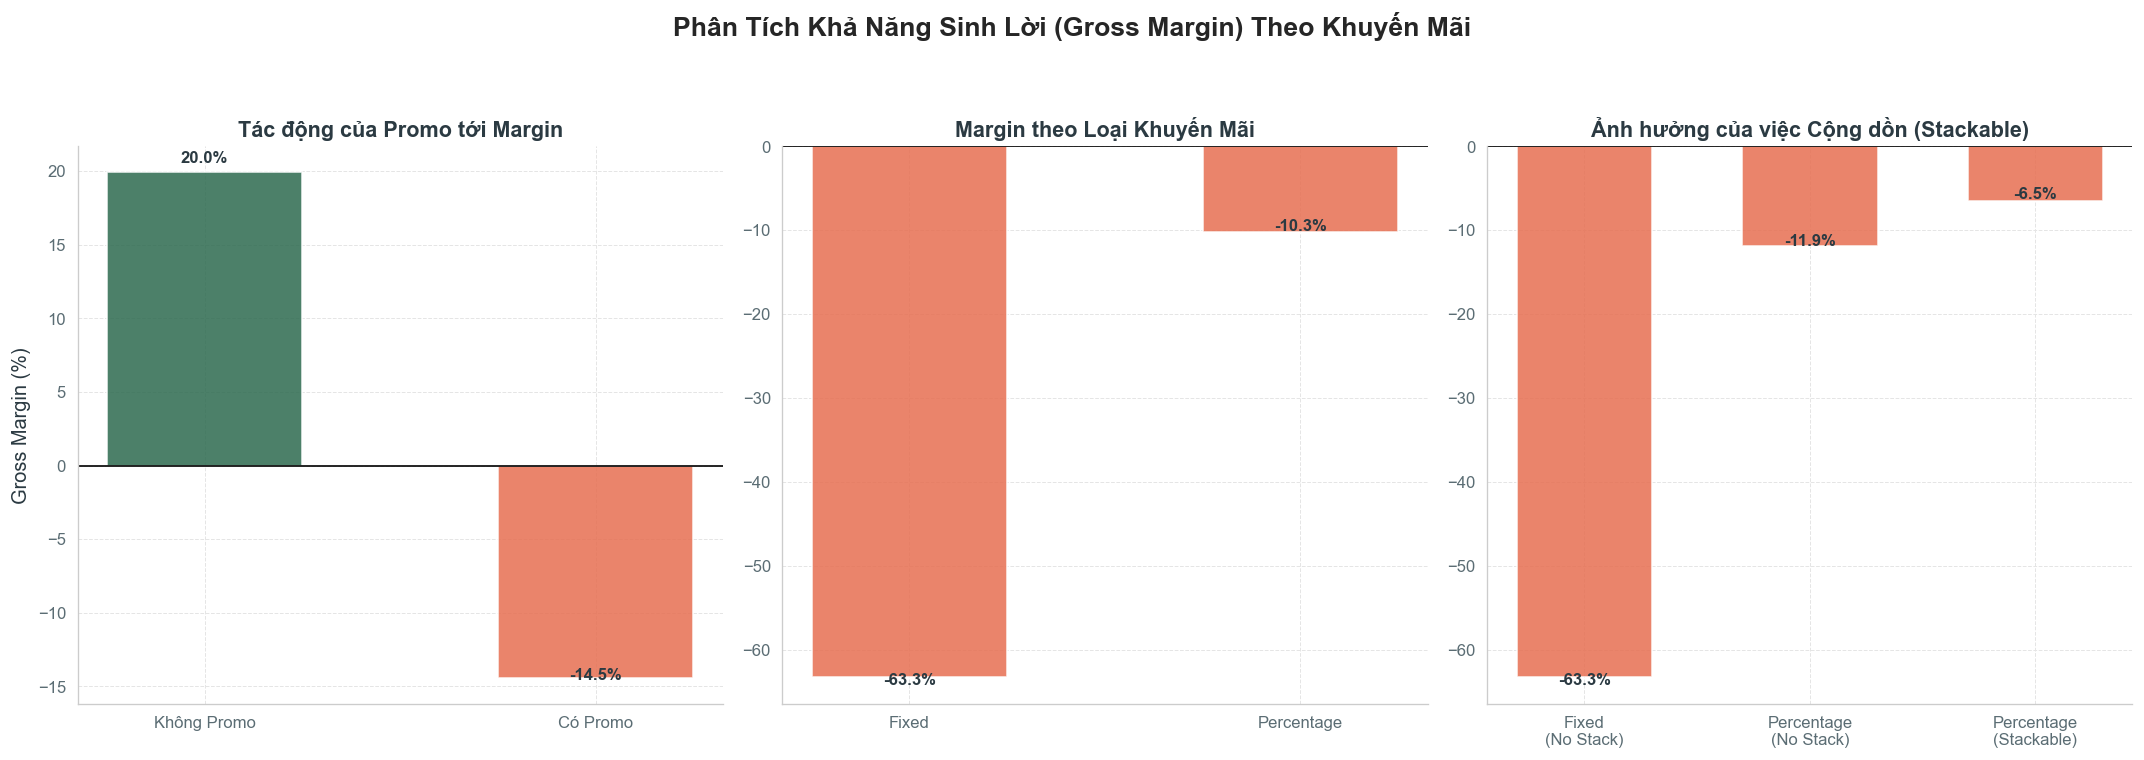

In [16]:
section_header('Phân tích khuyến mãi', 'So sánh biên lợi nhuận giữa đơn hàng có và không có khuyến mãi')
promo_summary = compute_promotion_margins(master_df)
plot_promotion_margins_analysis(promo_summary)

**Khuyến mãi đang bào mòn lợi nhuận, không tạo ra giá trị gia tăng**

Số liệu cho thấy một thực tế đáng báo động: khi không áp dụng khuyến mãi, doanh nghiệp duy trì biên lợi nhuận gộp ổn định ở mức **20,0%**. Nhưng ngay khi có mã khuyến mãi xen vào, biên lợi nhuận lao dốc không phanh xuống mức âm **-14,5%**. Nói cách khác, doanh nghiệp đang **chịu lỗ để khách hàng mua sản phẩm của mình** — một mô hình không bền vững về bản chất.

**Fixed discount — "Thủ phạm chính" tàn phá lợi nhuận**

Khi bóc tách theo loại khuyến mãi, bức tranh càng trở nên nghiêm trọng:
- Mã giảm theo số tiền cố định (**fixed**) đẩy Gross Margin xuống đáy **-63,3%** — mức lỗ thảm họa.
- Mã giảm theo phần trăm (**percentage**) cũng ghi nhận mức âm **-10,3%**.

Con số -63,3% ở nhóm fixed cho thấy một bất cập nghiêm trọng trong thiết lập điều kiện áp dụng: nhiều mã giảm cố định được dùng cho các đơn hàng có giá trị quá nhỏ, khiến doanh thu thu về thậm chí không đủ bù đắp giá vốn hàng bán.

**Ngay trong nhóm percentage, cấu hình cũng đang sai**

Một chi tiết đáng chú ý khác: các mã percentage **không cho phép cộng dồn (No Stack)** ghi nhận mức âm sâu hơn (**-11,9%**) so với các mã được phép cộng dồn (**Stackable**, ở mức -6,5%). Điều này cho thấy tỷ lệ giảm giá (discount_value) thiết lập cho các mã đơn lẻ đang bị đẩy lên **quá cao so với biên độ lợi nhuận gộp thực tế** của sản phẩm. Nói cách khác, doanh nghiệp đang "over-discount" ngay từ mã đầu tiên, chưa cần cộng dồn đã lỗ.

**Đề xuất hành động:**

1. **Tạm dừng và Audit toàn bộ mã Fixed ngay lập tức.** Rà soát cột `min_order_value` trong `promotions.csv`. Mọi mã giảm cố định phải được neo với điều kiện giá trị đơn hàng tối thiểu đủ lớn để bảo vệ điểm hòa vốn. Những mã không đáp ứng cần tạm ngưng cho đến khi điều chỉnh lại.

2. **Chuyển đổi chiến lược khuyến mãi:**
   - Dịch chuyển dần sang mô hình **Tiered Discount** (mua càng nhiều, giảm càng sâu) — vừa khuyến khích tăng giá trị giỏ hàng, vừa kiểm soát được biên lợi nhuận.
   - Với mã percentage, áp dụng **trần giảm giá tối đa (Capped Discount)** để ngăn việc lợi nhuận bị ăn mòn mất kiểm soát khi giá trị đơn hàng lớn.

**Kết luận điều hành:**

Với 38,7% đơn hàng đang nằm trong vùng khuyến mãi, việc tiếp tục vận hành các chương trình như hiện tại đồng nghĩa với việc **càng bán nhiều, càng lỗ sâu**. Ưu tiên số một lúc này không phải là tăng doanh thu bằng khuyến mãi, mà là **thiết kế lại cơ chế khuyến mãi để mỗi đơn hàng sinh lời thay vì hủy hoại lợi nhuận**. Khởi đầu bằng việc audit toàn bộ mã fixed và thiết lập trần giảm giá cho nhóm percentage.

### **Phân tích chuyên sâu về Khuyến mãi (Promotion Diagnostics)**

Để đánh giá hiệu quả thực sự của các chiến dịch "đốt tiền" marketing, chúng ta cần bóc tách dữ liệu ở góc độ biên lợi nhuận và hành vi mua sắm của khách hàng. Phân tích dưới đây sẽ tập trung giải quyết các câu hỏi cốt lõi:

**1. Stackable vs Single Promo:** Việc cho phép khách hàng lồng ghép nhiều mã giảm giá cùng lúc (Stackable) đang tối ưu volume hay đang âm thầm "ăn lẹm" vào Biên lợi nhuận (Margin)?

**2. Promotion Channel ROI:** Kênh phân phối mã giảm giá nào mang lại Lợi nhuận (ROI) cao nhất so với chi phí giảm giá đã bỏ ra?

**3. Hiệu ứng Vay mượn tương lai (Post-promotion Dip):** Doanh thu trong chiến dịch có thực sự tăng trưởng (Lift) hay chỉ đang kéo nhu cầu từ tương lai về hiện tại, dẫn đến một cú sập doanh thu (Dip) ngay sau đó?

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:2469: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stack_perf, x='promo_type', y='margin_pct', ax=ax, palette=[PALETTE['neutral'], PALETTE['primary'], PALETTE['danger']])


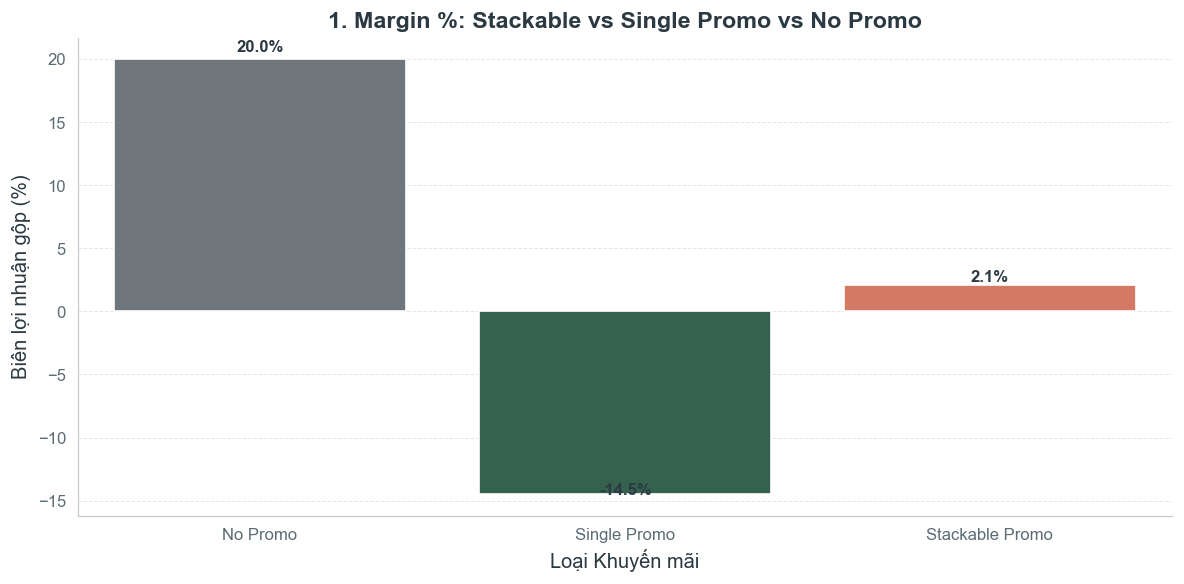

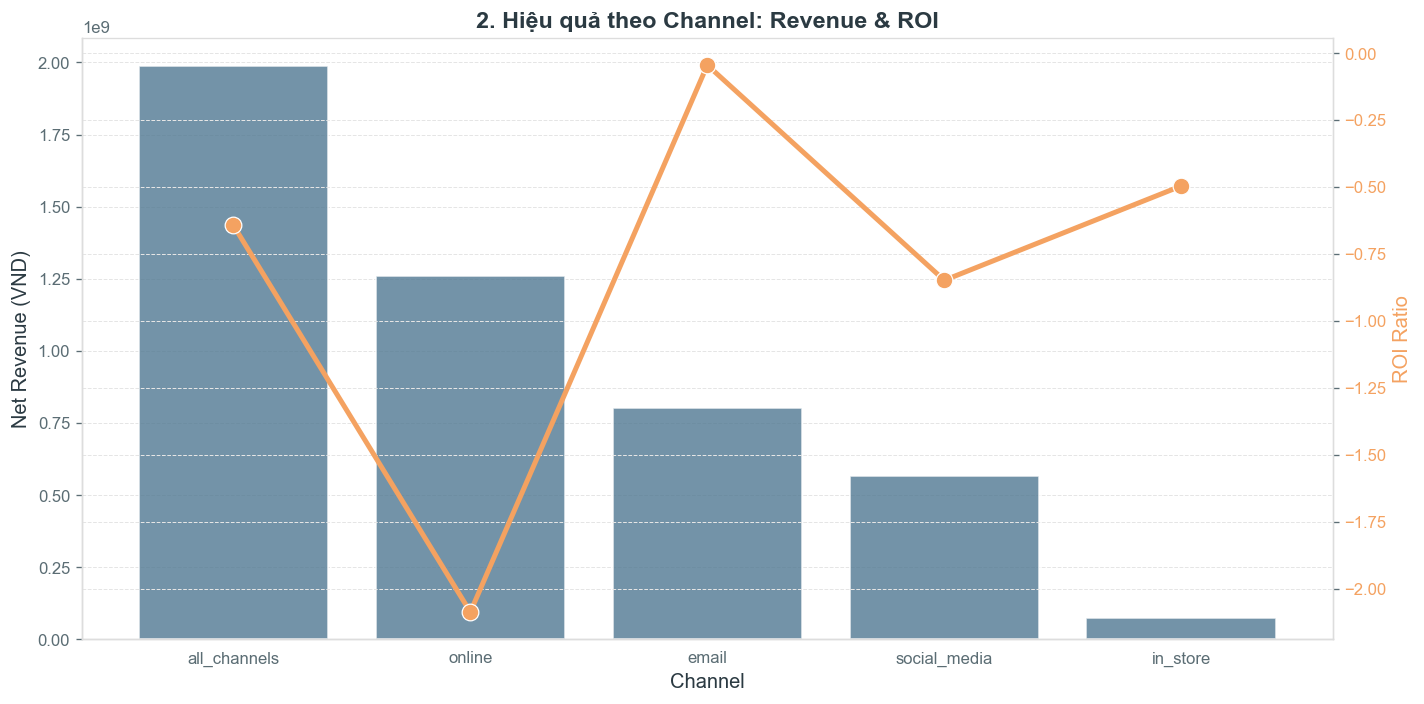

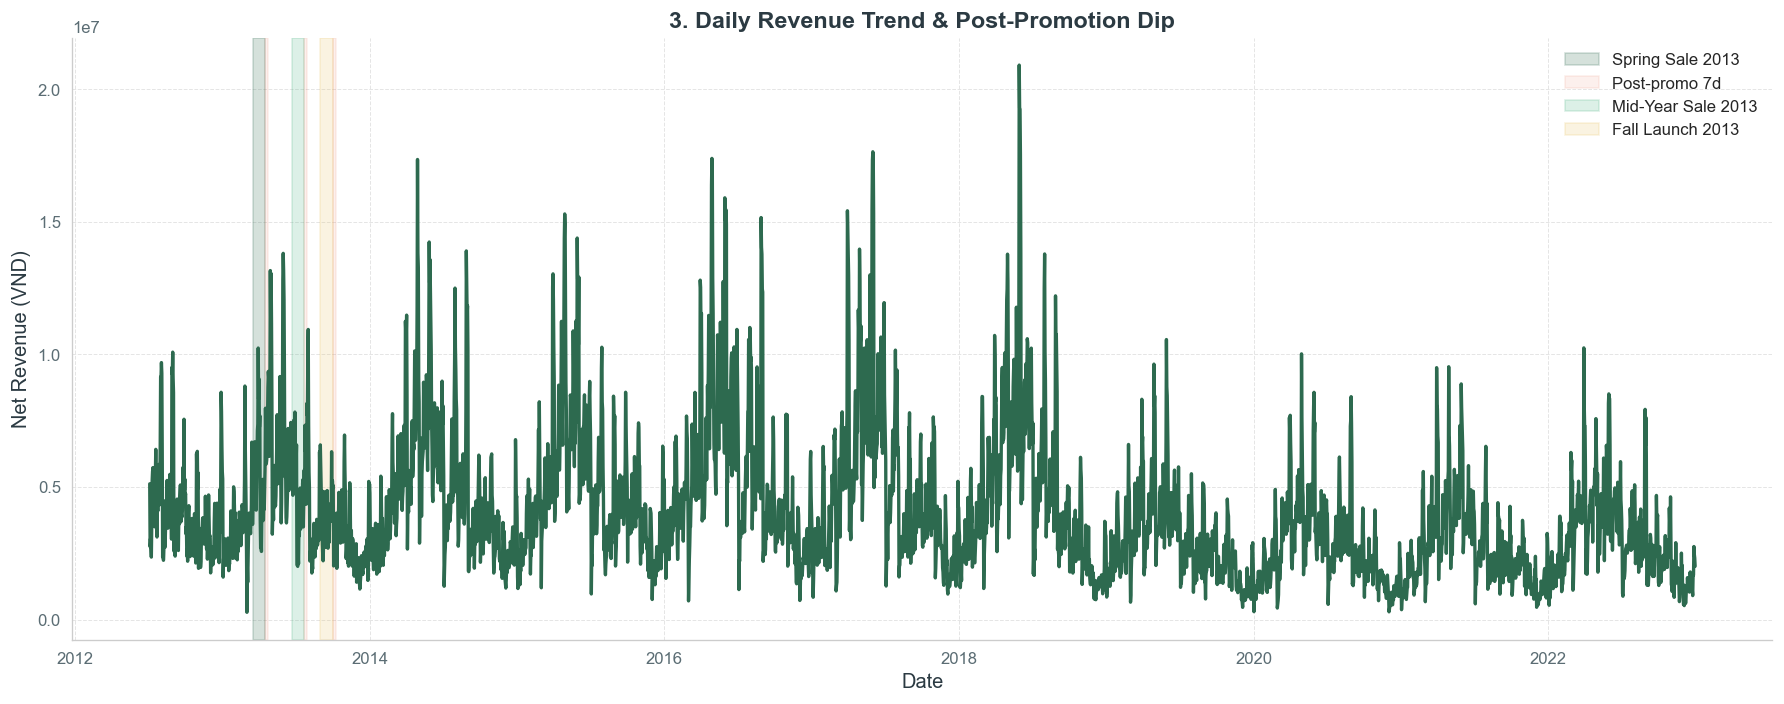

In [17]:
from src.eda_utils import plot_promotion_deep_dive

plot_promotion_deep_dive(dfs)


**Sự thật đằng sau những chiến dịch "Đốt tiền"**

*Là một Pricing & Promotion Analyst, chúng ta không chỉ nhìn vào việc doanh thu tăng bao nhiêu trong ngày Sale, mà phải xem cái giá phải trả là gì (Margin). Thực tế dữ liệu hiện tại đang là một "Hồi chuông báo động đỏ" cho toàn bộ chiến lược Khuyến mãi.* 

**1. Khuyến mãi đơn lẻ (Single Promo) - "Hố đen" nuốt trọn lợi nhuận**

Trái với trực giác thông thường, biểu đồ cho thấy Biên lợi nhuận (Margin) của nhóm áp dụng 1 mã (Single Promo) đang rơi tự do xuống mức **Âm 14.5%**. Trong khi đó, nhóm lồng ghép nhiều mã (Stackable Promo) dù thấp nhưng vẫn giữ được Margin dương ở mức **2.1%** (so với mức 20.0% khỏe mạnh của ngày không sale). 

**Nguyên nhân cốt lõi** có thể do các mã Single đang giảm giá trực tiếp quá sâu mà không có rào cản bảo vệ. Ngược lại, để áp dụng được **Stackable**, khách hàng buộc phải nhồi thêm hàng vào **giỏ cho đủ điều kiện (Min Spend)**, vô tình gánh lại được phần nào lợi nhuận bị mất.

**2. Promotion Channel ROI - Đốt tiền nhưng lỗ toàn tập**

Phân tích Channel bóc trần một sự thật: **Toàn bộ các kênh chạy Khuyến mãi đều đang Lỗ (ROI < 0)**. Kênh `Online` mang về Doanh thu Top 2 nhưng lại là nơi "chảy máu" lợi nhuận nặng nhất (ROI = -2.00). Điểm sáng duy nhất là `Email Marketing` - tuy đóng góp doanh thu ít hơn nhưng lại có ROI tối ưu nhất (gần chạm mức 0 - tiệm cận hòa vốn). Việc ném tiền mù quáng vào các kênh diện rộng (Online) đang hủy hoại dòng tiền doanh nghiệp.

**3. Khủng hoảng Doanh thu: Không có cú "bật nhảy" (Lift) nào cả!**

Bảng phân tích Lượng Doanh Thu đã lật tẩy thất bại lớn nhất: Khuyến mãi không hề kích cầu. Thay vì tăng trưởng, doanh thu trung bình ngày Sale (3.6 Tr) lại **thấp hơn 23.3%** so với ngày thường (Baseline 4.6 Tr). Cú sốc này tiếp tục kéo dài vào 7 ngày sau Khuyến mãi (Dip giảm 16.2%). Điều này chứng tỏ các chương trình Sale đang thiết kế sai tệp khách hàng, chỉ thu hút được những đơn hàng giá trị siêu nhỏ và làm tê liệt nhu cầu mua sắm tự nhiên.

---
**Hành động Chiến lược (Actionable Prescriptive):**

- **Kiểm soát khẩn cấp Single Promo:** Dừng ngay lập tức các mã giảm giá sâu áp dụng trực tiếp. Bắt buộc thiết lập lại Rule Engine: Mọi Voucher đều phải đính kèm điều kiện *Giá trị Đơn hàng Tối thiểu (Min Order Value)* đủ lớn để cover mức Margin mong muốn.

- **Dịch chuyển ngân sách (Budget Shift):** Cắt giảm ngân sách phân phối Voucher trên các kênh `Online` chung chung. Chuyển nguồn lực đó sang `Email Marketing` để nhắm đúng tệp khách hàng trung thành (Loyalty) - những người sẵn sàng mua giá trị cao và ít làm tổn thương lợi nhuận nhất.


- **Tạm ngưng toàn bộ Khuyến mãi đại trà:** Doanh nghiệp đang bị "Promo Trap" (bẫy khuyến mãi) nhưng không sinh ra doanh thu. Cần có một giai đoạn đóng băng (Cooling period) tối thiểu 1 tháng để thanh lọc lại thị trường, kéo doanh thu tự nhiên (Baseline) phục hồi trở lại trước khi tung chiến dịch mới.


---

## 6. Phân tích Địa lý (Geographic Analysis)

Trước khi chuyển sang phân tích khách hàng ("Ai mua?"), chúng ta cần trả lời một câu hỏi quan trọng không kém: **"Bán Ở ĐÂU hiệu quả nhất?"**

Phân tích theo 3 khu vực (East, Central, West) sẽ giúp doanh nghiệp phân bổ nguồn lực một cách có chiến lược:

**1. Revenue & AOV theo Region:** Khu vực nào đóng góp doanh thu lớn nhất, khu vực nào có giá trị đơn hàng trung bình cao nhất?

**2. Return Rate theo Region:** Khu vực nào trả hàng nhiều nhất — có liên quan đến vấn đề logistics không?

**3. Lead Time theo Region:** Thời gian giao hàng có chênh lệch đáng kể giữa các khu vực không?

**4. Seasonal Pattern:** Xu hướng mùa vụ có khác nhau giữa các khu vực không — gợi ý cho việc phân bổ tồn kho theo mùa.

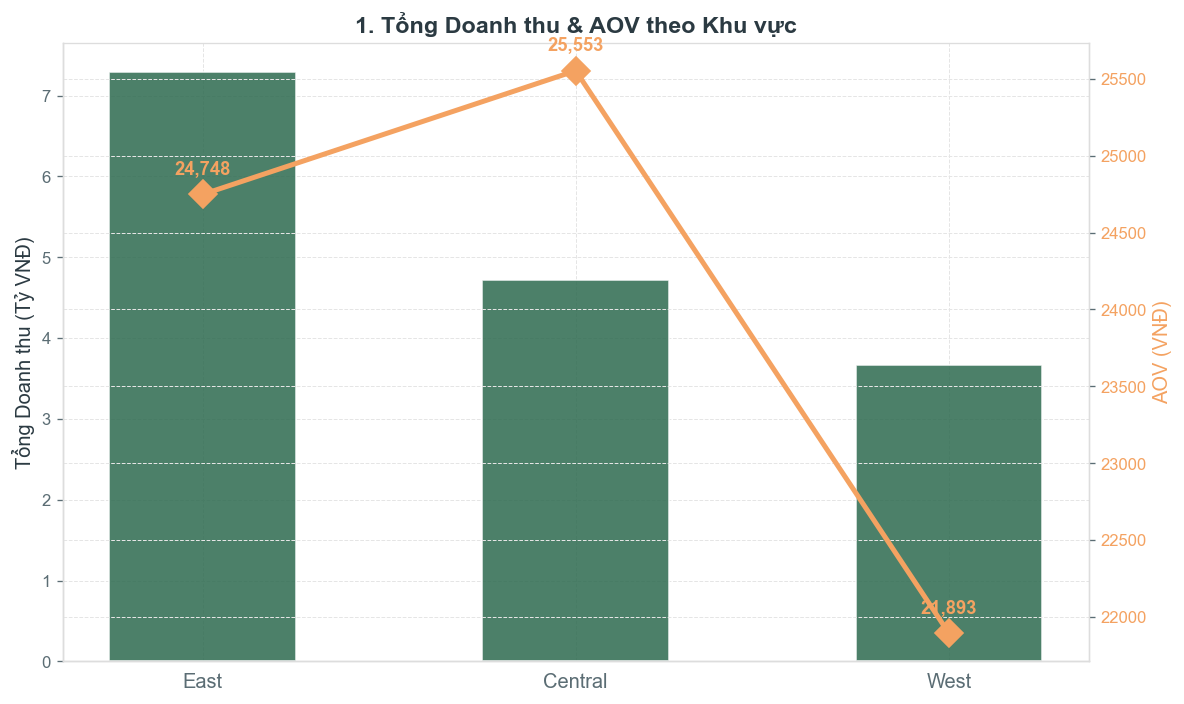

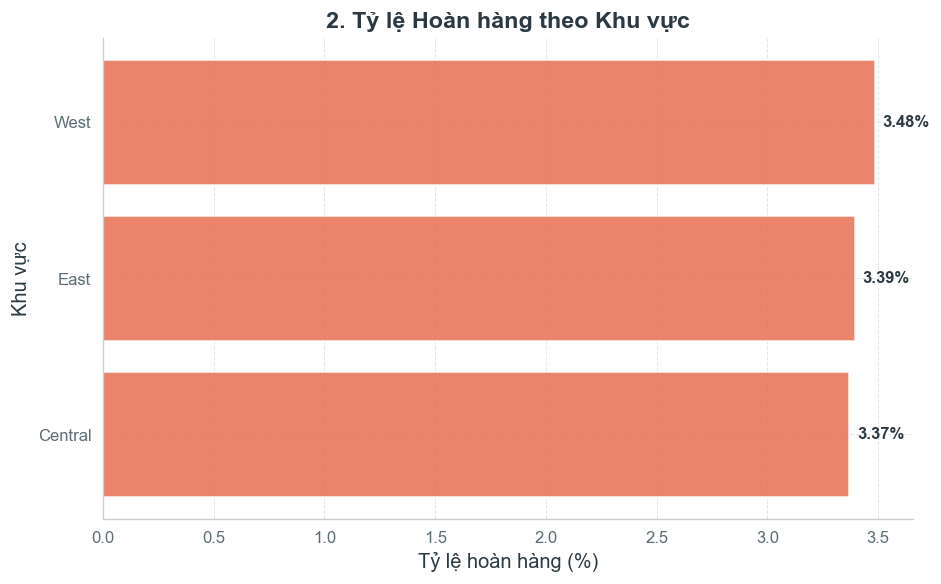

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:2988: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


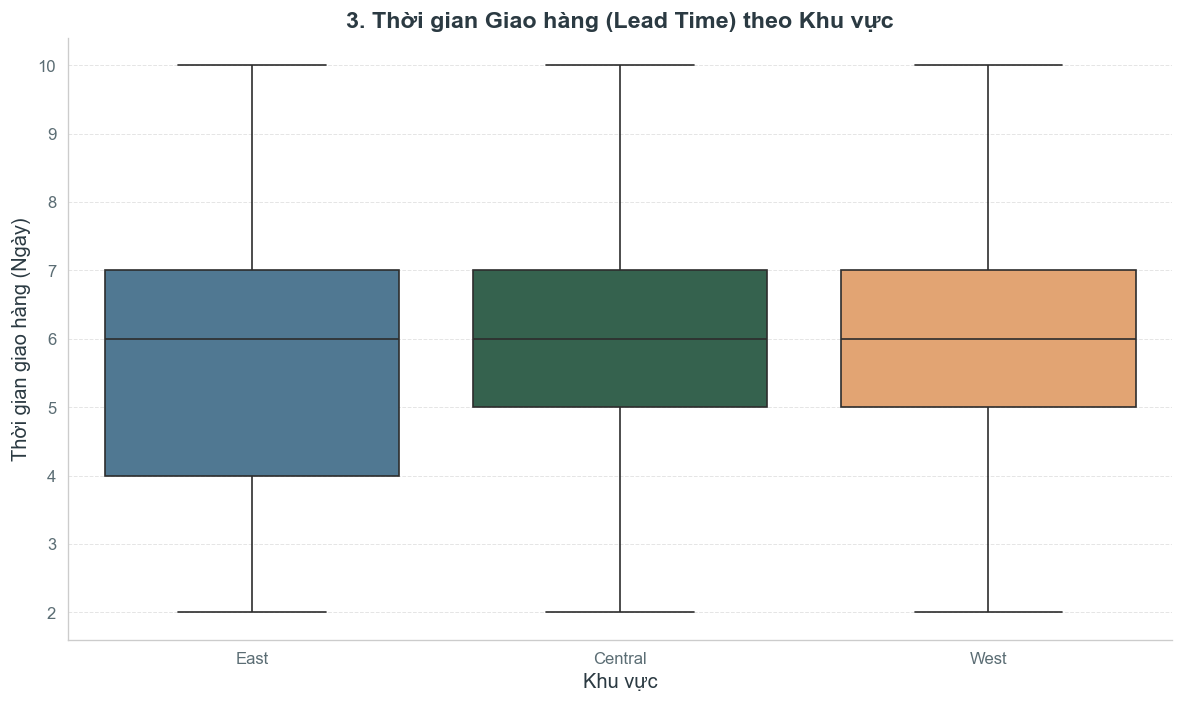

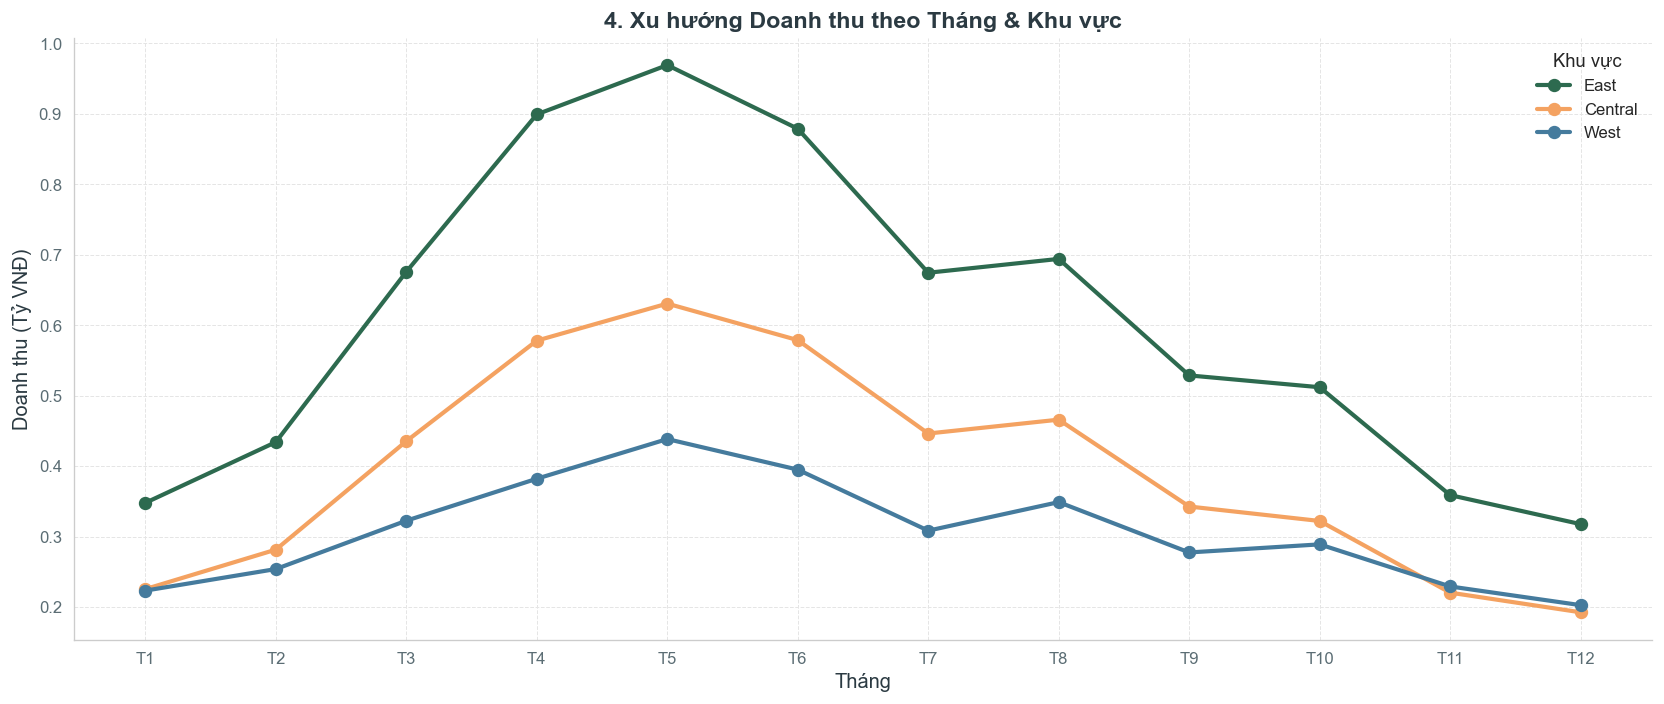

In [18]:
from src.eda_utils import plot_geographic_analysis

plot_geographic_analysis(dfs, master_df)


**"Bản đồ nhiệt" của Doanh thu và Logistics**

*Phân tích địa lý không chỉ cho chúng ta biết "Bán ở đâu", mà còn phác họa thói quen tiêu dùng và rủi ro chuỗi cung ứng trên từng lãnh thổ.*

**1. East (Khu vực phía Đông) là "Đầu tàu", Central (Trung tâm) là "Đại gia"**
Dữ liệu chỉ ra sự phân hóa rõ rệt về hiệu suất:

- **Khu vực East:** Đóng vai trò là đầu tàu doanh thu (đạt hơn 7 Tỷ VNĐ), vượt xa các khu vực còn lại. Đây là thị trường cốt lõi, có lượng đơn hàng khổng lồ.

- **Khu vực Central:** Tuy doanh thu chỉ đứng thứ hai (~4.7 Tỷ), nhưng lại sở hữu **AOV (Giá trị trung bình đơn) cao nhất hệ thống (25,553 VNĐ)**. Khách hàng ở đây tuy mua ít lần hơn nhưng mỗi lần "xuống tiền" lại mua những giỏ hàng giá trị rất cao. 

- **Khu vực West:** Đang là vùng trũng nhất — doanh thu thấp nhất, AOV bét bảng (21,893 VNĐ) nhưng lại có Tỷ lệ hoàn hàng (Return Rate) cao nhất (3.48%).

**2. Logistics đồng đều: Xóa bỏ nghi ngờ về "Năng lực giao vận cục bộ"**

Trực giác ban đầu có thể cho rằng: Khu vực nào giao hàng chậm hơn sẽ có Tỷ lệ hoàn hàng cao hơn. Tuy nhiên, biểu đồ Boxplot (Lead Time) đã bác bỏ giả thuyết này. Thời gian giao hàng (Median) ở cả 3 khu vực đều đóng băng ở mức **6 ngày**, với độ biến thiên (phân bố từ 2 đến 10 ngày) gần như giống hệt nhau. Điều này chứng minh năng lực chuỗi cung ứng của chúng ta rất đồng đều. Tỷ lệ hoàn hàng hơi nhỉnh hơn ở khu vực West (3.48%) không bắt nguồn từ lỗi của đơn vị vận chuyển (Logistics).

**3. Nghịch lý Mùa vụ: Đỉnh điểm mùa Hè, "Ngủ đông" cuối năm**

Biểu đồ Line Chart theo tháng vẽ ra một Pattern (Quy luật) nhất quán đến kỳ lạ ở cả 3 khu vực: Doanh thu lập đỉnh cao nhất vào **Tháng 5** (giao mùa Xuân - Hè) và tụt dốc không phanh về đáy vào **Tháng 11, Tháng 12**. 

Đây là một "nghịch lý" cực lớn trong ngành thời trang — thông thường cuối năm (Black Friday, Lễ hội, Mùa Đông) mới là đỉnh doanh thu do giá trị áo khoác/đồ lạnh thường cao. Việc doanh thu "lao dốc" vào cuối năm chứng tỏ **Bộ sưu tập Mùa Đông (Winter Collection) của chúng ta đang thất bại** hoặc doanh nghiệp đang cạn kiệt ngân sách Marketing vào các tháng cuối.

---
**Hành động Chiến lược:**

- **Chiến lược "Upsell" cho Central, "Volume" cho East:** Với khu vực Central (AOV cao), cần đẩy mạnh các combo sản phẩm đắt tiền, hàng Premium. Với khu vực East, tiếp tục tối ưu hóa quảng cáo để vét sạch tập khách hàng đại chúng.

- **Tạm thu hẹp thị trường West:** Cắt giảm ngân sách Acquisition (Tìm kiếm khách hàng mới) ở khu vực West. Đây là thị trường "khó nhằn" (AOV thấp, Hoàn hàng cao), nên chỉ duy trì tệp khách hàng cũ thay vì đốt tiền mở rộng.

- **Cứu vãn Doanh thu Mùa Đông:** Đội ngũ Phát triển Sản phẩm (R&D) và Merchandising cần mổ xẻ lại ngay danh mục hàng Thu-Đông. Cần có sự chuẩn bị nguồn lực (Stock, Marketing Budget) đẩy mạnh từ tháng 9, tháng 10 để bẻ gãy đà lao dốc hiện tại, không thể để thị trường "ngủ đông" trong mùa mua sắm lớn nhất năm.


---

## 7. Tỷ lệ giữ chân khách hàng

Phần này phân tích RFM (Recency, Frequency, Monetary), phân nhóm khách hàng, tỷ lệ một lần mua, khách hàng mới vs khách cũ, và tìm hiểu xu hướng churn & retention để xác định các nhóm khách cần chăm sóc đặc biệt.

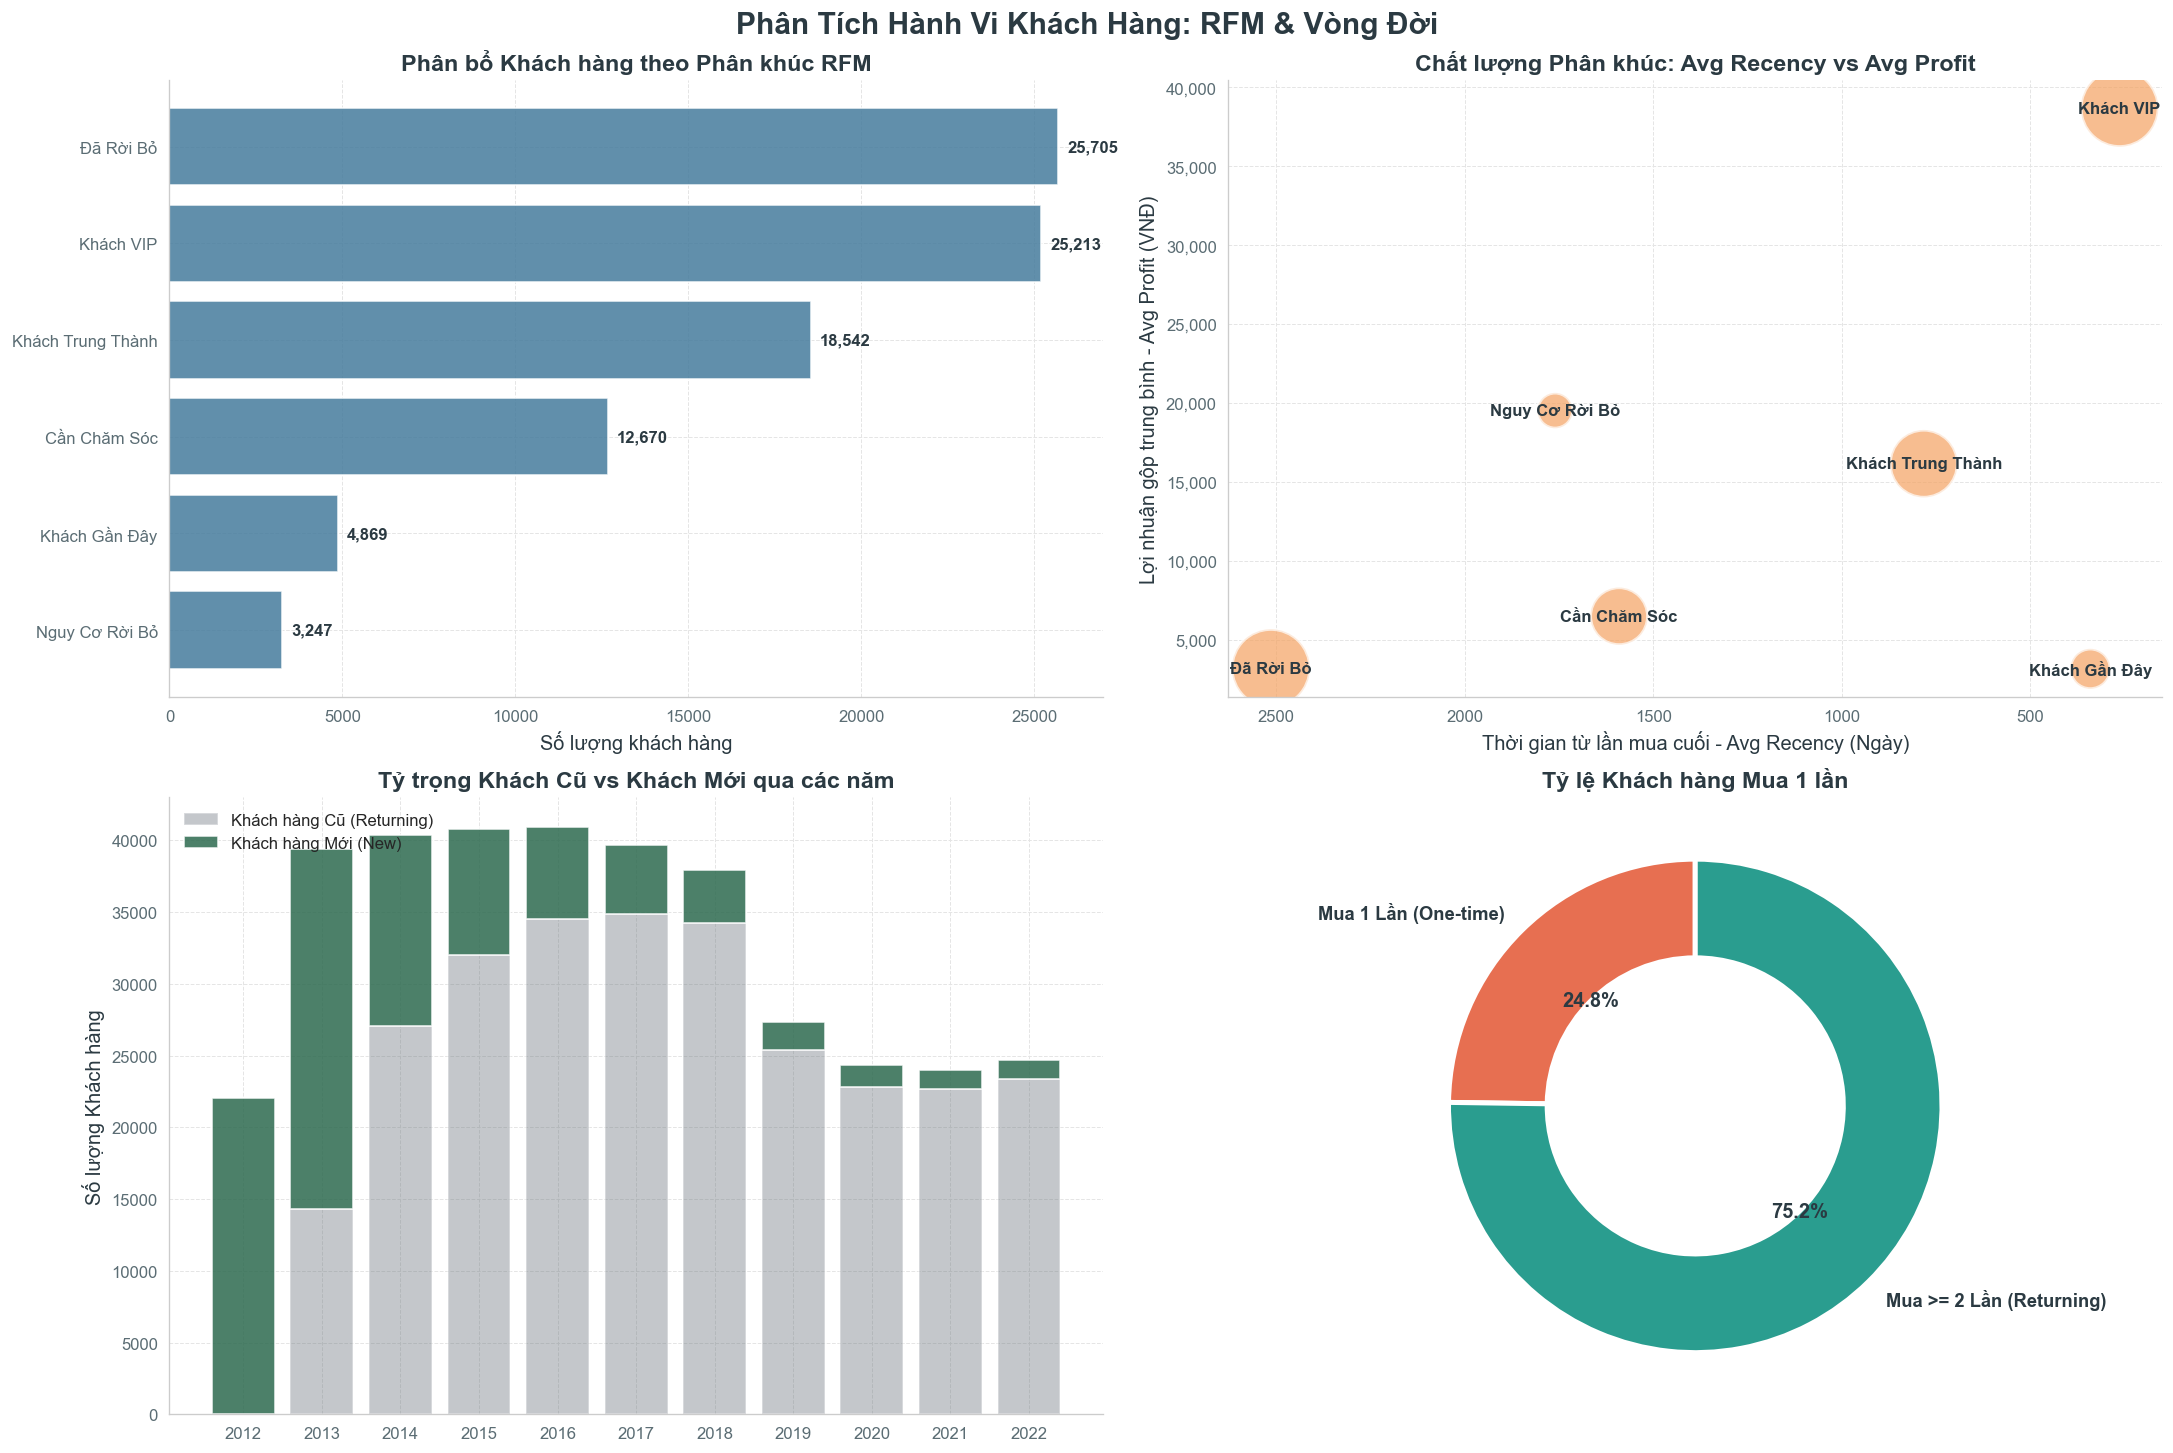

In [19]:
section_header(
    title='Phân tích khách hàng', 
    subtitle='RFM và tỷ lệ khách hàng 1 lần / khách mới - khách cũ'
)

# 1. Tính toán dữ liệu
customer_rfm = build_customer_rfm(master_df)
customer_lifecycle = compute_customer_lifecycle(master_df)

# 2. Thay thế toàn bộ print và display bằng hàm vẽ biểu đồ
plot_customer_behavior_dashboard(
    customer_rfm=customer_rfm, 
    customer_lifecycle=customer_lifecycle, 
    save_fig=True
)

**Bức tranh khách hàng:**

Dữ liệu hành vi khách hàng hé lộ một nghịch lý chiến lược: doanh nghiệp làm rất tốt việc giữ chân người cũ, nhưng đang thất bại trong việc thu hút người mới.

**Điểm sáng — Tỷ lệ giữ chân ấn tượng:**
Chỉ **24,8%** khách hàng rời đi sau lần mua đầu tiên, đồng nghĩa với việc **hơn 75% khách hàng quyết định quay lại**. Đây là một tỷ lệ giữ chân (Retention Rate) xuất sắc, cho thấy trải nghiệm sản phẩm và dịch vụ hậu mãi đang làm hài lòng phần lớn người mua. Nhóm **Khách hàng Vàng (Khach Vip)** với 25.213 người — đông thứ hai trong cơ cấu — đang là trụ cột tạo ra lượng lợi nhuận gộp khổng lồ, minh chứng cho giá trị của tệp khách trung thành.

**Điểm tối — Nguy cơ từ nhóm rời bỏ và sự sụt giảm khách mới:**
Tuy nhiên, hai tín hiệu cảnh báo không thể bỏ qua:
- Nhóm **Đã Rời Bỏ (Lost)** hiện chiếm tỷ trọng lớn nhất với **25.705 người** — thậm chí còn đông hơn cả nhóm Vip. Điều này đặt ra câu hỏi về việc liệu doanh nghiệp có đang dần đánh mất cả những khách hàng từng trung thành hay không.
- Nghiêm trọng hơn, biểu đồ cột chồng theo thời gian phơi bày một lỗ hổng chí mạng: **lượng Khách hàng Mới (New Customers) sụt giảm liên tục và chạm đáy trong giai đoạn 2019–2022**. Doanh nghiệp đang sống mòn dựa trên tệp khách cũ, trong khi nguồn thu thập khách mới — "dòng máu tươi" cho tăng trưởng dài hạn — đang teo tóp nghiêm trọng.

**Hàm ý chiến lược:**
Thành công trong giữ chân khách hàng là nền tảng quý giá, nhưng không thể bù đắp mãi cho sự sụt giảm khách mới. Nếu xu hướng này tiếp diễn, doanh nghiệp sẽ đối mặt với nguy cơ co hẹp dần tệp khách hàng khi nhóm Lost tiếp tục phình to mà không có lực lượng New Customers bổ sung.

**Khuyến nghị hành động:**
1. **Tái phân bổ ngân sách Marketing:** Chuyển một phần ngân sách từ hoạt động giữ chân (retention) sang thu hút khách mới (acquisition) — nơi đang bị bỏ ngỏ.
2. **Làm mới thương hiệu cho tệp trẻ:** Đặc biệt chú trọng phân khúc **GenZ** — nhóm đã được xác định ở các phân tích trước là có tỷ lệ trả hàng cao nhưng cũng là tương lai của thị trường. Cần chiến lược truyền thông và sản phẩm riêng để kéo dòng khách hàng trẻ quay trở lại hệ thống.
3. **Phân tích nhóm Lost:** Tìm hiểu nguyên nhân rời bỏ của nhóm 25.705 khách hàng này — nếu là do các vấn đề đã xác định (sai size, hàng lỗi, khuyến mãi gây lỗ,...), việc khắc phục có thể cứu vãn một phần đáng kể.

**Kết luận điều hành:**
Doanh nghiệp đang có một tệp khách trung thành đáng mơ ước — nhưng đây cũng chính là điểm mù khiến sự suy giảm khách mới bị bỏ qua quá lâu. **Giữ chân khách cũ là phòng thủ, thu hút khách mới là tấn công. Một doanh nghiệp không thể chỉ phòng thủ mãi mà không tấn công.** Đã đến lúc tái khởi động cỗ máy acquisition trước khi tệp khách hàng bị thu hẹp đến mức không thể đảo ngược.

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:2081: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


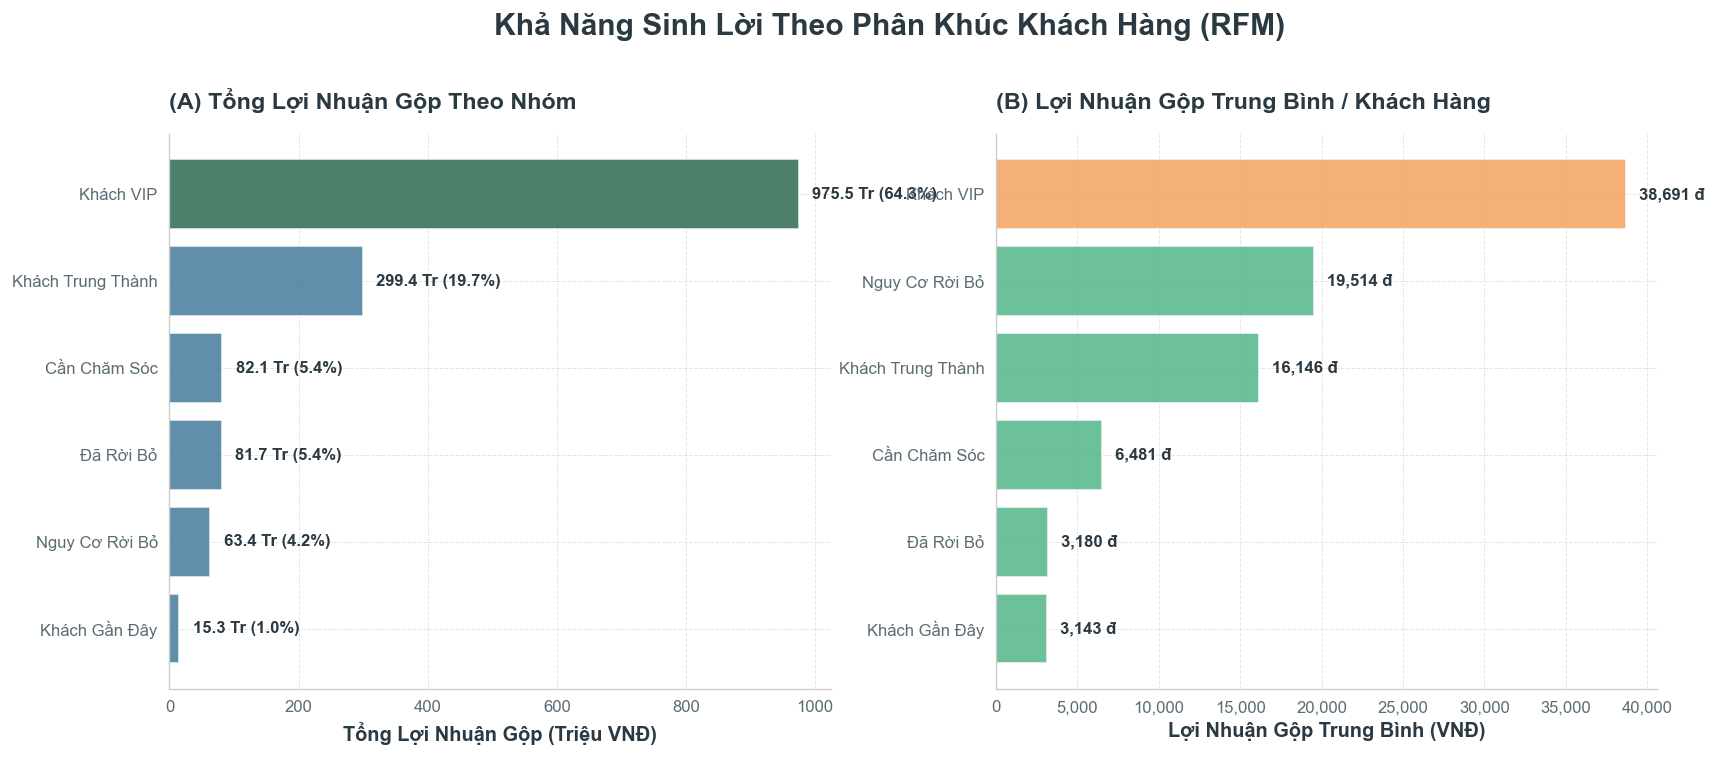

In [20]:
plot_segment_profitability(customer_rfm)

**Quy luật Pareto trong lợi nhuận khách hàng — 84% lợi nhuận đến từ chỉ 2 nhóm khách**

Dữ liệu xác nhận nguyên lý 80/20 một cách ấn tượng:

- Nhóm **Khách VIP** một mình tạo ra **975,5 triệu VNĐ**, chiếm **64,3%** tổng lợi nhuận.
- Nhóm **Khách Thân Thiết** đóng góp thêm **299,4 triệu VNĐ**, tương đương **19,7%**.

Chỉ riêng hai nhóm cốt lõi này đã mang về **84% tổng lợi nhuận toàn công ty**. Con số này gửi đi một thông điệp rất rõ ràng: thay vì dàn trải ngân sách cho các chiến dịch mass-marketing đại chúng, tập trung nguồn lực vào việc chăm sóc và giữ chân tệp khách hàng giá trị cao sẽ mang lại **ROI vượt trội hơn rất nhiều**.




**Hành trình sinh lời của khách hàng — "Lợi nhuận không đến ngay từ lần mua đầu tiên"**

Ở đầu bên kia bảng xếp hạng, nhóm **Khách Gần Đây** (gần năm cuối của bộ dữ liệu) đứng cuối trên mọi chỉ số:

- Tổng lợi nhuận chỉ chiếm vỏn vẹn **1,0%**.
- Lợi nhuận trung bình khiêm tốn ở mức **3.143 VNĐ/người**.

Điều này không có gì bất thường. Ở những giao dịch đầu tiên, khách hàng chưa sinh lời nhiều vì doanh thu phải "gánh" toàn bộ chi phí thu hút (marketing, khuyến mãi chào mừng,...). Nhưng chính khoảng cách lợi nhuận khổng lồ giữa nhóm Khách Gần Đây và nhóm Khách VIP đã làm sáng tỏ một chân lý kinh doanh quan trọng:

> **"Lợi nhuận không bùng nổ ở lần mua đầu tiên. Nó chỉ thực sự cất cánh khi doanh nghiệp thành công trong việc nuôi dưỡng và chuyển đổi một Khách Gần Đây thành Khách Thân Thiết, rồi tiến lên Khách VIP."**

Nói cách khác, nhiệm vụ sống còn không chỉ là thu hút khách mới — mà là thiết kế một **hành trình hậu mua hàng** đủ tốt để kéo họ từ nhóm sinh lời thấp lên nhóm sinh lời cao. Mỗi khách hàng rời đi trước khi đạt đến cấp Thân Thiết hay VIP là một khoản đầu tư thu hút chưa kịp thu hồi.

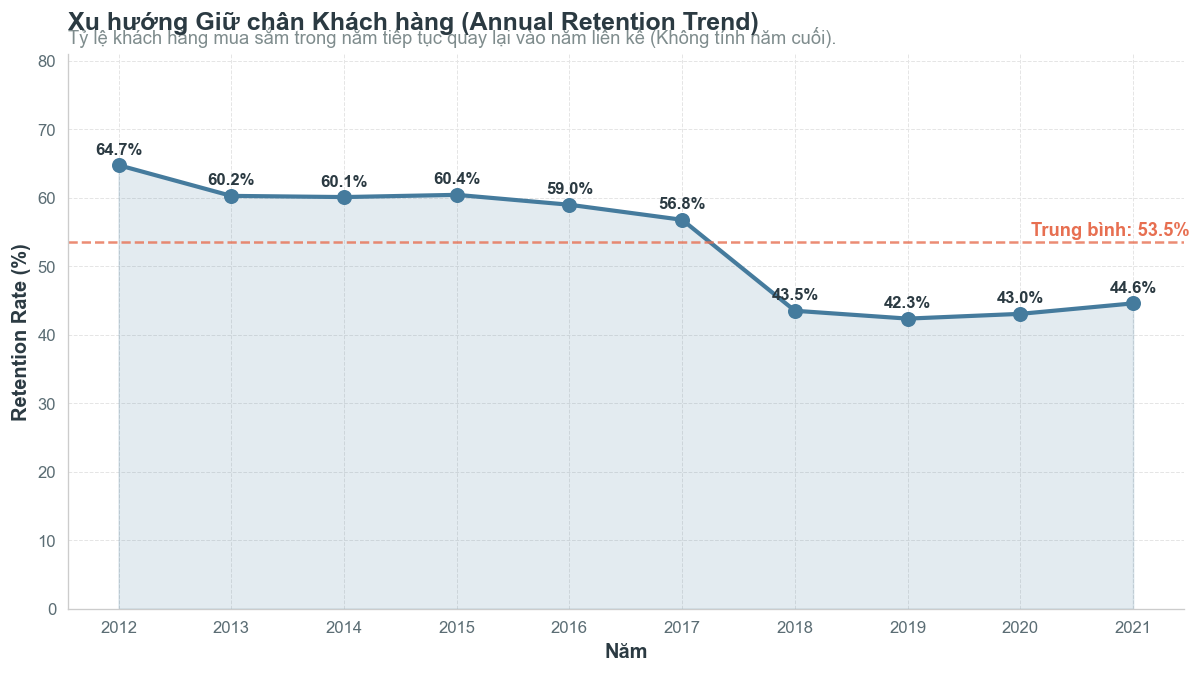

In [21]:
section_header(
    title='Phân tích Rời bỏ & Giữ chân (Churn & Retention)', 
    subtitle='Đánh giá sự ổn định của tập khách hàng và khả năng quay lại mua sắm qua các năm'
)

# Chạy hàm vẽ biểu đồ
plot_annual_retention_trend(master_df=master_df, save_fig=True)

**Một cú "gãy gập" cấu trúc — không chỉ là suy giảm tự nhiên**

Biểu đồ tỷ lệ giữ chân khách hàng (Retention Rate) theo thời gian phơi bày một thực tế đáng báo động. Đây không phải là sự suy giảm từ từ theo đà tăng trưởng, mà là một **cú gãy gập cấu trúc rõ rệt**:

- Trong suốt 4 năm liên tiếp, doanh nghiệp duy trì tỷ lệ giữ chân rất ấn tượng — luôn ở mức **trên 60%**.
- Nhưng chỉ trong vòng **một năm** (từ 2017 sang 2018), tỷ lệ này bốc hơi gần **14 điểm phần trăm**.
- Tệ hơn, kể từ đó đến nay, tỷ lệ giữ chân **vĩnh viễn không bao giờ phục hồi lại được mốc 50%**.

Một sự sụt giảm nhanh, sâu và kéo dài như vậy không thể giải thích bằng yếu tố thị trường thông thường. Đã có một "cú sốc" nào đó xảy ra trong trải nghiệm khách hàng — và doanh nghiệp đến nay vẫn chưa khắc phục được.

---

**Bức tranh toàn cảnh: "Chiếc xô thủng đáy"**

Khi đặt cạnh insight trước đó về việc **lượng khách hàng mới sụt giảm trầm trọng**, bức tranh toàn cảnh trở nên thực sự nguy hiểm:

> **Doanh nghiệp không chỉ thất bại trong việc thu hút khách mới — mà còn đang đánh mất luôn khả năng giữ chân tệp khách cũ.**

Hình dung đơn giản: doanh nghiệp là một chiếc xô đựng nước. Lượng nước đổ vào (khách mới) đang teo tóp. Cùng lúc đó, đáy xô xuất hiện một lỗ thủng lớn (tỷ lệ rời bỏ lên tới gần 60%) khiến nước chảy ra ào ạt. Tiếp tục đổ thêm nước vào lúc này là vô ích.

---

**Khuyến nghị hành động — Sửa đáy xô trước, đổ nước sau**

1. **Tạm dừng các chiến dịch tìm kiếm khách hàng mới.** Ở thời điểm hiện tại, mỗi đồng chi cho quảng cáo acquisition gần như bị lãng phí, vì khách mới kéo về sẽ nhanh chóng rời đi qua "đáy xô thủng". Sửa chữa khả năng giữ chân phải là ưu tiên số một.

2. **Triển khai khảo sát chuyên sâu (Deep Dive Survey) nhắm vào nhóm khách hàng rời bỏ sau năm 2018.** Mục tiêu: truy tìm gốc rễ của cú gãy gập. Các giả thuyết cần kiểm chứng bao gồm:
   - Chất lượng sản phẩm có đi xuống trong giai đoạn này không? (liên kết với insight về hàng lỗi và sai size đã phân tích trước đó)
   - Chính sách khuyến mãi thay đổi có làm xói mòn niềm tin khách hàng không?
   - Dịch vụ hậu mãi, chính sách đổi trả có gặp vấn đề gì không?

3. **Tái cấu trúc chương trình Khách hàng Thân thiết (Loyalty Program).** Dựa trên kết quả khảo sát, thiết kế lại lộ trình ưu đãi và chăm sóc để kéo tỷ lệ giữ chân trở lại mức trên 50% — cột mốc tối thiểu để tăng trưởng bền vững.

---

**Kết luận điều hành:**

Doanh nghiệp đang đối mặt với một cuộc khủng hoảng kép về khách hàng: không có đủ người mới, lại không giữ nổi người cũ. Trong tình thế này, **sửa đáy xô trước, đổ nước sau** là nguyên tắc sống còn. Mọi nỗ lực tăng trưởng sẽ vô nghĩa nếu doanh nghiệp không tìm ra và khắc phục được nguyên nhân khiến hơn một nửa khách hàng quay lưng ngay sau lần mua đầu tiên.

/home/ductien/Documents/DATATHON_2026/src/eda_utils.py:1872: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(_get_survival_rate).reset_index()


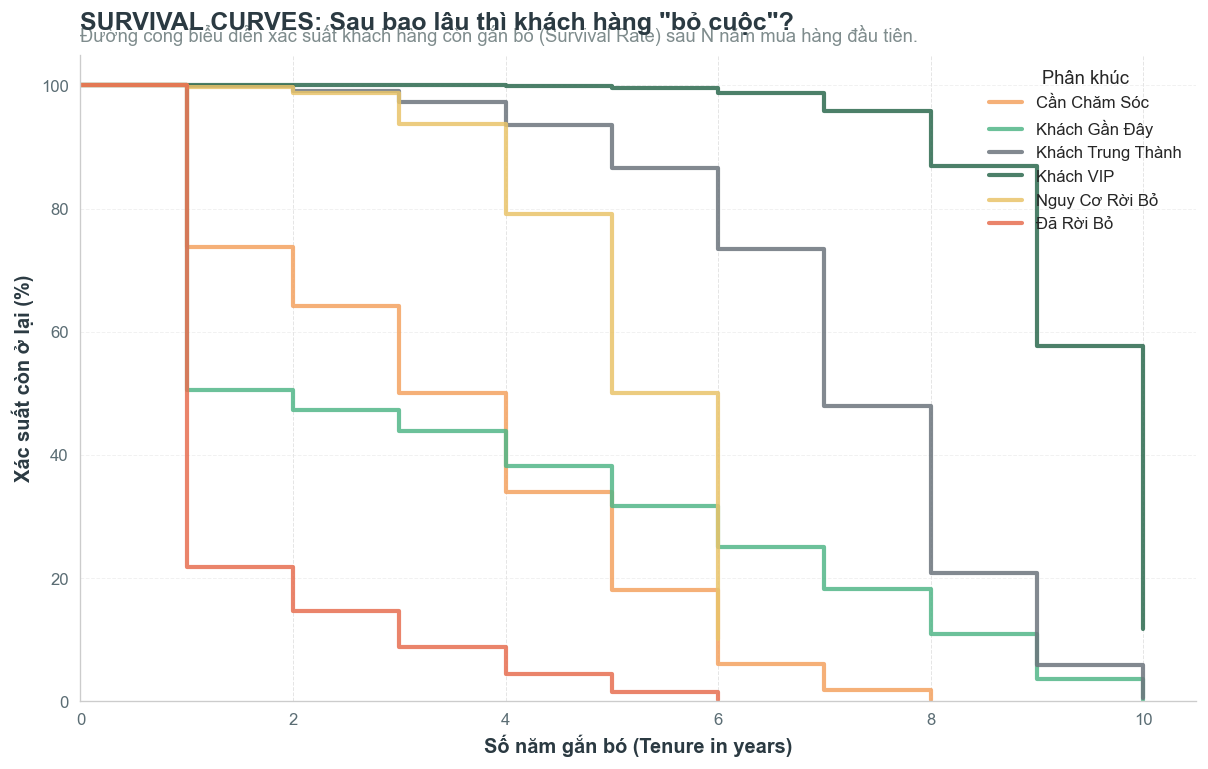

In [22]:
section_header(
    title='Phân tích Dự báo: Mô hình Sinh tồn (Survival Analysis)', 
    subtitle='Dự đoán rủi ro rời bỏ của từng phân khúc khách hàng qua các năm'
)

# Yêu cầu biến customer_rfm đã tồn tại trong môi trường từ bước trước
plot_customer_survival_analysis(
    master_df=master_df, 
    customer_rfm=customer_rfm, 
    save_fig=True
)

**Khách hàng thông thường "chết yểu" trong năm đầu tiên**

Với nhóm Đã Rời Bỏ và Khách Gần Đây, đường cong sinh tồn lao dốc gần như thẳng đứng ngay trong năm đầu. Điều này cho thấy phần lớn khách hàng phổ thông chỉ có "tuổi thọ" dưới 1 năm trên hệ thống. Nếu doanh nghiệp không kích hoạt được họ mua đơn thứ 2 hoặc thứ 3 trong vòng 12 tháng đầu kể từ khi đăng ký, xác suất họ quay lại năm thứ 2 gần như bằng 0.

> **Bài học:** 12 tháng đầu tiên là "cửa sổ vàng" để chuyển đổi khách mới thành khách trung thành. Bỏ lỡ giai đoạn này, coi như mất trắng.

---

**Khách VIP — "Sức sống bền bỉ đáng kinh ngạc"**

Ngược lại hoàn toàn, đường cong của nhóm Khách VIP thể hiện độ "lì" ấn tượng. Sau 6 năm, vẫn còn hơn 10% khách VIP tiếp tục mua hàng đều đặn — một con số mà các nhóm khác không thể chạm tới.

Khoảng cách quá lớn giữa đường cong VIP và phần còn lại chứng minh một điều: **lòng trung thành không tự nhiên mà có**. Những chi phí bỏ ra để làm hài lòng nhóm VIP — qua đặc quyền, dịch vụ cao cấp, ưu đãi riêng — là khoản đầu tư hoàn toàn xứng đáng, bởi vòng đời (Customer Lifetime) của họ kéo dài gấp nhiều lần khách thông thường.

> **Bài học:** Đầu tư vào VIP không phải chi phí — đó là khoản đầu tư sinh lời cao nhất trong dài hạn.

---

**Năm thứ 6 — "Cột mốc sinh tử" với mọi nhóm khách**

Một phát hiện đáng chú ý: ngay cả nhóm Nguy Cơ Rời Bỏ — những khách từng mua rất nhiều — cũng đồng loạt "đứt gãy" và biến mất hoàn toàn sau năm thứ 6. Dường như tồn tại một "bức tường" vô hình ở mốc này mà nếu không vượt qua được, mọi nhóm khách đều rời bỏ.

**Hành động cụ thể:** Doanh nghiệp cần thiết lập một **"Báo động đỏ CRM" vào cuối năm thứ 5** của mỗi khách hàng. Đây là thời điểm ranh giới sinh tử. Cần tung ra các quyền lợi đặc biệt — tặng quà hiện vật, thăng hạng vĩnh viễn, ưu đãi độc quyền — để phá vỡ "lời nguyền năm thứ 6". Những khách hàng vượt qua được cột mốc này có tiềm năng tiến lên thành Khách VIP và gắn bó tới tận 10 năm.

> **Bài học:** Năm thứ 5–6 là thời điểm "được ăn cả, ngã về không". Một chiến dịch giữ chân đúng thời điểm ở mốc này có thể kéo dài vòng đời khách hàng thêm nhiều năm — hoặc mất họ vĩnh viễn.

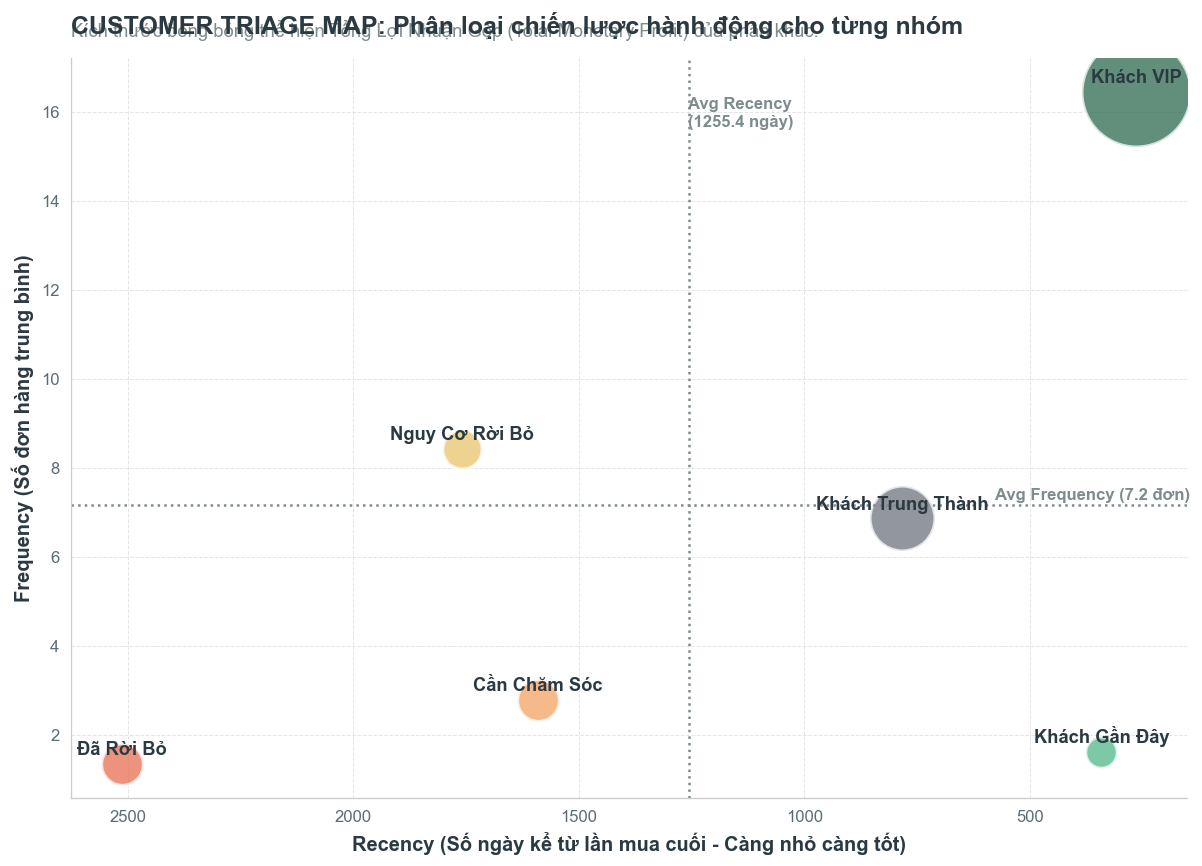

In [23]:
section_header(
    title='Ma trận Ưu tiên Khách hàng (Customer Triage Map)', 
    subtitle='Góc phần tư phía trên bên phải là nhóm Khách hàng lý tưởng. Kích thước bong bóng là Tổng Lợi nhuận.'
)

# Sử dụng dữ liệu customer_rfm đã có
plot_customer_triage_map(
    customer_rfm=customer_rfm, 
    save_fig=True
)

**Nhóm 1 — Khách VIP: Trụ cột lợi nhuận cần được bảo vệ**

Chỉ chiếm **27,9%** tổng số khách hàng nhưng tạo ra tới **64,3%** tổng lợi nhuận gộp, với tần suất mua ấn tượng (16,4 đơn/khách) và thời gian mua gần nhất tương đối ngắn (263 ngày). Thay vì dùng mã giảm giá đại trà, chiến lược đầu tư hiệu quả nhất cho nhóm này là trải nghiệm cao cấp và đặc quyền: dịch vụ CSKH riêng, quyền mua sớm các bộ sưu tập giới hạn, và chính sách miễn phí vận chuyển vô điều kiện.

**Nhóm 2 — Khách Thân Thiết: Động lực tăng trưởng tiềm năng**

Chiếm **20,5%** tệp khách hàng và đóng góp **19,7%** lợi nhuận. Tần suất mua khá tốt (6,8 đơn/khách), nhưng chỉ số Recency ở mức đáng theo dõi (782 ngày — khoảng 2 năm) cho thấy nhóm này đang có dấu hiệu giãn cách thời gian mua. Cần triển khai các chiến dịch win-back nhẹ nhàng và hệ thống gợi ý cá nhân hóa để duy trì sự gắn kết và đẩy họ lên tệp VIP trước khi họ nguội lạnh.

**Nhóm 3 — Khách Gần Đây: Tệp bản lề cần được kích hoạt**

Chiếm **5,4%** tệp khách hàng với Recency tốt (341 ngày) nhưng Frequency rất thấp (1,6 đơn/khách) và lợi nhuận mới đạt khoảng 1%. Nhiệm vụ ưu tiên là phá vỡ "lời nguyền mua 1 lần" bằng các luồng onboarding tự động và ưu đãi mạnh tay cho đơn hàng thứ 2 và thứ 3 — nhằm rèn luyện thói quen mua sắm trước khi cửa sổ 12 tháng vàng khép lại.

**Nhóm 4 — Đã Rời Bỏ & Cần Chăm Sóc: Không nên đốt ngân sách**

Hai nhóm này gộp lại chiếm hơn **42%** tệp khách hàng nhưng chỉ mang lại chưa tới **11%** lợi nhuận. Tần suất mua rất thấp và thời gian vắng mặt trung bình từ 4 đến 7 năm. Với ROI dự kiến rất thấp, không nên đầu tư ngân sách performance marketing (retargeting ads) cho tệp này; chỉ nên tiếp cận qua các kênh chi phí thấp như email xả kho cuối mùa để tối ưu hóa chi tiêu.

## 8. Tổng kết chiến lược

### Kết luận sơ bộ

Qua toàn bộ phân tích, nổi lên **4 vấn đề cốt lõi** đang kìm hãm hiệu suất kinh doanh của doanh nghiệp:

| # | Vấn đề | Mức độ nghiêm trọng | Tác động |
|---|--------|---------------------|----------|
| 1 | **Streetwear sai cơ cấu tồn kho** | Rất nặng | Vừa mất 80,9% doanh thu do thiếu hàng, vừa khóa 76,9% vốn trong hàng dư |
| 2 | **Khuyến mãi hủy hoại lợi nhuận** | Rất nặng | 38,7% đơn hàng đang bán dưới giá vốn; fixed discount lỗ tới -63,3% |
| 3 | **Khủng hoảng kép về khách hàng** | Nặng | Khách mới cạn kiệt + tỷ lệ giữ chân gãy gập từ 2018, chưa từng phục hồi |
| 4 | **Chất lượng sản phẩm & trải nghiệm size** | Trung bình | Wrong_size + defective chiếm 55% lý do trả hàng, làm xói mòn lòng tin |

---

### Ba trụ cột hành động ưu tiên

**Trụ cột 1 — Sửa cơ cấu tồn kho Streetwear (Ưu tiên cao nhất)**

- Không nhập thêm hàng đại trà. Phân loại từng SKU: mã bán chạy/thiếu hàng → bổ sung gấp; mã dư kho/vòng quay thấp → giảm nhập, bundle hoặc markdown.
- Mục tiêu: giảm 20% stockout trong nhóm Streetwear, kỳ vọng thu hồi ~51,5 triệu VNĐ doanh thu và ~10 triệu VNĐ lợi nhuận gộp.

**Trụ cột 2 — Tái cấu trúc chương trình khuyến mãi**

- Audit và tạm dừng toàn bộ mã fixed discount chưa có `min_order_value` bảo vệ điểm hòa vốn.
- Chuyển sang mô hình Tiered Discount + Capped Discount để kiểm soát biên lợi nhuận. Mục tiêu: kéo Gross Margin nhóm có khuyến mãi từ -14,5% về ít nhất mức dương.

**Trụ cột 3 — Cứu "đáy xô" khách hàng trước, thu hút khách mới sau**

- Tạm dừng chi tiêu acquisition cho đến khi tỷ lệ giữ chân phục hồi trên 50%.
- Triển khai khảo sát chuyên sâu nhóm khách rời bỏ sau 2018 để tìm nguyên nhân gốc rễ.
- Thiết lập "Báo động đỏ CRM" vào cuối năm thứ 5 của mỗi khách hàng — thời điểm sinh tử để giữ chân trước "lời nguyền năm thứ 6".
- Tập trung nuôi dưỡng nhóm VIP: 2 nhóm khách cốt lõi đang tạo ra 84% tổng lợi nhuận.

---

**Thông điệp cuối cùng:**

Doanh nghiệp không thiếu khách hàng tiềm năng, không thiếu traffic, không thiếu hàng trong kho. Vấn đề nằm ở **phân bổ sai nguồn lực**: sai cơ cấu tồn kho, sai cấu hình khuyến mãi, và sai thời điểm can thiệp giữ chân khách hàng. Ba trụ cột trên không đòi hỏi ngân sách khổng lồ — chúng đòi hỏi **sự chính xác trong thực thi và kỷ luật trong đo lường**. Đây chính là chìa khóa để phá vỡ vòng luẩn quẩn "thiếu-doanh-thu-nhưng-thừa-hàng-tồn" mà doanh nghiệp đã mắc kẹt suốt nhiều năm.